In [5]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.lib.distances import capped_distance


# ===========================================================================
# INPUT / OUTPUT
# ===========================================================================
TRAJ_ROOT = Path("traj")
FRAGMENT_DIRS = [str(i) for i in range(1, 13)]
OUTPUT_DIR = "./interaction_outputs_by_fragment"

# Read .nc files from:
# traj/1/centerizing/out_remove_center/
# traj/2/centerizing/out_remove_center/
# ...
NC_SUBDIR = Path("centerizing/out_remove_center")
MAX_NC_FILES_PER_FRAGMENT = 64  # set to None to use all .nc files

# Probability normalization
# If False: divide by n_frames * n_target_chains
# If True : divide by n_frames * n_total_chains
NORMALIZE_BY_TOTAL_CHAINS = False

# Cutoffs
PI_PI_MAX_DIST = 7.0
PI_PI_MIN_ANGLE_DEG = 0.0
PI_PI_MAX_ANGLE_DEG = 45.0
CATION_PI_MAX_DIST = 6.0
SALT_BRIDGE_MAX_DIST = 4.0
HYDROPHOBIC_MAX_DIST = 5.0
POLAR_MAX_DIST = 3.5

USE_PBC_IF_AVAILABLE = True


# ===========================================================================
# General atom-name definitions
# ===========================================================================
BACKBONE_NAMES = {"N", "CA", "C", "O"}
POLAR_BACKBONE_ATOMS = ["N", "O"]

AROMATIC_RING_ATOMS = {
    "TYR": ["CG", "CD2", "CE2", "CZ", "CE1", "CD1"],
    "PHE": ["CG", "CD2", "CE2", "CZ", "CE1", "CD1"],
    "TRP": ["CE2", "CD2", "CE3", "CZ3", "CH2", "CZ2"],
}

CATION_PI_GROUP_ATOMS = {
    "ARG": ["CZ"],
    "LYS": ["NZ"],
}

SALT_BRIDGE_CATION_ATOMS = {
    "ARG": ["NH1", "NH2"],
    "LYS": ["NZ"],
    "HIP": ["ND1", "NE2"],
}

ANION_GROUP_ATOMS = {
    "ASP": ["OD1", "OD2"],
    "GLU": ["OE1", "OE2"],
}

HYDROPHOBIC_RESIDUES = {
    "ALA", "CYS", "PHE", "GLY", "ILE",
    "LEU", "MET", "PRO", "VAL", "TRP"
}

POLAR_SIDECHAIN_ATOMS = {
    "SER": ["OG"],
    "THR": ["OG1"],
    "ASN": ["OD1", "ND2"],
    "GLN": ["OE1", "NE2"],
    "TYR": ["OH"],
}


@dataclass
class ResidueFeature:
    resid: int
    resname: str
    ring_atom_indices: np.ndarray | None = None
    cation_pi_atom_indices: np.ndarray | None = None
    salt_bridge_cation_atom_indices: np.ndarray | None = None
    anion_atom_indices: np.ndarray | None = None
    hydrophobic_atom_indices: np.ndarray | None = None
    polar_sidechain_atom_indices: np.ndarray | None = None
    polar_backbone_atom_indices: np.ndarray | None = None


def unit_vector(v: np.ndarray) -> np.ndarray | None:
    n = np.linalg.norm(v)
    if n < 1e-12:
        return None
    return v / n


def plane_normal(points: np.ndarray) -> np.ndarray | None:
    if points.shape[0] < 3:
        return None
    centered = points - points.mean(axis=0)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    return unit_vector(vh[-1])


def acute_angle_deg_between(v1: np.ndarray, v2: np.ndarray) -> float | None:
    u1 = unit_vector(v1)
    u2 = unit_vector(v2)
    if u1 is None or u2 is None:
        return None
    cosang = np.clip(np.abs(np.dot(u1, u2)), 0.0, 1.0)
    return float(np.degrees(np.arccos(cosang)))


def get_box(ts) -> np.ndarray | None:
    if not USE_PBC_IF_AVAILABLE:
        return None
    dims = getattr(ts, "dimensions", None)
    if dims is None or len(dims) < 3:
        return None
    if np.any(np.isnan(dims[:3])) or np.any(dims[:3] <= 0):
        return None
    return dims


def hydrophobic_sidechain_cs_indices(res) -> np.ndarray:
    if res.resname.upper() not in HYDROPHOBIC_RESIDUES:
        return np.asarray([], dtype=int)

    indices = [
        atom.index
        for atom in res.atoms
        if atom.name.upper() not in BACKBONE_NAMES
        and not atom.name.upper().startswith("H")
        and (
            atom.name.upper().startswith("C")
            or atom.name.upper().startswith("S")
        )
    ]
    return np.asarray(indices, dtype=int)


def named_atom_indices(res, atom_names: list[str]) -> np.ndarray:
    wanted = {a.upper() for a in atom_names}
    indices = [
        atom.index
        for atom in res.atoms
        if atom.name.upper() in wanted
    ]
    return np.asarray(indices, dtype=int)


def build_residue_features(u: mda.Universe) -> dict[int, ResidueFeature]:
    feats = {}

    for res in u.residues:
        resid = int(res.resid)
        resname = res.resname.upper()

        hydrophobic_idx = None
        ring_idx = None
        cation_pi_idx = None
        salt_bridge_cation_idx = None
        anion_idx = None
        polar_sidechain_idx = None
        polar_backbone_idx = None

        if resname in HYDROPHOBIC_RESIDUES:
            idx = hydrophobic_sidechain_cs_indices(res)
            if idx.size > 0:
                hydrophobic_idx = idx

        if resname in POLAR_SIDECHAIN_ATOMS:
            idx = named_atom_indices(res, POLAR_SIDECHAIN_ATOMS[resname])
            if idx.size > 0:
                polar_sidechain_idx = idx

        bb_idx = named_atom_indices(res, POLAR_BACKBONE_ATOMS)
        if bb_idx.size > 0:
            polar_backbone_idx = bb_idx

        if resname in AROMATIC_RING_ATOMS:
            idx = named_atom_indices(res, AROMATIC_RING_ATOMS[resname])
            if idx.size >= 3:
                ring_idx = idx

        if resname in CATION_PI_GROUP_ATOMS:
            idx = named_atom_indices(res, CATION_PI_GROUP_ATOMS[resname])
            if idx.size > 0:
                cation_pi_idx = idx

        if resname in SALT_BRIDGE_CATION_ATOMS:
            idx = named_atom_indices(res, SALT_BRIDGE_CATION_ATOMS[resname])
            if idx.size > 0:
                salt_bridge_cation_idx = idx

        if resname in ANION_GROUP_ATOMS:
            idx = named_atom_indices(res, ANION_GROUP_ATOMS[resname])
            if idx.size > 0:
                anion_idx = idx

        feats[resid] = ResidueFeature(
            resid=resid,
            resname=resname,
            ring_atom_indices=ring_idx,
            cation_pi_atom_indices=cation_pi_idx,
            salt_bridge_cation_atom_indices=salt_bridge_cation_idx,
            anion_atom_indices=anion_idx,
            hydrophobic_atom_indices=hydrophobic_idx,
            polar_sidechain_atom_indices=polar_sidechain_idx,
            polar_backbone_atom_indices=polar_backbone_idx,
        )

    return feats


def build_atomgroup_and_resid_map(u, residue_ids, features, attr_name):
    atom_indices = []
    resid_map = []

    for resid in residue_ids:
        feat = features.get(resid)
        if feat is None:
            continue

        idx = getattr(feat, attr_name)
        if idx is None or len(idx) == 0:
            continue

        atom_indices.extend(idx.tolist())
        resid_map.extend([resid] * len(idx))

    if not atom_indices:
        return None, None

    ag = u.atoms[np.asarray(atom_indices, dtype=int)]
    return ag, np.asarray(resid_map, dtype=int)


def increment_unique_residue_pairs_from_atom_contacts(
    interaction_name,
    pairs,
    src_atom_resids,
    tgt_atom_resids,
    pair_frame_counts,
):
    if pairs.size == 0:
        return

    resid_pairs = np.column_stack([
        src_atom_resids[pairs[:, 0]],
        tgt_atom_resids[pairs[:, 1]],
    ])
    resid_pairs = np.unique(resid_pairs, axis=0)

    for src_resid, tgt_resid in resid_pairs:
        pair_frame_counts[(interaction_name, int(src_resid), int(tgt_resid))] += 1


def residue_pairs_from_atom_contacts(
    pairs,
    src_atom_resids,
    tgt_atom_resids,
) -> set[tuple[int, int]]:
    if pairs.size == 0:
        return set()

    resid_pairs = np.column_stack([
        src_atom_resids[pairs[:, 0]],
        tgt_atom_resids[pairs[:, 1]],
    ])
    resid_pairs = np.unique(resid_pairs, axis=0)

    return {(int(src), int(tgt)) for src, tgt in resid_pairs}


def increment_residue_pair_set(interaction_name, resid_pair_set, pair_frame_counts):
    for src_resid, tgt_resid in resid_pair_set:
        pair_frame_counts[(interaction_name, src_resid, tgt_resid)] += 1


def ring_geometry(u, atom_indices):
    pts = u.atoms[atom_indices].positions
    centroid = pts.mean(axis=0)
    normal = plane_normal(pts)
    return centroid, normal


def point_geometry(u, atom_indices):
    pts = u.atoms[atom_indices].positions
    return pts.mean(axis=0)


def detect_pi_pi_for_frame(
    u,
    source_ring_resids,
    target_ring_resids,
    features,
    pair_frame_counts,
):
    target_geom = {}

    for resid in target_ring_resids:
        idx = features[resid].ring_atom_indices
        if idx is None:
            continue

        centroid, normal = ring_geometry(u, idx)
        if normal is not None:
            target_geom[resid] = (centroid, normal)

    for sresid in source_ring_resids:
        sidx = features[sresid].ring_atom_indices
        if sidx is None:
            continue

        scent, snorm = ring_geometry(u, sidx)
        if snorm is None:
            continue

        for tresid, (tcent, tnorm) in target_geom.items():
            d = np.linalg.norm(scent - tcent)
            angle = acute_angle_deg_between(snorm, tnorm)

            if angle is None:
                continue

            if (
                d <= PI_PI_MAX_DIST
                and PI_PI_MIN_ANGLE_DEG <= angle <= PI_PI_MAX_ANGLE_DEG
            ):
                pair_frame_counts[("pi_pi", int(sresid), int(tresid))] += 1


def detect_cation_pi_for_frame(
    u,
    source_cation_pi_resids,
    target_ring_resids,
    source_ring_resids,
    target_cation_pi_resids,
    features,
    pair_frame_counts,
):
    target_ring_centroids = {}

    for resid in target_ring_resids:
        idx = features[resid].ring_atom_indices
        if idx is not None:
            target_ring_centroids[resid] = point_geometry(u, idx)

    target_cat_centers = {}

    for resid in target_cation_pi_resids:
        idx = features[resid].cation_pi_atom_indices
        if idx is not None:
            target_cat_centers[resid] = point_geometry(u, idx)

    for sresid in source_cation_pi_resids:
        sidx = features[sresid].cation_pi_atom_indices
        if sidx is None:
            continue

        scat = point_geometry(u, sidx)

        for tresid, tcent in target_ring_centroids.items():
            d = np.linalg.norm(scat - tcent)
            if d <= CATION_PI_MAX_DIST:
                pair_frame_counts[("cation_pi", int(sresid), int(tresid))] += 1

    for sresid in source_ring_resids:
        sidx = features[sresid].ring_atom_indices
        if sidx is None:
            continue

        scent = point_geometry(u, sidx)

        for tresid, tcat in target_cat_centers.items():
            d = np.linalg.norm(tcat - scent)
            if d <= CATION_PI_MAX_DIST:
                pair_frame_counts[("cation_pi", int(sresid), int(tresid))] += 1


# ===========================================================================
# File discovery
# ===========================================================================
def find_single_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No file matching '{pattern}' found in {directory}")

    if len(files) > 1:
        print(
            f"WARNING: multiple files matching '{pattern}' in {directory}; "
            f"using {files[0].name}",
            flush=True,
        )

    return files[0]


def find_nc_files(directory: Path) -> list[Path]:
    nc_files = sorted(directory.glob("*.nc"))

    if not nc_files:
        raise FileNotFoundError(f"No .nc files found in {directory}")

    if MAX_NC_FILES_PER_FRAGMENT is not None:
        nc_files = nc_files[:MAX_NC_FILES_PER_FRAGMENT]

    return nc_files


def get_fragment_jobs(traj_root: Path, fragment_dirs: list[str]) -> list[tuple[str, Path, Path]]:
    jobs = []

    for frag in fragment_dirs:
        frag_dir = traj_root / frag
        nc_dir = frag_dir / NC_SUBDIR

        if not frag_dir.exists():
            print(f"WARNING: fragment directory not found: {frag_dir}", flush=True)
            continue

        if not frag_dir.is_dir():
            print(f"WARNING: not a directory: {frag_dir}", flush=True)
            continue

        if not nc_dir.exists():
            print(f"WARNING: .nc directory not found: {nc_dir}", flush=True)
            continue

        parm7_file = find_single_file(frag_dir, "*.parm7")
        nc_files = find_nc_files(nc_dir)

        print(
            f"Fragment {frag}: using {len(nc_files)} .nc files from {nc_dir}",
            flush=True,
        )

        for nc_file in nc_files:
            jobs.append((frag, parm7_file, nc_file))

    return jobs


# ===========================================================================
# Chain detection
# ===========================================================================
def get_chain_sequences_and_real_resids(u: mda.Universe) -> list[list[tuple[int, str]]]:
    """
    Split topology into peptide copies using ACE ... NME blocks.
    Each returned chain is a list of real residues only: [(resid, resname), ...].
    """
    chains = []
    current = []
    inside_chain = False

    for res in u.residues:
        resname = str(res.resname).upper()
        resid = int(res.resid)

        if resname == "ACE":
            if inside_chain and current:
                chains.append(current)
            current = []
            inside_chain = True
            continue

        if not inside_chain:
            continue

        if resname == "NME":
            chains.append(current)
            current = []
            inside_chain = False
            continue

        current.append((resid, resname))

    if inside_chain and current:
        chains.append(current)

    return chains


def get_source_and_target_resids(u: mda.Universe):
    chains = get_chain_sequences_and_real_resids(u)

    if not chains:
        raise ValueError("Could not detect any ACE ... NME peptide chains in topology")

    source_chain = chains[0]
    source_resids = [resid for resid, _ in source_chain]
    source_resname_order = [resname for _, resname in source_chain]

    target_resids = []
    for chain in chains[1:]:
        target_resids.extend([resid for resid, _ in chain])

    n_total_chains = len(chains)
    n_target_chains = max(n_total_chains - 1, 0)

    return (
        source_resids,
        source_resname_order,
        target_resids,
        n_total_chains,
        n_target_chains,
    )


# ===========================================================================
# Main
# ===========================================================================
def main():
    outdir = Path(OUTPUT_DIR)
    outdir.mkdir(parents=True, exist_ok=True)

    jobs = get_fragment_jobs(TRAJ_ROOT, FRAGMENT_DIRS)

    if not jobs:
        print("ERROR: no fragment jobs found", file=sys.stderr)
        sys.exit(1)

    per_traj_rows = []
    mean_prob_accumulator = defaultdict(float)
    jobs_per_fragment = defaultdict(int)
    source_order_rows = []

    for fragment, parm7_path, traj_path in jobs:
        fragment_int = int(fragment)

        print(
            f"\nProcessing fragment {fragment}: {traj_path} with {parm7_path} ...",
            flush=True,
        )

        u = mda.Universe(str(parm7_path), str(traj_path))

        feats = build_residue_features(u)
        resid_to_resname = {rid: feat.resname for rid, feat in feats.items()}

        (
            source_resids_this,
            source_resname_order,
            target_resids_this,
            n_total_chains,
            n_target_chains,
        ) = get_source_and_target_resids(u)

        if len(source_resids_this) == 0:
            print(f"WARNING: no source residues found for fragment {fragment}; skipping", flush=True)
            continue

        if len(target_resids_this) == 0:
            print(f"WARNING: no target residues found for fragment {fragment}; skipping", flush=True)
            continue

        normalization_chain_count = (
            n_total_chains if NORMALIZE_BY_TOTAL_CHAINS else n_target_chains
        )

        if normalization_chain_count <= 0:
            print(
                f"WARNING: invalid normalization chain count for fragment {fragment}; skipping",
                flush=True,
            )
            continue

        if jobs_per_fragment[fragment_int] == 0:
            for seq_pos, (src_resid, src_resname) in enumerate(
                zip(source_resids_this, source_resname_order),
                start=1,
            ):
                source_order_rows.append({
                    "fragment": fragment_int,
                    "sequence_position": seq_pos,
                    "src_resid": src_resid,
                    "src_resname": src_resname,
                })

        source_ring_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].ring_atom_indices is not None
        ]
        target_ring_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].ring_atom_indices is not None
        ]

        source_cation_pi_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].cation_pi_atom_indices is not None
        ]
        target_cation_pi_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].cation_pi_atom_indices is not None
        ]

        source_salt_cation_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].salt_bridge_cation_atom_indices is not None
        ]
        target_salt_cation_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].salt_bridge_cation_atom_indices is not None
        ]

        source_anion_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].anion_atom_indices is not None
        ]
        target_anion_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].anion_atom_indices is not None
        ]

        source_hydrophobic_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].hydrophobic_atom_indices is not None
        ]
        target_hydrophobic_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].hydrophobic_atom_indices is not None
        ]

        source_polar_sc_resids = [
            r for r in source_resids_this
            if r in feats and feats[r].polar_sidechain_atom_indices is not None
        ]
        target_polar_sc_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].polar_sidechain_atom_indices is not None
        ]
        target_polar_bb_resids = [
            r for r in target_resids_this
            if r in feats and feats[r].polar_backbone_atom_indices is not None
        ]

        src_hydrophobic_ag, src_hydrophobic_atom_resids = build_atomgroup_and_resid_map(
            u, source_hydrophobic_resids, feats, "hydrophobic_atom_indices"
        )
        tgt_hydrophobic_ag, tgt_hydrophobic_atom_resids = build_atomgroup_and_resid_map(
            u, target_hydrophobic_resids, feats, "hydrophobic_atom_indices"
        )

        src_polar_sc_ag, src_polar_sc_atom_resids = build_atomgroup_and_resid_map(
            u, source_polar_sc_resids, feats, "polar_sidechain_atom_indices"
        )
        tgt_polar_sc_ag, tgt_polar_sc_atom_resids = build_atomgroup_and_resid_map(
            u, target_polar_sc_resids, feats, "polar_sidechain_atom_indices"
        )
        tgt_polar_bb_ag, tgt_polar_bb_atom_resids = build_atomgroup_and_resid_map(
            u, target_polar_bb_resids, feats, "polar_backbone_atom_indices"
        )

        src_salt_cation_ag, src_salt_cation_atom_resids = build_atomgroup_and_resid_map(
            u, source_salt_cation_resids, feats, "salt_bridge_cation_atom_indices"
        )
        tgt_salt_cation_ag, tgt_salt_cation_atom_resids = build_atomgroup_and_resid_map(
            u, target_salt_cation_resids, feats, "salt_bridge_cation_atom_indices"
        )

        src_anion_ag, src_anion_atom_resids = build_atomgroup_and_resid_map(
            u, source_anion_resids, feats, "anion_atom_indices"
        )
        tgt_anion_ag, tgt_anion_atom_resids = build_atomgroup_and_resid_map(
            u, target_anion_resids, feats, "anion_atom_indices"
        )

        pair_frame_counts = defaultdict(int)
        n_frames = 0

        print(
            f"  source_chain_len={len(source_resids_this)} "
            f"total_chains={n_total_chains} "
            f"target_chains={n_target_chains} "
            f"norm_chain_count={normalization_chain_count}",
            flush=True,
        )
        print(f"  source_resids={source_resids_this}", flush=True)
        print(f"  source_sequence_3letter={''.join(source_resname_order)}", flush=True)

        for ts in u.trajectory:
            n_frames += 1
            box = get_box(ts)

            # Hydrophobic
            if src_hydrophobic_ag is not None and tgt_hydrophobic_ag is not None:
                pairs = capped_distance(
                    src_hydrophobic_ag.positions,
                    tgt_hydrophobic_ag.positions,
                    HYDROPHOBIC_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                increment_unique_residue_pairs_from_atom_contacts(
                    "hydrophobic",
                    pairs,
                    src_hydrophobic_atom_resids,
                    tgt_hydrophobic_atom_resids,
                    pair_frame_counts,
                )

            # Polar
            polar_resid_pairs = set()

            if src_polar_sc_ag is not None and tgt_polar_sc_ag is not None:
                pairs = capped_distance(
                    src_polar_sc_ag.positions,
                    tgt_polar_sc_ag.positions,
                    POLAR_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                polar_resid_pairs |= residue_pairs_from_atom_contacts(
                    pairs,
                    src_polar_sc_atom_resids,
                    tgt_polar_sc_atom_resids,
                )

            if src_polar_sc_ag is not None and tgt_polar_bb_ag is not None:
                pairs = capped_distance(
                    src_polar_sc_ag.positions,
                    tgt_polar_bb_ag.positions,
                    POLAR_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                polar_resid_pairs |= residue_pairs_from_atom_contacts(
                    pairs,
                    src_polar_sc_atom_resids,
                    tgt_polar_bb_atom_resids,
                )

            increment_residue_pair_set(
                "polar",
                polar_resid_pairs,
                pair_frame_counts,
            )

            # Salt bridge: source cation to target anion
            if src_salt_cation_ag is not None and tgt_anion_ag is not None:
                pairs = capped_distance(
                    src_salt_cation_ag.positions,
                    tgt_anion_ag.positions,
                    SALT_BRIDGE_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                increment_unique_residue_pairs_from_atom_contacts(
                    "salt_bridge",
                    pairs,
                    src_salt_cation_atom_resids,
                    tgt_anion_atom_resids,
                    pair_frame_counts,
                )

            # Salt bridge: source anion to target cation
            if src_anion_ag is not None and tgt_salt_cation_ag is not None:
                pairs = capped_distance(
                    src_anion_ag.positions,
                    tgt_salt_cation_ag.positions,
                    SALT_BRIDGE_MAX_DIST,
                    box=box,
                    return_distances=False,
                )
                increment_unique_residue_pairs_from_atom_contacts(
                    "salt_bridge",
                    pairs,
                    src_anion_atom_resids,
                    tgt_salt_cation_atom_resids,
                    pair_frame_counts,
                )

            # Pi-pi
            if source_ring_resids and target_ring_resids:
                detect_pi_pi_for_frame(
                    u,
                    source_ring_resids,
                    target_ring_resids,
                    feats,
                    pair_frame_counts,
                )

            # Cation-pi
            if source_cation_pi_resids or target_cation_pi_resids:
                detect_cation_pi_for_frame(
                    u,
                    source_cation_pi_resids,
                    target_ring_resids,
                    source_ring_resids,
                    target_cation_pi_resids,
                    feats,
                    pair_frame_counts,
                )

        if n_frames == 0:
            print(f"WARNING: trajectory has 0 frames: {traj_path}; skipping", flush=True)
            continue

        for (interaction, src_resid, tgt_resid), count in sorted(pair_frame_counts.items()):
            prob = count / (n_frames * normalization_chain_count)

            per_traj_rows.append({
                "fragment": fragment_int,
                "traj_file": traj_path.name,
                "traj_path": str(traj_path),
                "parm7_file": parm7_path.name,
                "interaction": interaction,
                "src_resid": src_resid,
                "src_resname": resid_to_resname.get(src_resid, "UNK"),
                "tgt_resid": tgt_resid,
                "tgt_resname": resid_to_resname.get(tgt_resid, "UNK"),
                "frames_with_interaction": count,
                "n_frames": n_frames,
                "n_total_chains": n_total_chains,
                "n_target_chains": n_target_chains,
                "normalization_chain_count": normalization_chain_count,
                "probability": prob,
            })

            mean_prob_accumulator[
                (fragment_int, interaction, src_resid, tgt_resid)
            ] += prob

        jobs_per_fragment[fragment_int] += 1

        print(
            f"  done: fragment={fragment} traj={traj_path.name} "
            f"frames={n_frames} unique_pairs={len(pair_frame_counts)}",
            flush=True,
        )

    # ===========================================================================
    # Save per-trajectory results
    # ===========================================================================
    per_traj_df = pd.DataFrame(per_traj_rows)

    if not per_traj_df.empty:
        per_traj_df = per_traj_df.sort_values(
            ["fragment", "interaction", "traj_file", "src_resid", "tgt_resid"]
        ).reset_index(drop=True)

    per_traj_df.to_csv(
        outdir / "interaction_pair_probabilities_per_traj.csv",
        index=False,
    )

    # ===========================================================================
    # Save source residue order
    # ===========================================================================
    source_order_df = pd.DataFrame(source_order_rows)

    if not source_order_df.empty:
        source_order_df = (
            source_order_df
            .drop_duplicates(
                subset=["fragment", "sequence_position", "src_resid", "src_resname"]
            )
            .sort_values(["fragment", "sequence_position"])
            .reset_index(drop=True)
        )

    source_order_df.to_csv(
        outdir / "fragment_source_residue_order.csv",
        index=False,
    )

    # ===========================================================================
    # Average probability over trajectories inside each fragment
    # ===========================================================================
    mean_rows = []

    for (
        fragment,
        interaction,
        src_resid,
        tgt_resid,
    ), prob_sum in sorted(mean_prob_accumulator.items()):

        rows_match = per_traj_df[
            (per_traj_df["fragment"] == fragment)
            & (per_traj_df["interaction"] == interaction)
            & (per_traj_df["src_resid"] == src_resid)
            & (per_traj_df["tgt_resid"] == tgt_resid)
        ]

        mean_rows.append({
            "fragment": fragment,
            "interaction": interaction,
            "src_resid": src_resid,
            "src_resname": rows_match["src_resname"].iloc[0],
            "tgt_resid": tgt_resid,
            "tgt_resname": rows_match["tgt_resname"].iloc[0],
            "mean_probability_over_trajs": prob_sum / jobs_per_fragment[fragment],
            "n_trajs": jobs_per_fragment[fragment],
        })

    mean_df = pd.DataFrame(mean_rows)

    if not mean_df.empty:
        mean_df = mean_df.sort_values(
            ["fragment", "interaction", "src_resid", "tgt_resid"]
        ).reset_index(drop=True)

    mean_df.to_csv(
        outdir / "interaction_pair_probabilities_mean_over_trajs.csv",
        index=False,
    )

    # ===========================================================================
    # Source-residue totals after averaging over trajectories
    # ===========================================================================
    if not mean_df.empty:
        source_totals_df = (
            mean_df
            .groupby(
                ["fragment", "interaction", "src_resid", "src_resname"],
                as_index=False,
            )
            .agg(
                total_mean_probability=("mean_probability_over_trajs", "sum")
            )
            .sort_values(["fragment", "interaction", "src_resid"])
            .reset_index(drop=True)
        )
    else:
        source_totals_df = pd.DataFrame(
            columns=[
                "fragment",
                "interaction",
                "src_resid",
                "src_resname",
                "total_mean_probability",
            ]
        )

    source_totals_df.to_csv(
        outdir / "interaction_source_residue_totals_mean_over_trajs.csv",
        index=False,
    )

    # ===========================================================================
    # Fragment-level totals
    # ===========================================================================
    if not mean_df.empty:
        fragment_totals_df = (
            mean_df
            .groupby(["fragment", "interaction"], as_index=False)
            .agg(
                total_mean_probability=("mean_probability_over_trajs", "sum"),
                n_pairs=("mean_probability_over_trajs", "size"),
            )
            .sort_values(["fragment", "interaction"])
            .reset_index(drop=True)
        )
    else:
        fragment_totals_df = pd.DataFrame(
            columns=[
                "fragment",
                "interaction",
                "total_mean_probability",
                "n_pairs",
            ]
        )

    fragment_totals_df.to_csv(
        outdir / "interaction_fragment_totals_mean_over_trajs.csv",
        index=False,
    )

    print("\nFinished.")
    print(f"Saved in: {outdir.resolve()}")
    print(f"Per-trajectory results:")
    print(f"  {outdir / 'interaction_pair_probabilities_per_traj.csv'}")
    print(f"Mean-over-trajectories results:")
    print(f"  {outdir / 'interaction_pair_probabilities_mean_over_trajs.csv'}")
    print(f"Source residue totals:")
    print(f"  {outdir / 'interaction_source_residue_totals_mean_over_trajs.csv'}")
    print(f"Fragment totals:")
    print(f"  {outdir / 'interaction_fragment_totals_mean_over_trajs.csv'}")
    print(f"Source residue order:")
    print(f"  {outdir / 'fragment_source_residue_order.csv'}")


if __name__ == "__main__":
    main()

Fragment 1: using 64 .nc files from traj/1/centerizing/out_remove_center
Fragment 2: using 64 .nc files from traj/2/centerizing/out_remove_center
Fragment 3: using 64 .nc files from traj/3/centerizing/out_remove_center
Fragment 4: using 64 .nc files from traj/4/centerizing/out_remove_center
Fragment 5: using 64 .nc files from traj/5/centerizing/out_remove_center
Fragment 6: using 64 .nc files from traj/6/centerizing/out_remove_center
Fragment 7: using 64 .nc files from traj/7/centerizing/out_remove_center
Fragment 8: using 64 .nc files from traj/8/centerizing/out_remove_center
Fragment 9: using 64 .nc files from traj/9/centerizing/out_remove_center
Fragment 10: using 64 .nc files from traj/10/centerizing/out_remove_center
Fragment 11: using 64 .nc files from traj/11/centerizing/out_remove_center
Fragment 12: using 64 .nc files from traj/12/centerizing/out_remove_center

Processing fragment 1: traj/1/centerizing/out_remove_center/ct.ch1.nc with traj/1/prmtop.0.3.2.no.water.caprin.parm7 

In [6]:
# ===========================================================================
# BUILD PER-FRAGMENT 16x16 INTERACTION MATRICES
# rows = source residue positions, cols = target residue positions
# value = probability summed over all 5 interaction types and folded over
#         target-chain copies (source position i  vs  target position j)
# Append after main(), or run standalone using the produced mean CSV.
# ===========================================================================

# "sum"  -> add all 5 interaction types (can exceed 1.0)
# "clip" -> add all 5 then clip each cell to [0, 1]
COMBINE_MODE = "sum"

MAKE_HEATMAPS = True  # set False to skip PNG heatmaps


def build_resid_to_position_maps(u: mda.Universe):
    """
    resid -> sequence position (1-based) within its own chain.
    source_map covers chain[0]; target_map pools chains[1:].
    Also returns position -> resname (from the source chain) for labels.
    """
    chains = get_chain_sequences_and_real_resids(u)
    source_map, target_map, pos_resname = {}, {}, {}

    if not chains:
        return source_map, target_map, pos_resname

    for pos, (resid, resname) in enumerate(chains[0], start=1):
        source_map[resid] = pos
        pos_resname[pos] = resname

    for chain in chains[1:]:
        for pos, (resid, _resname) in enumerate(chain, start=1):
            target_map[resid] = pos

    return source_map, target_map, pos_resname


def build_fragment_interaction_matrices(outdir: Path,
                                        traj_root: Path,
                                        fragment_dirs: list[str]) -> None:
    mean_csv = outdir / "interaction_pair_probabilities_mean_over_trajs.csv"
    if not mean_csv.exists():
        print(f"ERROR: {mean_csv} not found; run the main analysis first.",
              file=sys.stderr)
        return

    mean_df = pd.read_csv(mean_csv)
    if mean_df.empty:
        print("WARNING: mean CSV is empty; no matrices to build.", flush=True)
        return

    matrix_dir = outdir / "fragment_matrices-include-5-type-interactions"
    matrix_dir.mkdir(parents=True, exist_ok=True)

    for frag in fragment_dirs:
        frag_int = int(frag)
        sub = mean_df[mean_df["fragment"] == frag_int]
        if sub.empty:
            continue

        frag_dir = traj_root / frag
        if not frag_dir.is_dir():
            print(f"WARNING: fragment dir missing for matrix: {frag_dir}", flush=True)
            continue

        # topology-only load (fast) just to recover chain structure
        parm7 = find_single_file(frag_dir, "*.parm7")
        u = mda.Universe(str(parm7))

        source_map, target_map, pos_resname = build_resid_to_position_maps(u)
        if not source_map or not target_map:
            print(f"WARNING: could not map residues for fragment {frag}", flush=True)
            continue

        n_src = max(source_map.values())
        n_tgt = max(target_map.values())

        row_labels = [f"{pos_resname.get(p, 'UNK')}{p}" for p in range(1, n_src + 1)]
        col_labels = [f"{pos_resname.get(p, 'UNK')}{p}" for p in range(1, n_tgt + 1)]

        M = np.zeros((n_src, n_tgt), dtype=float)

        for _, row in sub.iterrows():
            i = source_map.get(int(row["src_resid"]))
            j = target_map.get(int(row["tgt_resid"]))
            if i is None or j is None:
                continue
            M[i - 1, j - 1] += float(row["mean_probability_over_trajs"])

        if COMBINE_MODE == "clip":
            M = np.clip(M, 0.0, 1.0)

        mat_df = pd.DataFrame(M, index=row_labels, columns=col_labels)
        mat_df.index.name = "source_residue"
        mat_df.columns.name = "target_residue"

        out_csv = matrix_dir / f"fragment_{frag_int}_interaction_matrix.csv"
        mat_df.to_csv(out_csv)
        print(f"Fragment {frag_int}: saved {n_src}x{n_tgt} matrix -> {out_csv}",
              flush=True)

        if MAKE_HEATMAPS:
            _save_heatmap(M, row_labels, col_labels, frag_int, matrix_dir)


def _save_heatmap(M, row_labels, col_labels, frag_int, matrix_dir):
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("  (matplotlib not available; skipping heatmap)", flush=True)
        return

    fig, ax = plt.subplots(
        figsize=(max(6, 0.5 * len(col_labels)),
                 max(5, 0.5 * len(row_labels)))
    )
    im = ax.imshow(M, aspect="auto", cmap="viridis", vmin=0.0)

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=7)
    ax.set_xlabel("target residue")
    ax.set_ylabel("source residue")
    ax.set_title(f"Fragment {frag_int}: total interaction probability")

    fig.colorbar(im, ax=ax, label="summed probability")
    fig.tight_layout()

    out_png = matrix_dir / f"fragment_{frag_int}_interaction_matrix.png"
    fig.savefig(out_png, dpi=200)
    plt.close(fig)
    print(f"  heatmap -> {out_png}", flush=True)


if __name__ == "__main__":
    build_fragment_interaction_matrices(Path(OUTPUT_DIR), TRAJ_ROOT, FRAGMENT_DIRS)

Fragment 1: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_1_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/1/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_1_interaction_matrix.png
Fragment 2: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_2_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/2/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_2_interaction_matrix.png
Fragment 3: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_3_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/3/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_3_interaction_matrix.png
Fragment 4: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_4_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/4/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_4_interaction_matrix.png
Fragment 5: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_5_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/5/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_5_interaction_matrix.png
Fragment 6: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_6_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/6/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_6_interaction_matrix.png
Fragment 7: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_7_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/7/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_7_interaction_matrix.png
Fragment 8: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_8_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/8/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_8_interaction_matrix.png
Fragment 9: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_9_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/9/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_9_interaction_matrix.png
Fragment 10: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_10_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/10/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_10_interaction_matrix.png
Fragment 11: saved 16x16 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_11_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/11/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_11_interaction_matrix.png
Fragment 12: saved 15x15 matrix -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_12_interaction_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/12/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-5-type-interactions/fragment_12_interaction_matrix.png


In [7]:
# ===========================================================================
# BUILD PER-FRAGMENT INTERACTION MATRICES
#
# rows = source residue positions
# cols = target residue positions
#
# value = probability summed over only these 3 interaction types:
#         1. salt_bridge
#         2. pi_pi
#         3. cation_pi
#
# Target-chain copies are folded onto the corresponding sequence positions.
#
# Append after main(), or run standalone using the produced mean CSV.
# ===========================================================================


# Interaction types included in the combined matrix
INTERACTIONS_TO_INCLUDE = {
    "salt_bridge",
    "pi_pi",
    "cation_pi",
}


# "sum"  -> add the selected interaction probabilities; values may exceed 1.0
# "clip" -> add the selected interaction probabilities and clip cells to [0, 1]
COMBINE_MODE = "sum"


MAKE_HEATMAPS = True  # Set to False to skip PNG heatmaps


def build_resid_to_position_maps(
    u: mda.Universe,
) -> tuple[dict[int, int], dict[int, int], dict[int, str]]:
    """
    Create mappings from topology residue IDs to sequence positions.

    Returns
    -------
    source_map
        Maps residue IDs in the first peptide chain to 1-based sequence
        positions.

    target_map
        Maps residue IDs in all remaining peptide chains to their corresponding
        1-based sequence positions. Therefore, equivalent positions from
        different target-chain copies are folded onto the same matrix column.

    pos_resname
        Maps source-chain sequence positions to residue names for matrix labels.
    """
    chains = get_chain_sequences_and_real_resids(u)

    source_map: dict[int, int] = {}
    target_map: dict[int, int] = {}
    pos_resname: dict[int, str] = {}

    if not chains:
        return source_map, target_map, pos_resname

    # First peptide copy is the source chain
    for pos, (resid, resname) in enumerate(chains[0], start=1):
        source_map[int(resid)] = pos
        pos_resname[pos] = str(resname).upper()

    # Remaining peptide copies are target chains
    for chain in chains[1:]:
        for pos, (resid, _resname) in enumerate(chain, start=1):
            target_map[int(resid)] = pos

    return source_map, target_map, pos_resname


def build_fragment_interaction_matrices(
    outdir: Path,
    traj_root: Path,
    fragment_dirs: list[str],
) -> None:
    """
    Build one combined source-position x target-position interaction matrix
    per fragment using only salt-bridge, pi-pi, and cation-pi interactions.
    """
    mean_csv = outdir / "interaction_pair_probabilities_mean_over_trajs.csv"

    if not mean_csv.exists():
        print(
            f"ERROR: {mean_csv} not found; run the main analysis first.",
            file=sys.stderr,
        )
        return

    mean_df = pd.read_csv(mean_csv)

    if mean_df.empty:
        print(
            "WARNING: mean CSV is empty; no matrices to build.",
            flush=True,
        )
        return

    required_columns = {
        "fragment",
        "interaction",
        "src_resid",
        "tgt_resid",
        "mean_probability_over_trajs",
    }

    missing_columns = required_columns.difference(mean_df.columns)

    if missing_columns:
        print(
            "ERROR: mean CSV is missing required columns: "
            + ", ".join(sorted(missing_columns)),
            file=sys.stderr,
        )
        return

    # Keep only salt bridge, pi-pi, and cation-pi interactions
    selected_df = mean_df[
        mean_df["interaction"].isin(INTERACTIONS_TO_INCLUDE)
    ].copy()

    if selected_df.empty:
        print(
            "WARNING: no salt_bridge, pi_pi, or cation_pi interactions "
            "were found in the mean CSV.",
            flush=True,
        )
        return

    matrix_dir = outdir / "fragment_matrices-include-3-type-interactions"
    matrix_dir.mkdir(parents=True, exist_ok=True)

    print(
        "Building matrices using interactions: "
        + ", ".join(sorted(INTERACTIONS_TO_INCLUDE)),
        flush=True,
    )

    for frag in fragment_dirs:
        frag_int = int(frag)

        sub = selected_df[
            selected_df["fragment"] == frag_int
        ].copy()

        if sub.empty:
            print(
                f"Fragment {frag_int}: no selected interactions found; skipping.",
                flush=True,
            )
            continue

        frag_dir = traj_root / frag

        if not frag_dir.is_dir():
            print(
                f"WARNING: fragment directory missing for matrix: {frag_dir}",
                flush=True,
            )
            continue

        # Load topology only to recover peptide-chain structure
        parm7 = find_single_file(frag_dir, "*.parm7")
        u = mda.Universe(str(parm7))

        source_map, target_map, pos_resname = (
            build_resid_to_position_maps(u)
        )

        if not source_map or not target_map:
            print(
                f"WARNING: could not map source or target residues "
                f"for fragment {frag_int}",
                flush=True,
            )
            continue

        n_src = max(source_map.values())
        n_tgt = max(target_map.values())

        row_labels = [
            f"{pos_resname.get(pos, 'UNK')}{pos}"
            for pos in range(1, n_src + 1)
        ]

        col_labels = [
            f"{pos_resname.get(pos, 'UNK')}{pos}"
            for pos in range(1, n_tgt + 1)
        ]

        matrix = np.zeros((n_src, n_tgt), dtype=float)

        for row in sub.itertuples(index=False):
            src_resid = int(row.src_resid)
            tgt_resid = int(row.tgt_resid)

            source_position = source_map.get(src_resid)
            target_position = target_map.get(tgt_resid)

            if source_position is None or target_position is None:
                continue

            probability = float(row.mean_probability_over_trajs)

            matrix[
                source_position - 1,
                target_position - 1,
            ] += probability

        if COMBINE_MODE == "clip":
            matrix = np.clip(matrix, 0.0, 1.0)

        elif COMBINE_MODE != "sum":
            raise ValueError(
                f"Invalid COMBINE_MODE={COMBINE_MODE!r}. "
                "Use 'sum' or 'clip'."
            )

        matrix_df = pd.DataFrame(
            matrix,
            index=row_labels,
            columns=col_labels,
        )

        matrix_df.index.name = "source_residue"
        matrix_df.columns.name = "target_residue"

        output_csv = (
            matrix_dir
            / f"fragment_{frag_int}_saltbridge_pipi_cationpi_matrix.csv"
        )

        matrix_df.to_csv(output_csv)

        print(
            f"Fragment {frag_int}: saved {n_src}x{n_tgt} matrix "
            f"using {len(sub)} selected residue-pair records -> {output_csv}",
            flush=True,
        )

        if MAKE_HEATMAPS:
            _save_three_interaction_heatmap(
                matrix=matrix,
                row_labels=row_labels,
                col_labels=col_labels,
                frag_int=frag_int,
                matrix_dir=matrix_dir,
            )


def _save_three_interaction_heatmap(
    matrix: np.ndarray,
    row_labels: list[str],
    col_labels: list[str],
    frag_int: int,
    matrix_dir: Path,
) -> None:
    """
    Save a heatmap of the combined salt-bridge, pi-pi, and cation-pi matrix.
    """
    try:
        import matplotlib

        matplotlib.use("Agg")

        import matplotlib.pyplot as plt

    except ImportError:
        print(
            "  matplotlib is not available; skipping heatmap.",
            flush=True,
        )
        return

    fig, ax = plt.subplots(
        figsize=(
            max(6, 0.5 * len(col_labels)),
            max(5, 0.5 * len(row_labels)),
        )
    )

    image = ax.imshow(
        matrix,
        aspect="auto",
        cmap="viridis",
        vmin=0.0,
    )

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(
        col_labels,
        rotation=90,
        fontsize=7,
    )

    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(
        row_labels,
        fontsize=7,
    )

    ax.set_xlabel("Target residue")
    ax.set_ylabel("Source residue")

    ax.set_title(
        f"Fragment {frag_int}: salt bridge + π–π + cation–π"
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
    )
    colorbar.set_label("Summed mean probability")

    fig.tight_layout()

    output_png = (
        matrix_dir
        / f"fragment_{frag_int}_saltbridge_pipi_cationpi_matrix.png"
    )

    fig.savefig(
        output_png,
        dpi=200,
        bbox_inches="tight",
    )

    plt.close(fig)

    print(
        f"  heatmap -> {output_png}",
        flush=True,
    )


if __name__ == "__main__":
    build_fragment_interaction_matrices(
        Path(OUTPUT_DIR),
        TRAJ_ROOT,
        FRAGMENT_DIRS,
    )

Building matrices using interactions: cation_pi, pi_pi, salt_bridge
Fragment 1: no selected interactions found; skipping.
Fragment 2: saved 16x16 matrix using 82 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_2_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/2/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_2_saltbridge_pipi_cationpi_matrix.png
Fragment 3: saved 16x16 matrix using 314 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_3_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/3/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_3_saltbridge_pipi_cationpi_matrix.png
Fragment 4: saved 16x16 matrix using 222 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_4_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/4/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_4_saltbridge_pipi_cationpi_matrix.png
Fragment 5: saved 16x16 matrix using 128 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_5_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/5/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_5_saltbridge_pipi_cationpi_matrix.png
Fragment 6: saved 16x16 matrix using 46 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_6_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/6/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_6_saltbridge_pipi_cationpi_matrix.png
Fragment 7: saved 16x16 matrix using 101 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_7_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/7/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_7_saltbridge_pipi_cationpi_matrix.png
Fragment 8: saved 16x16 matrix using 399 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_8_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/8/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_8_saltbridge_pipi_cationpi_matrix.png
Fragment 9: saved 16x16 matrix using 92 selected residue-pair records -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_9_saltbridge_pipi_cationpi_matrix.csv


/home/fhatami/.local/lib/python3.11/site-packages/MDAnalysis/core/universe.py:272: UserWarning: No coordinate reader found for traj/9/prmtop.0.3.2.no.water.caprin.parm7. Skipping this file.
  warnings.warn(


  heatmap -> interaction_outputs_by_fragment/fragment_matrices-include-3-type-interactions/fragment_9_saltbridge_pipi_cationpi_matrix.png
Fragment 10: no selected interactions found; skipping.
Fragment 11: no selected interactions found; skipping.
Fragment 12: no selected interactions found; skipping.


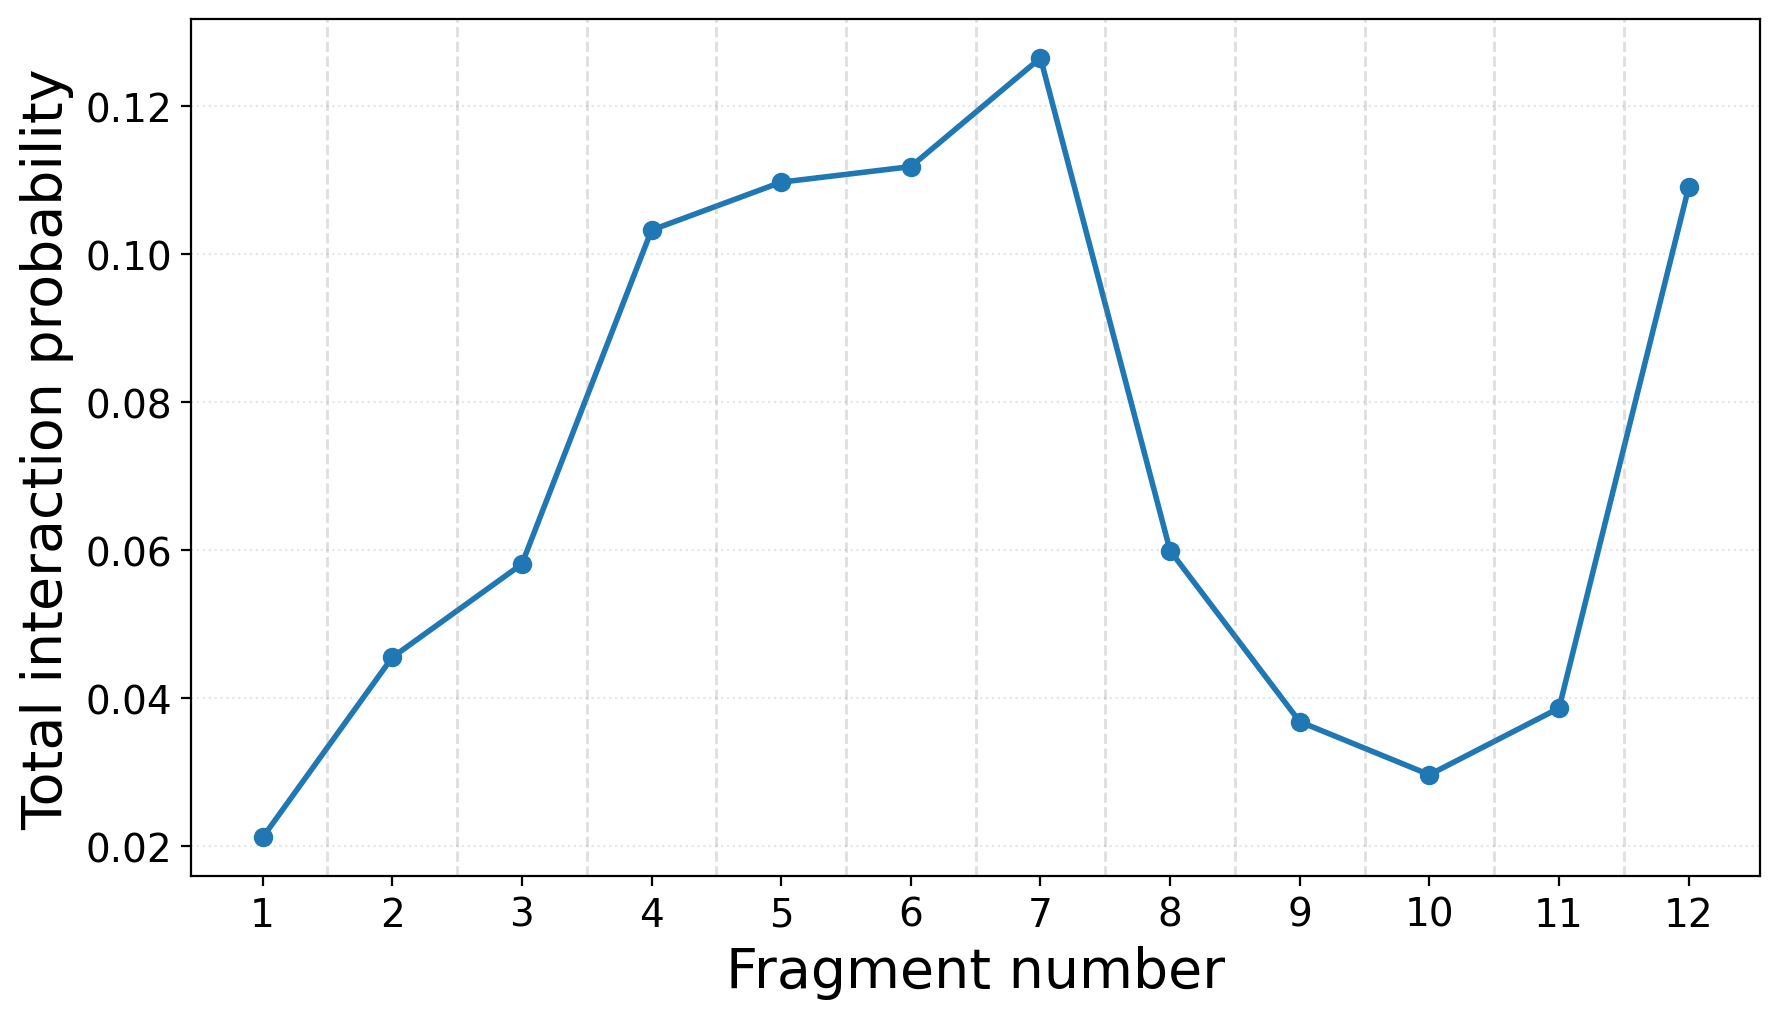

In [11]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

outdir = Path("interaction_outputs_by_fragment")
csv_file = outdir / "interaction_pair_probabilities_mean_over_trajs.csv"

df = pd.read_csv(csv_file)
df["fragment"] = df["fragment"].astype(int)

wanted_interactions = ["pi_pi", "cation_pi", "salt_bridge", "hydrophobic", "polar"]
df = df[df["interaction"].isin(wanted_interactions)].copy()

# Sum over all residue pairs for each fragment and interaction type
frag_interaction_df = (
    df.groupby(["fragment", "interaction"], as_index=False)
      .agg(fragment_interaction_probability=("mean_probability_over_trajs", "sum"))
)

# Sum over the five interaction types for each fragment
frag_total_df = (
    frag_interaction_df.groupby("fragment", as_index=False)
    .agg(total_interaction_probability=("fragment_interaction_probability", "sum"))
    .sort_values("fragment")
    .reset_index(drop=True)
)

# Optional: save the table used for plotting
frag_total_df.to_csv(outdir / "fragment_total_interaction_probability.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.2), dpi=200)

ax.plot(
    frag_total_df["fragment"],
    frag_total_df["total_interaction_probability"],
    marker="o",
    markersize=6,
    linewidth=2
)

ax.set_xlabel("Fragment number", fontsize=20)
ax.set_ylabel("Total interaction probability", fontsize=20)

ax.set_xticks(range(1, 13))
ax.tick_params(axis="both", labelsize=14)

ax.grid(True, axis="y", linestyle=":", alpha=0.3)

# Put separators between fragments
for x in range(1, 12):
    ax.axvline(x + 0.5, color="gray", linestyle="--", alpha=0.25, linewidth=1)

plt.tight_layout()
plt.show()

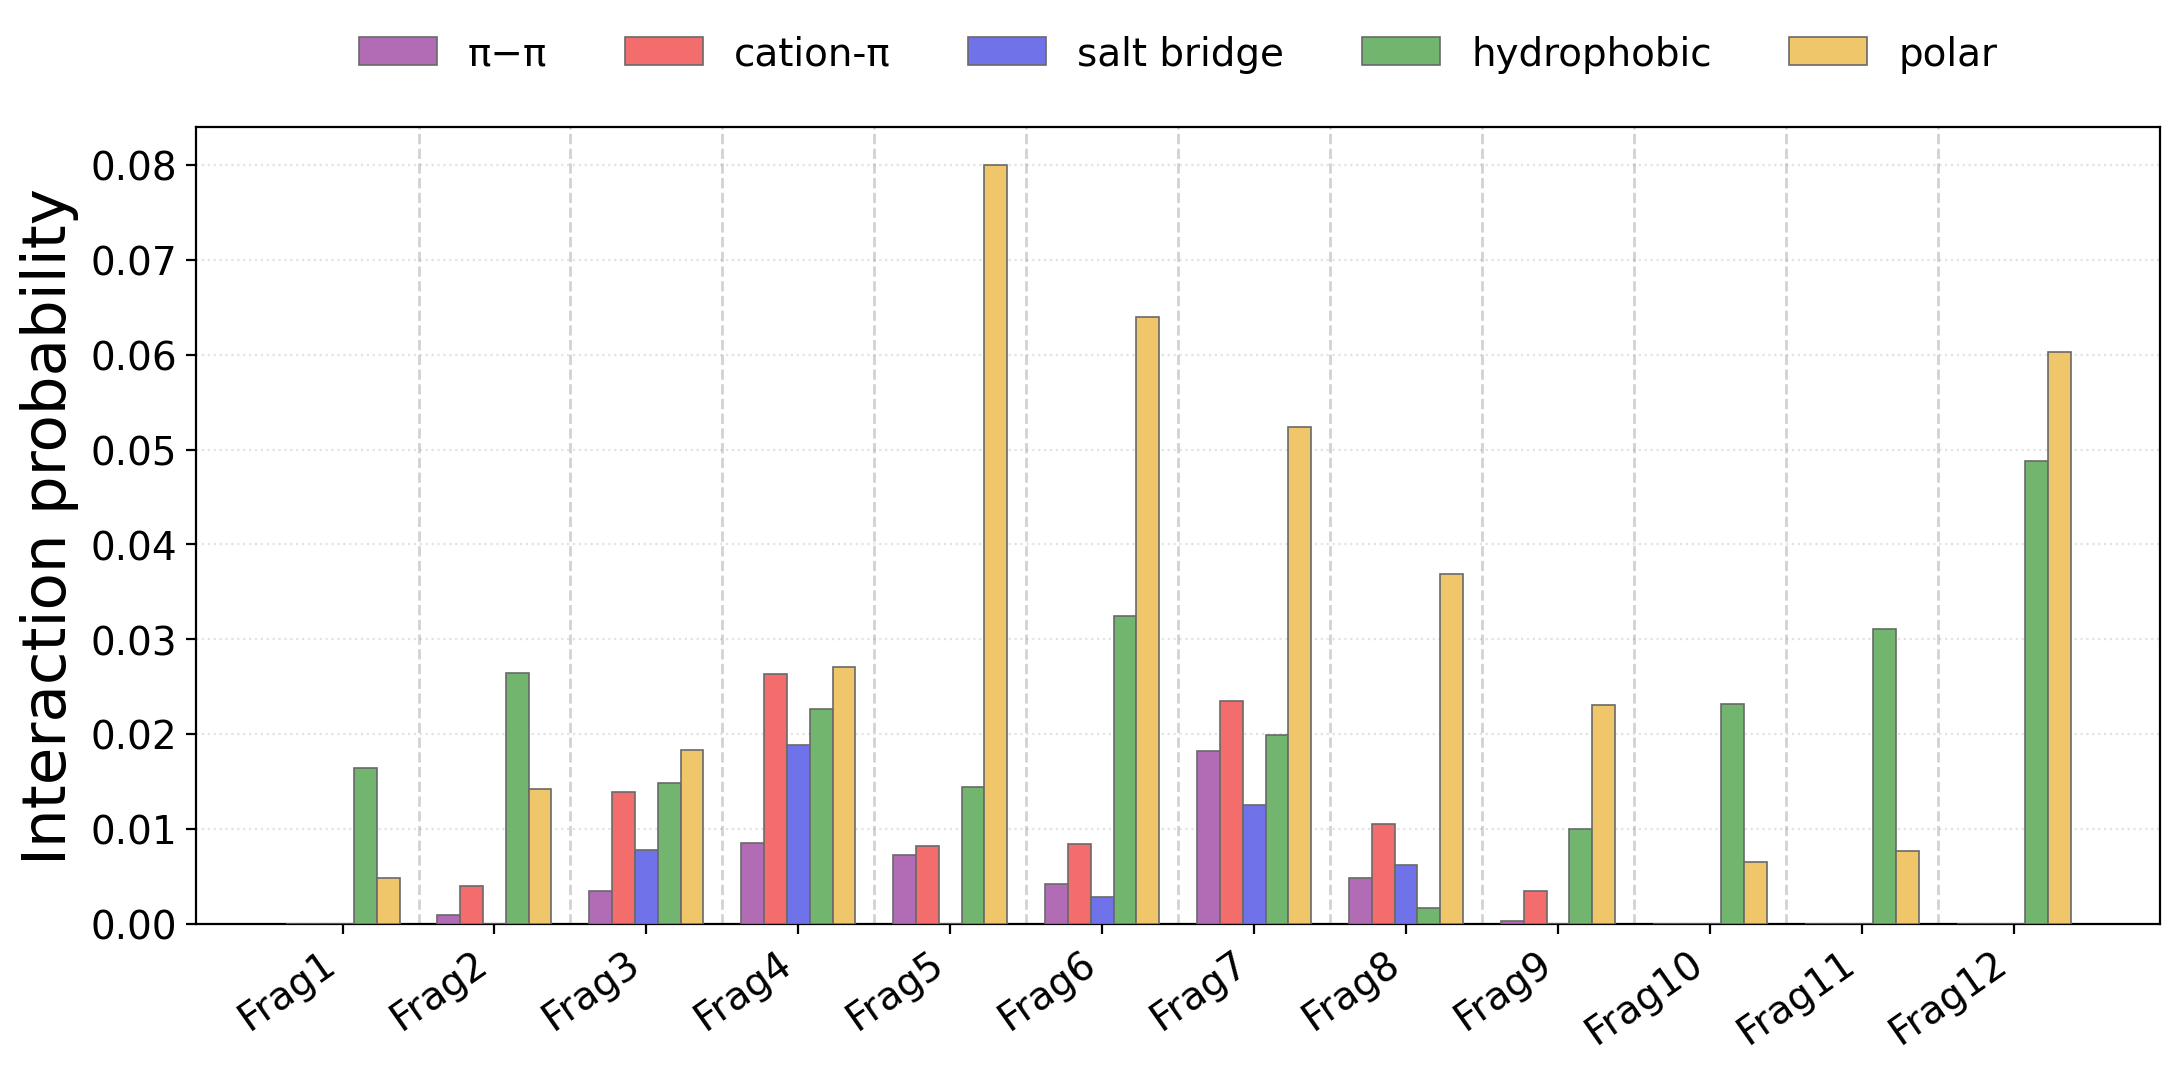

In [12]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Input
# =========================================================
outdir = Path("interaction_outputs_by_fragment")
csv_file = outdir / "interaction_pair_probabilities_mean_over_trajs.csv"

# =========================================================
# Read data
# =========================================================
df = pd.read_csv(csv_file)
df["fragment"] = df["fragment"].astype(int)

# Keep only the five interaction types
wanted_interactions = ["pi_pi", "cation_pi", "salt_bridge", "hydrophobic", "polar"]
df = df[df["interaction"].isin(wanted_interactions)].copy()

# =========================================================
# For each fragment and interaction type:
# sum all residue-pair probabilities
# =========================================================
frag_interaction_df = (
    df.groupby(["fragment", "interaction"], as_index=False)
      .agg(interaction_probability=("mean_probability_over_trajs", "sum"))
)

# Optional: save the table used for plotting
frag_interaction_df.to_csv(outdir / "fragment_interaction_type_probabilities.csv", index=False)

# =========================================================
# Pivot for grouped bar plot
# =========================================================
interaction_order = ["pi_pi", "cation_pi", "salt_bridge", "hydrophobic", "polar"]

plot_df = (
    frag_interaction_df.pivot(index="fragment", columns="interaction", values="interaction_probability")
    .fillna(0.0)
)

# Force fragments 1..12 to appear
plot_df = plot_df.reindex(range(1, 13), fill_value=0.0)

# Make sure all five columns exist
for col in interaction_order:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df = plot_df[interaction_order]
plot_df = plot_df.sort_index()

# Rename x tick labels
frag_labels = [f"Frag{i}" for i in plot_df.index]

# =========================================================
# Plot
# =========================================================
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=200)

x = np.arange(len(plot_df.index))
bar_width = 0.15

colors = {
    "pi_pi": "#b26cb5",         # purple
    "cation_pi": "#f46d6d",     # red/pink
    "salt_bridge": "#6f72e8",   # blue
    "hydrophobic": "#72b56f",   # green
    "polar": "#f0c66b",         # yellow/orange
}

labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
    "hydrophobic": "hydrophobic",
    "polar": "polar",
}

# Center the 5 bars around each fragment position
offsets = np.array([-2, -1, 0, 1, 2]) * bar_width

for i, interaction in enumerate(interaction_order):
    ax.bar(
        x + offsets[i],
        plot_df[interaction].values,
        width=bar_width,
        label=labels_map[interaction],
        color=colors[interaction],
        edgecolor="dimgray",
        linewidth=0.6,
        zorder=3
    )

# =========================================================
# Formatting
# =========================================================
ax.set_xlabel("")
ax.set_ylabel("Interaction probability", fontsize=22)

ax.set_xticks(x)
ax.set_xticklabels(frag_labels, rotation=35, ha="right", fontsize=14)
ax.tick_params(axis="y", labelsize=14)

# Light horizontal grid
ax.grid(True, axis="y", linestyle=":", alpha=0.35, zorder=0)

# Gray dashed lines separating fragments
for i in range(len(x) - 1):
    ax.axvline(i + 0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)

# Legend at top
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.16),
    ncol=5,
    frameon=False,
    fontsize=14
)

plt.tight_layout()
plt.show()

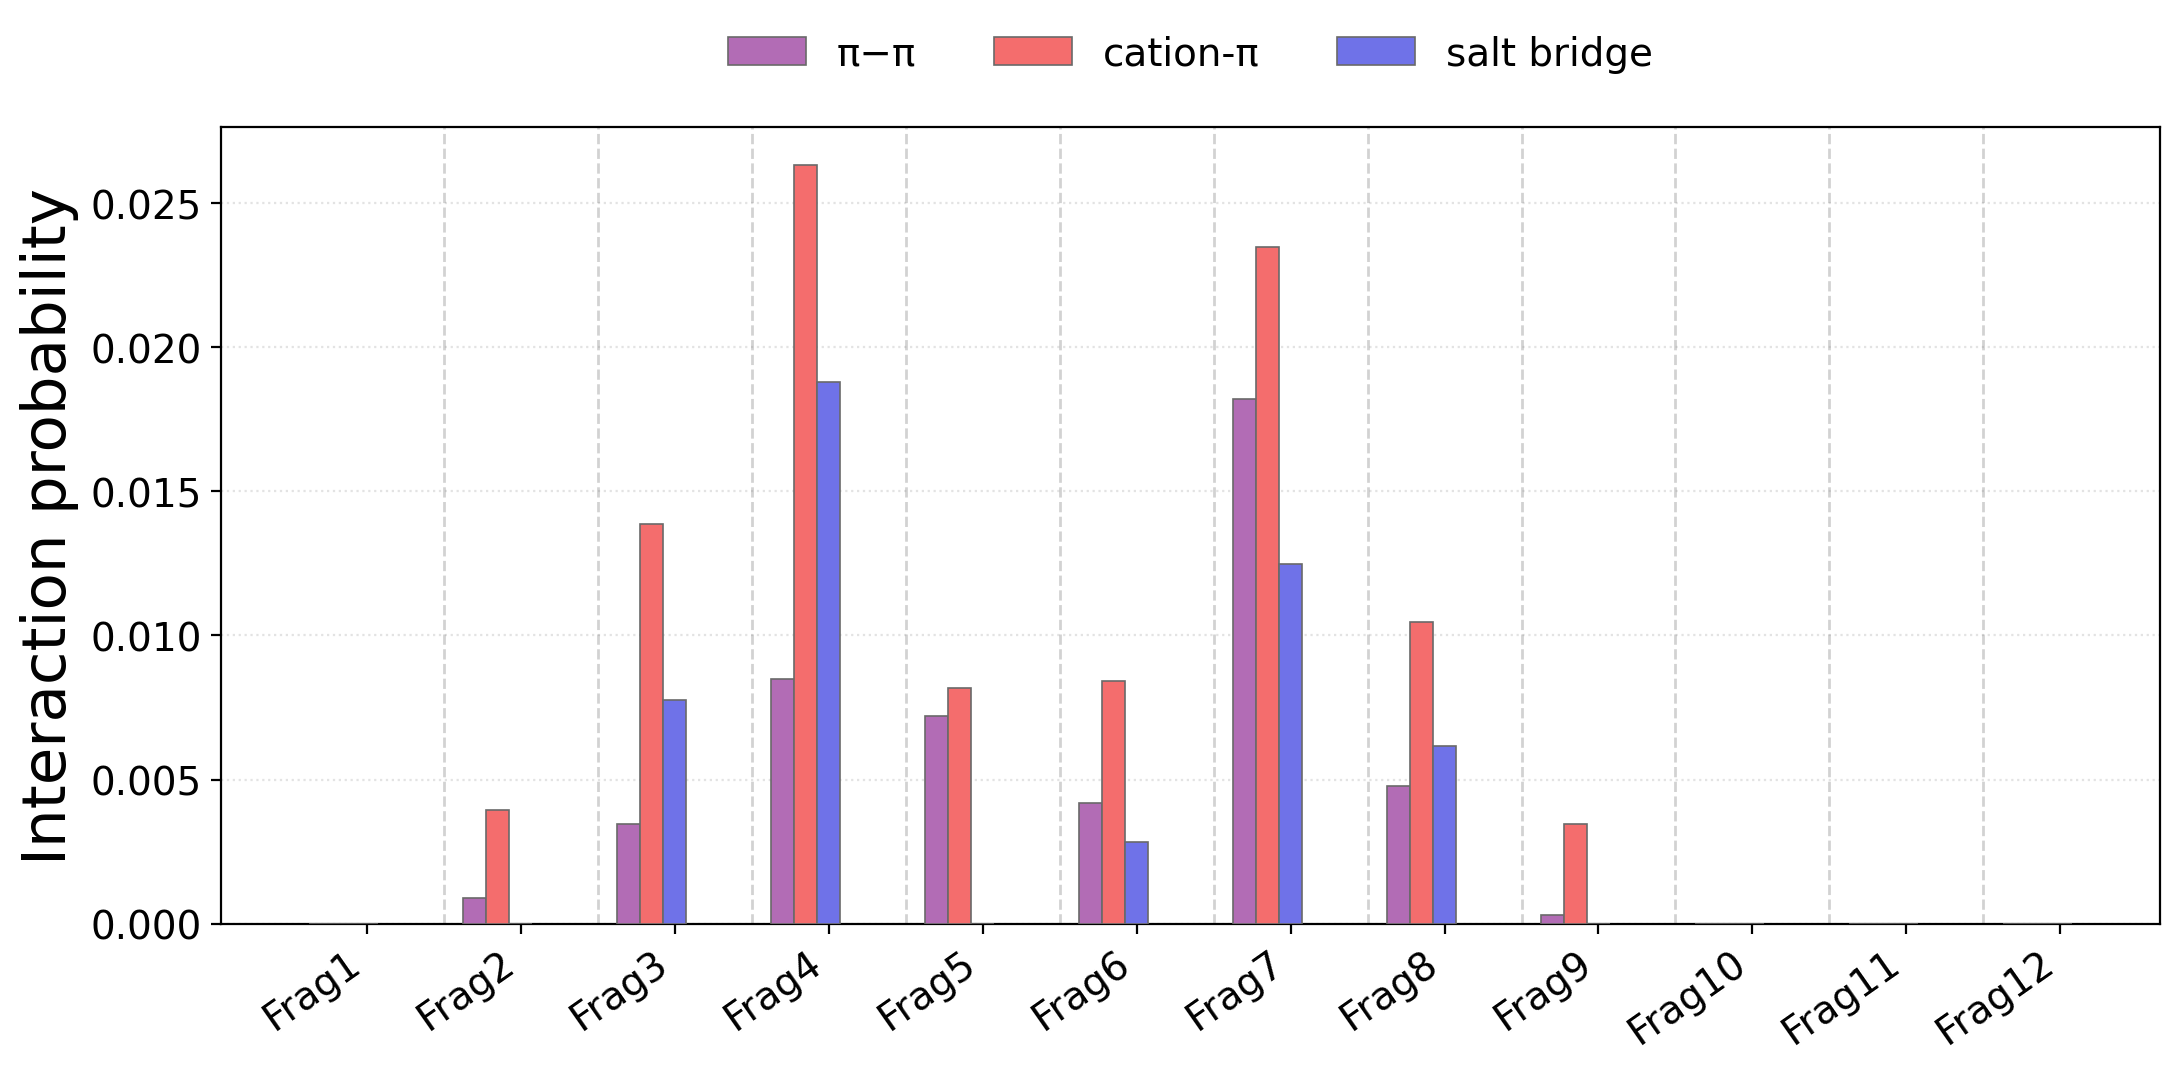

In [14]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Input
# =========================================================
outdir = Path("interaction_outputs_by_fragment")
csv_file = outdir / "interaction_pair_probabilities_mean_over_trajs.csv"

# =========================================================
# Read data
# =========================================================
df = pd.read_csv(csv_file)
df["fragment"] = df["fragment"].astype(int)

# Keep only the five interaction types
wanted_interactions = ["pi_pi", "cation_pi", "salt_bridge"]
df = df[df["interaction"].isin(wanted_interactions)].copy()

# =========================================================
# For each fragment and interaction type:
# sum all residue-pair probabilities
# =========================================================
frag_interaction_df = (
    df.groupby(["fragment", "interaction"], as_index=False)
      .agg(interaction_probability=("mean_probability_over_trajs", "sum"))
)

# Optional: save the table used for plotting
frag_interaction_df.to_csv(outdir / "fragment_interaction_type_probabilities_3type-interaction.csv", index=False)

# =========================================================
# Pivot for grouped bar plot
# =========================================================
interaction_order = ["pi_pi", "cation_pi", "salt_bridge"]

plot_df = (
    frag_interaction_df.pivot(index="fragment", columns="interaction", values="interaction_probability")
    .fillna(0.0)
)

# Force fragments 1..12 to appear
plot_df = plot_df.reindex(range(1, 13), fill_value=0.0)

# Make sure all five columns exist
for col in interaction_order:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df = plot_df[interaction_order]
plot_df = plot_df.sort_index()

# Rename x tick labels
frag_labels = [f"Frag{i}" for i in plot_df.index]

# =========================================================
# Plot
# =========================================================
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=200)

x = np.arange(len(plot_df.index))
bar_width = 0.15

colors = {
    "pi_pi": "#b26cb5",         # purple
    "cation_pi": "#f46d6d",     # red/pink
    "salt_bridge": "#6f72e8",   # blue
}

labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
}

# Center the 5 bars around each fragment position
offsets = np.array([-2, -1, 0, 1, 2]) * bar_width

for i, interaction in enumerate(interaction_order):
    ax.bar(
        x + offsets[i],
        plot_df[interaction].values,
        width=bar_width,
        label=labels_map[interaction],
        color=colors[interaction],
        edgecolor="dimgray",
        linewidth=0.6,
        zorder=3
    )

# =========================================================
# Formatting
# =========================================================
ax.set_xlabel("")
ax.set_ylabel("Interaction probability", fontsize=22)

ax.set_xticks(x)
ax.set_xticklabels(frag_labels, rotation=35, ha="right", fontsize=14)
ax.tick_params(axis="y", labelsize=14)

# Light horizontal grid
ax.grid(True, axis="y", linestyle=":", alpha=0.35, zorder=0)

# Gray dashed lines separating fragments
for i in range(len(x) - 1):
    ax.axvline(i + 0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)

# Legend at top
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.16),
    ncol=5,
    frameon=False,
    fontsize=14
)

plt.tight_layout()
plt.show()

Fragment 1 sequence: SRGVSRGGSRGARGLM


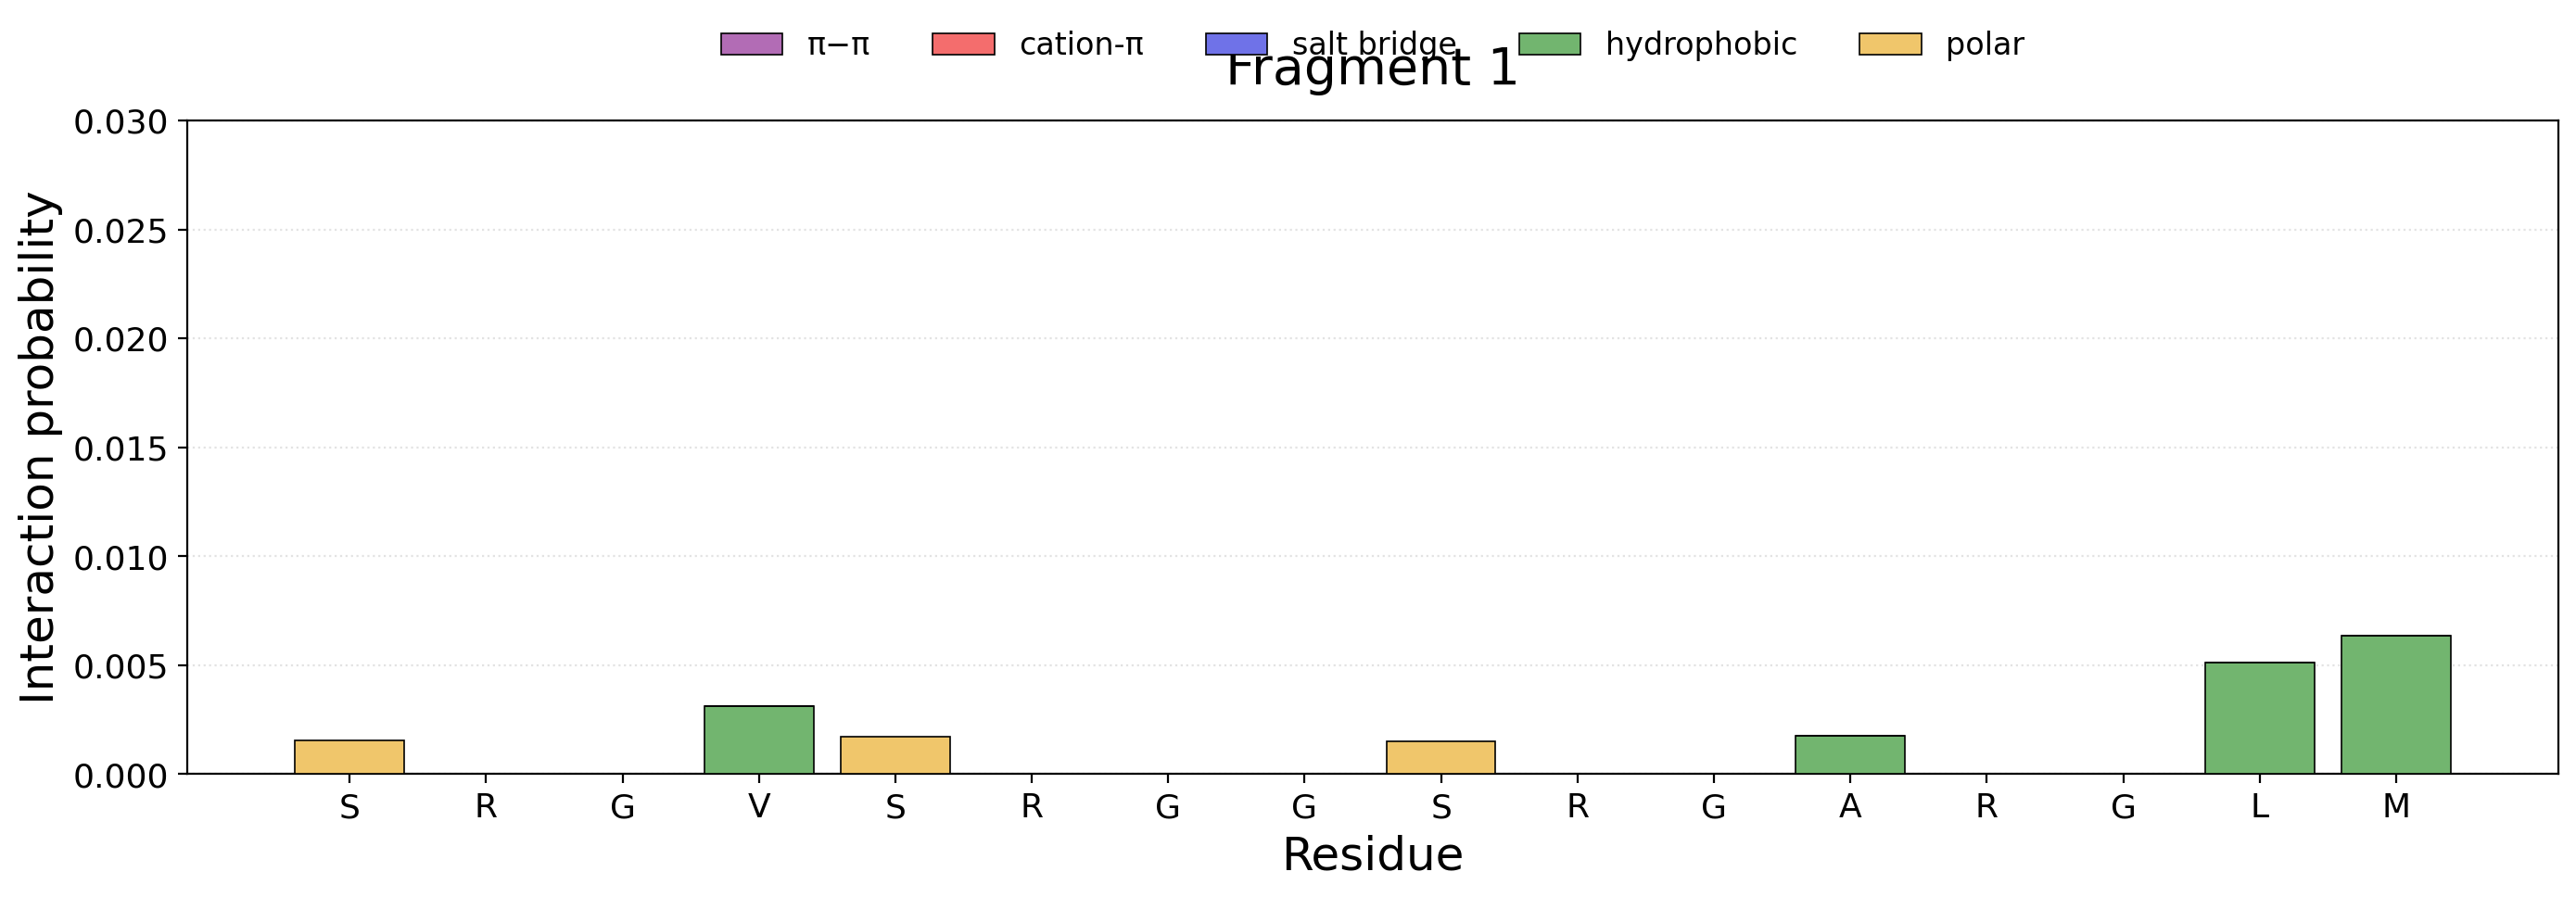

Fragment 2 sequence: SRGARGLMNGYRGPAN


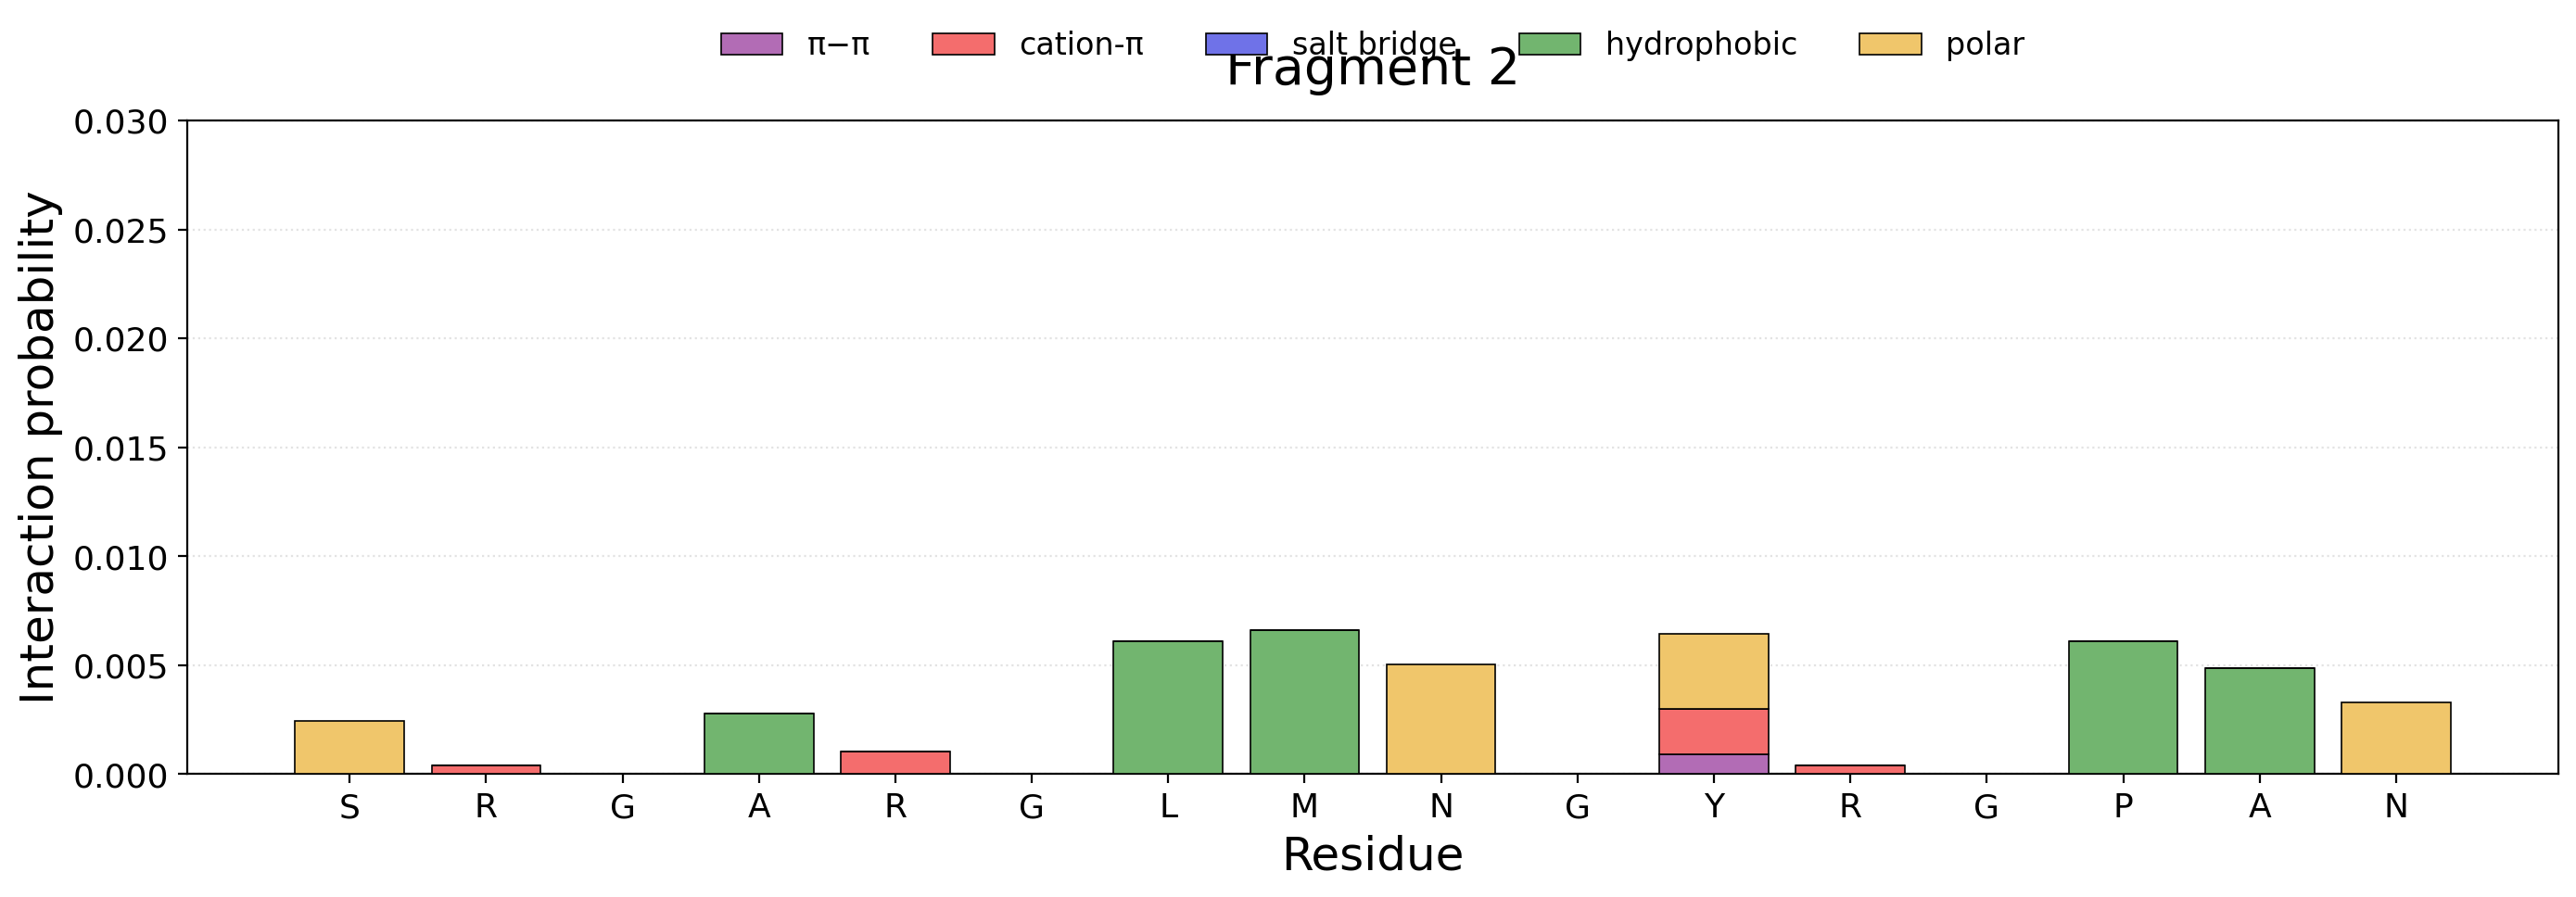

Fragment 3 sequence: NGYRGPANGFRGGYDG


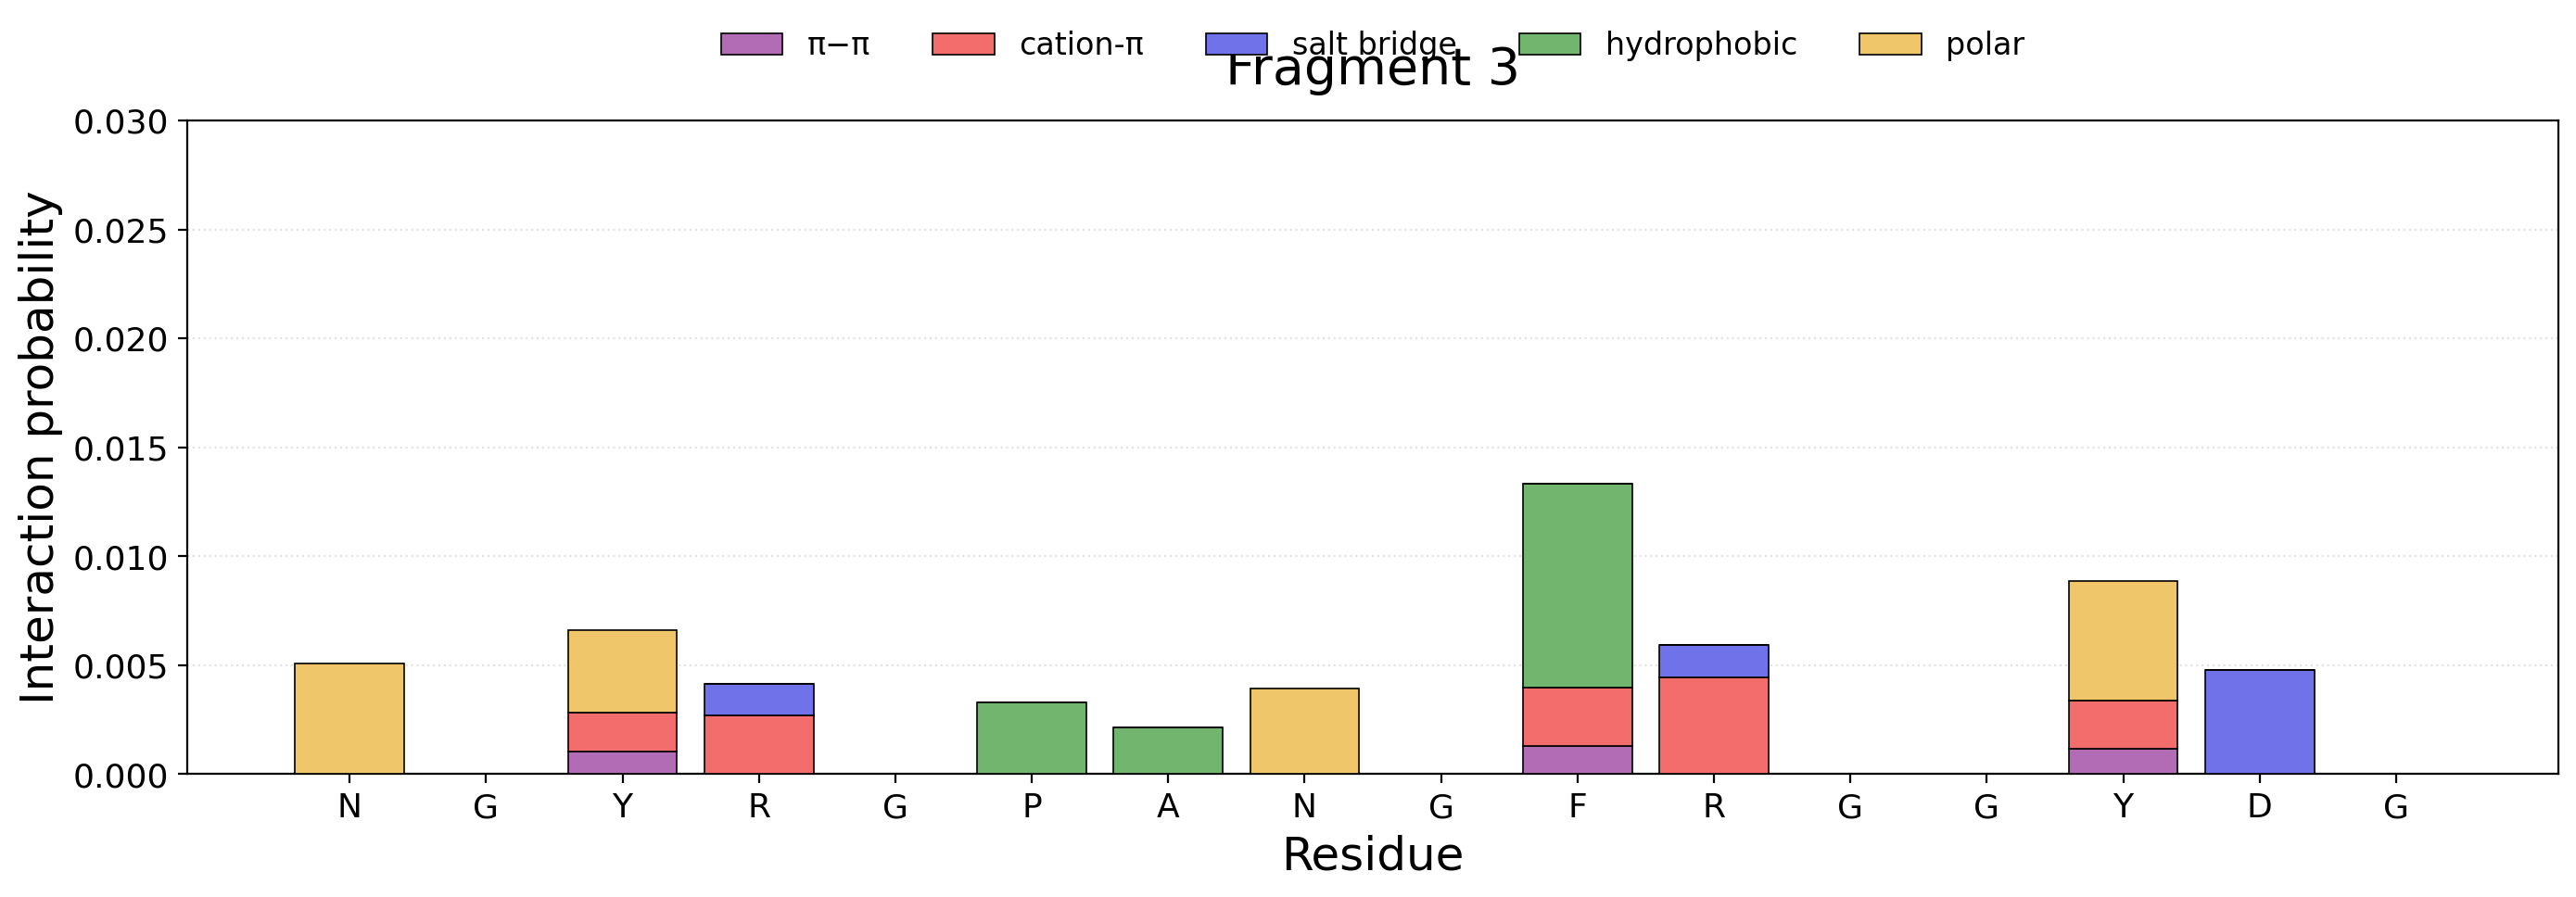

Fragment 4 sequence: GFRGGYDGYRPSFSNT


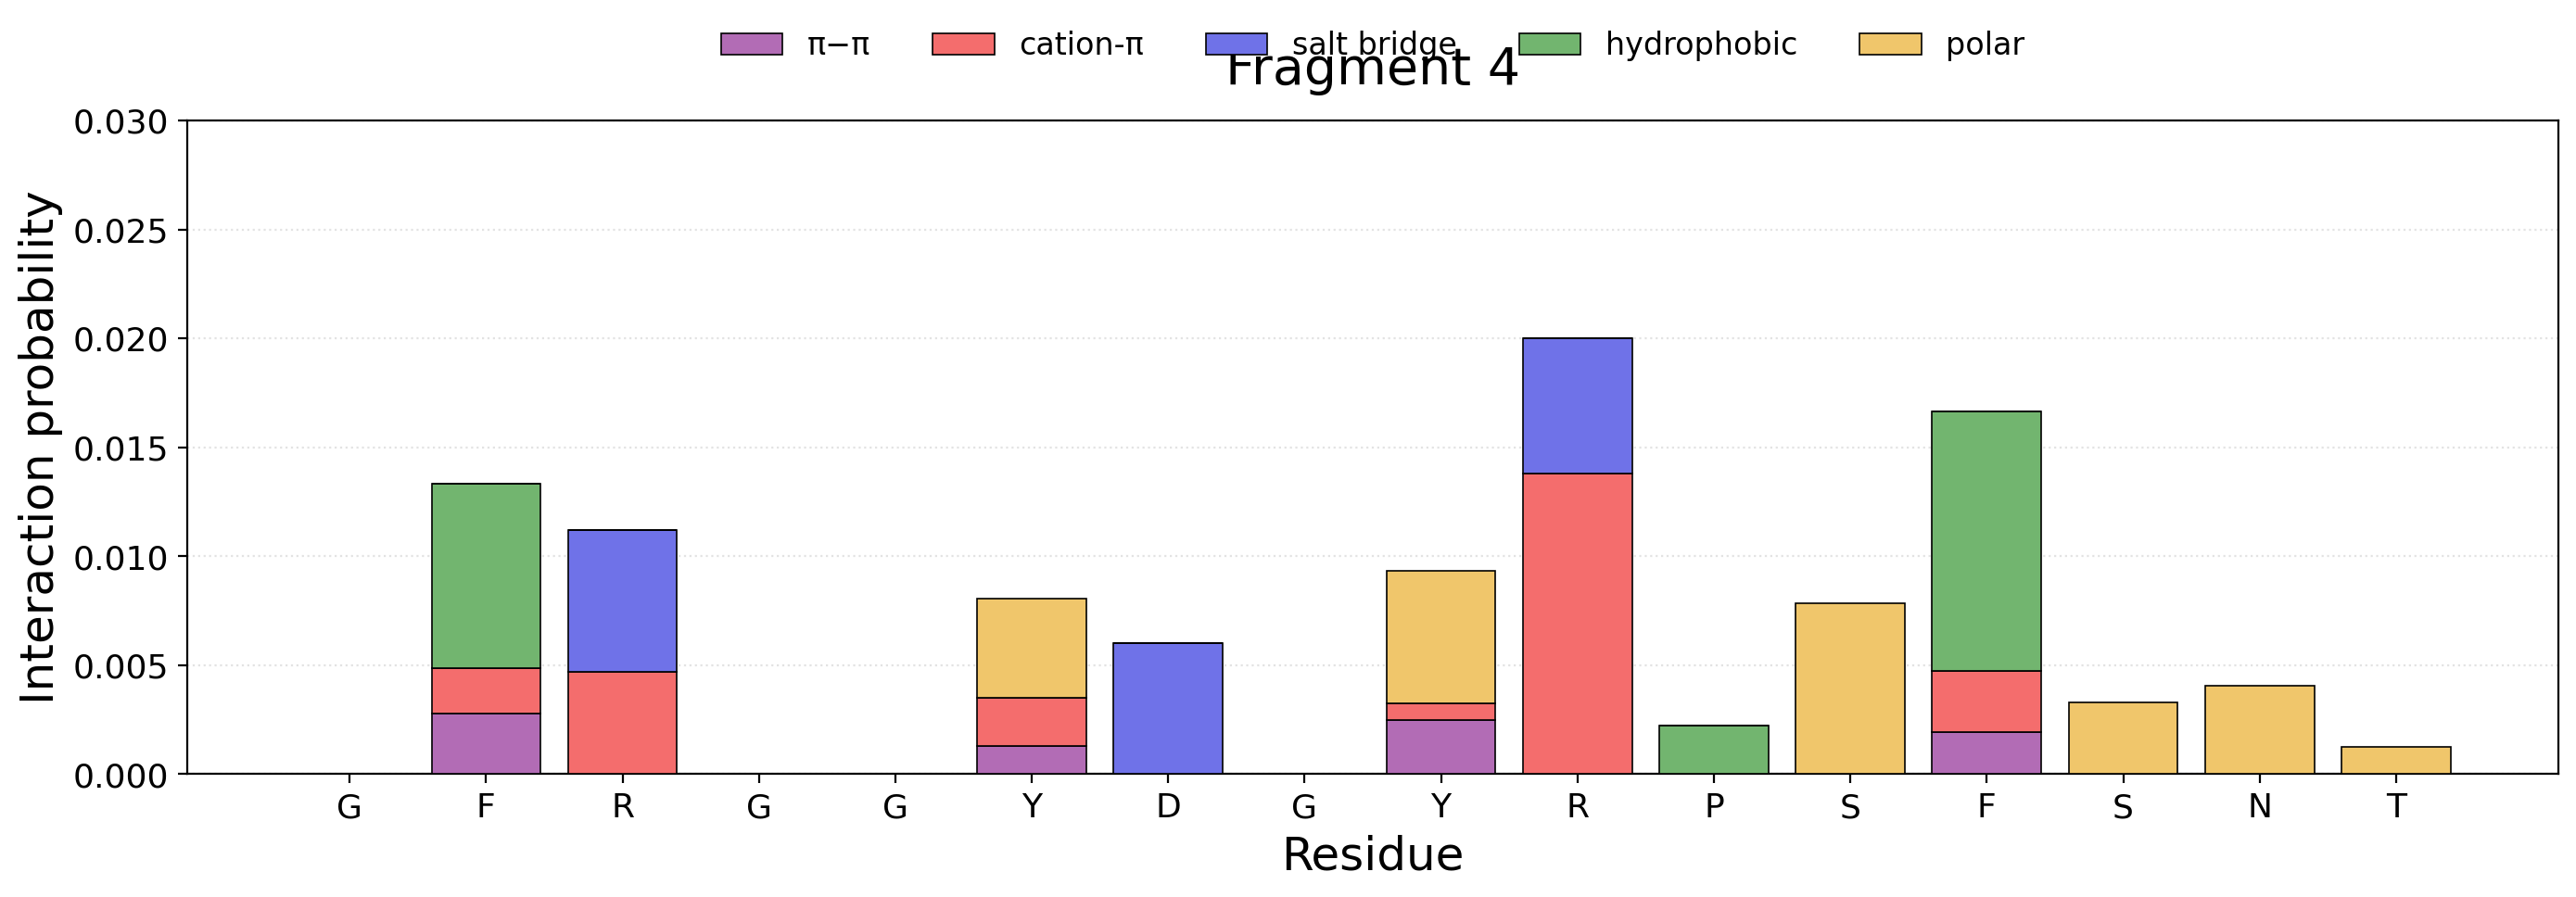

Fragment 5 sequence: YRPSFSNTPNSGYTQS


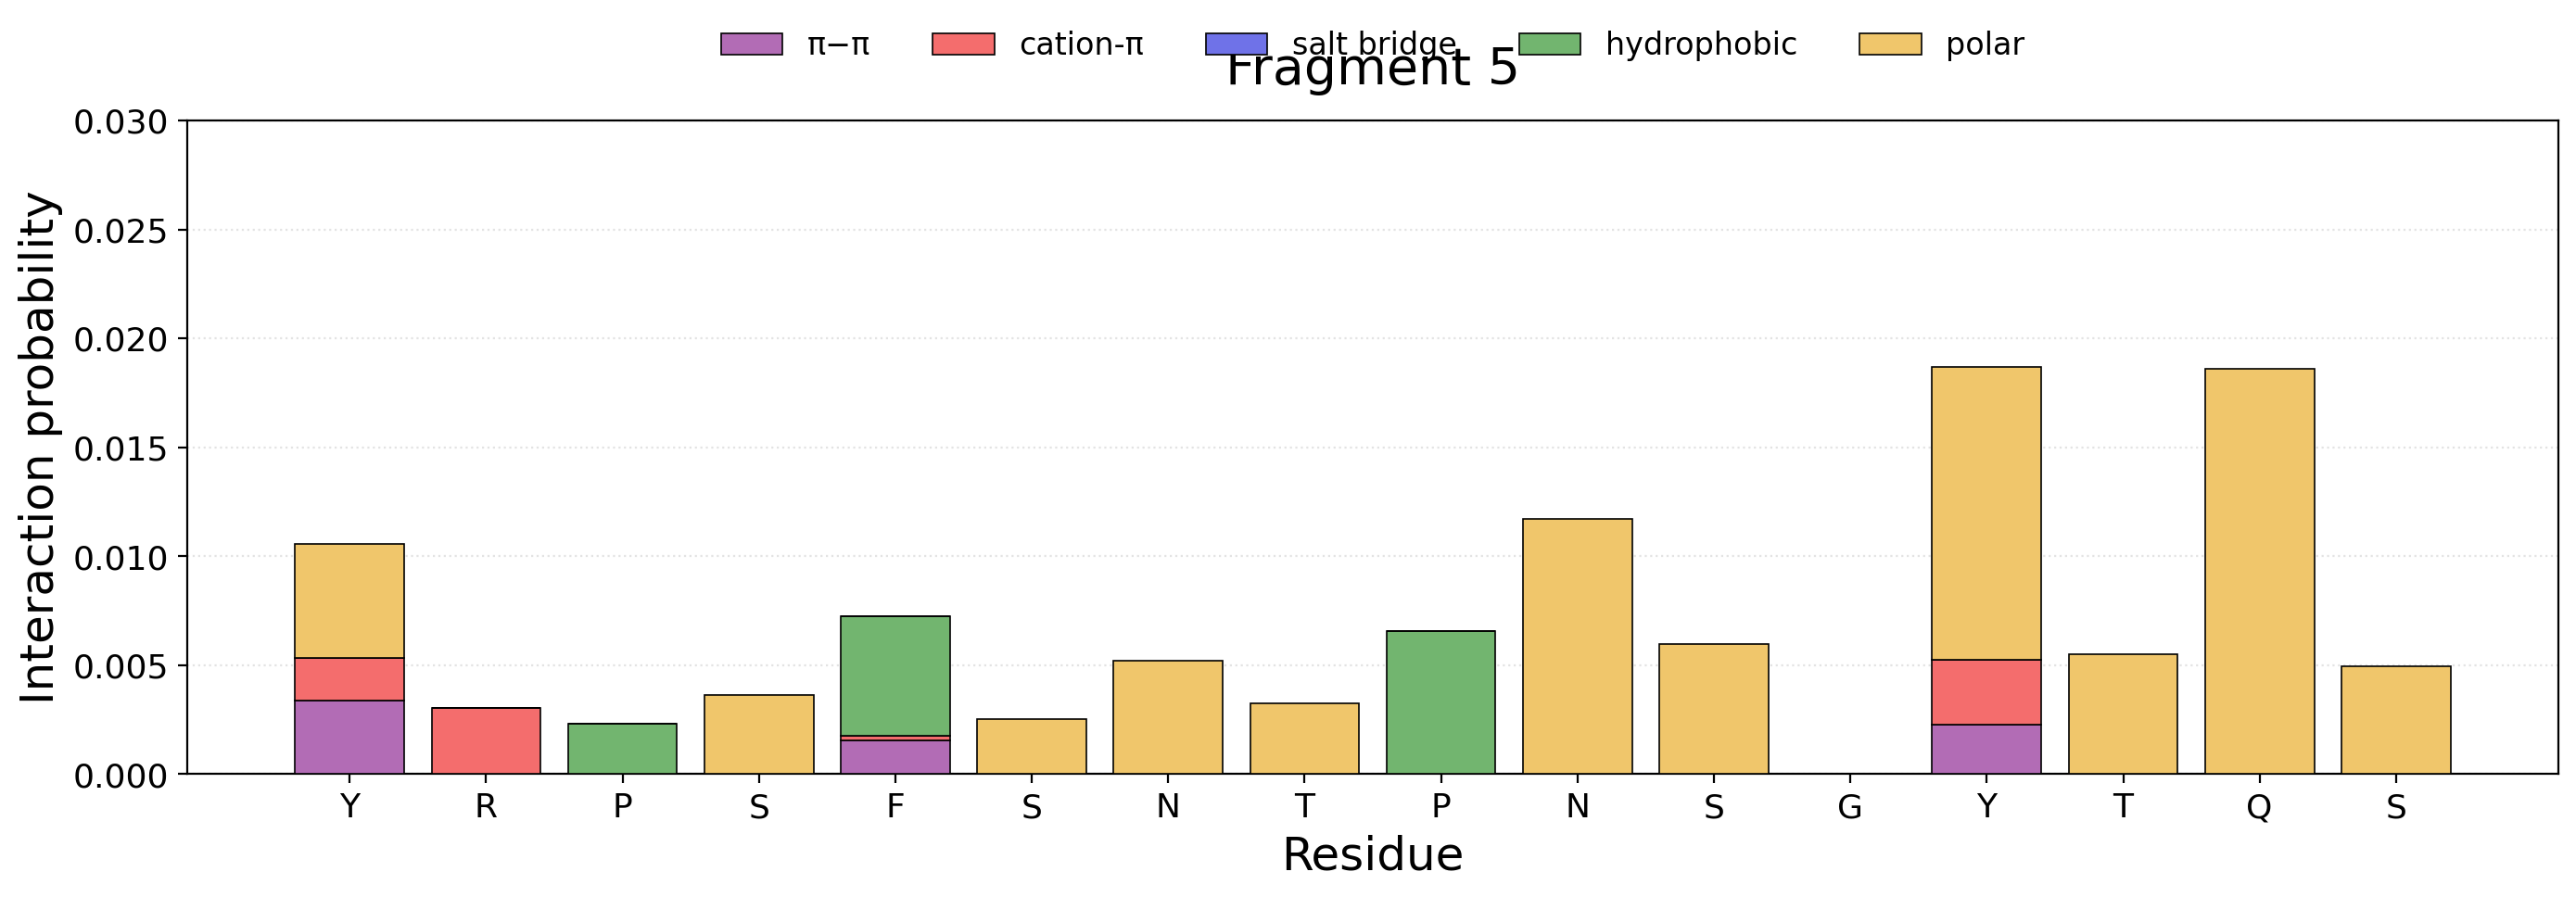

Fragment 6 sequence: PNSGYTQSQFSAPRDY


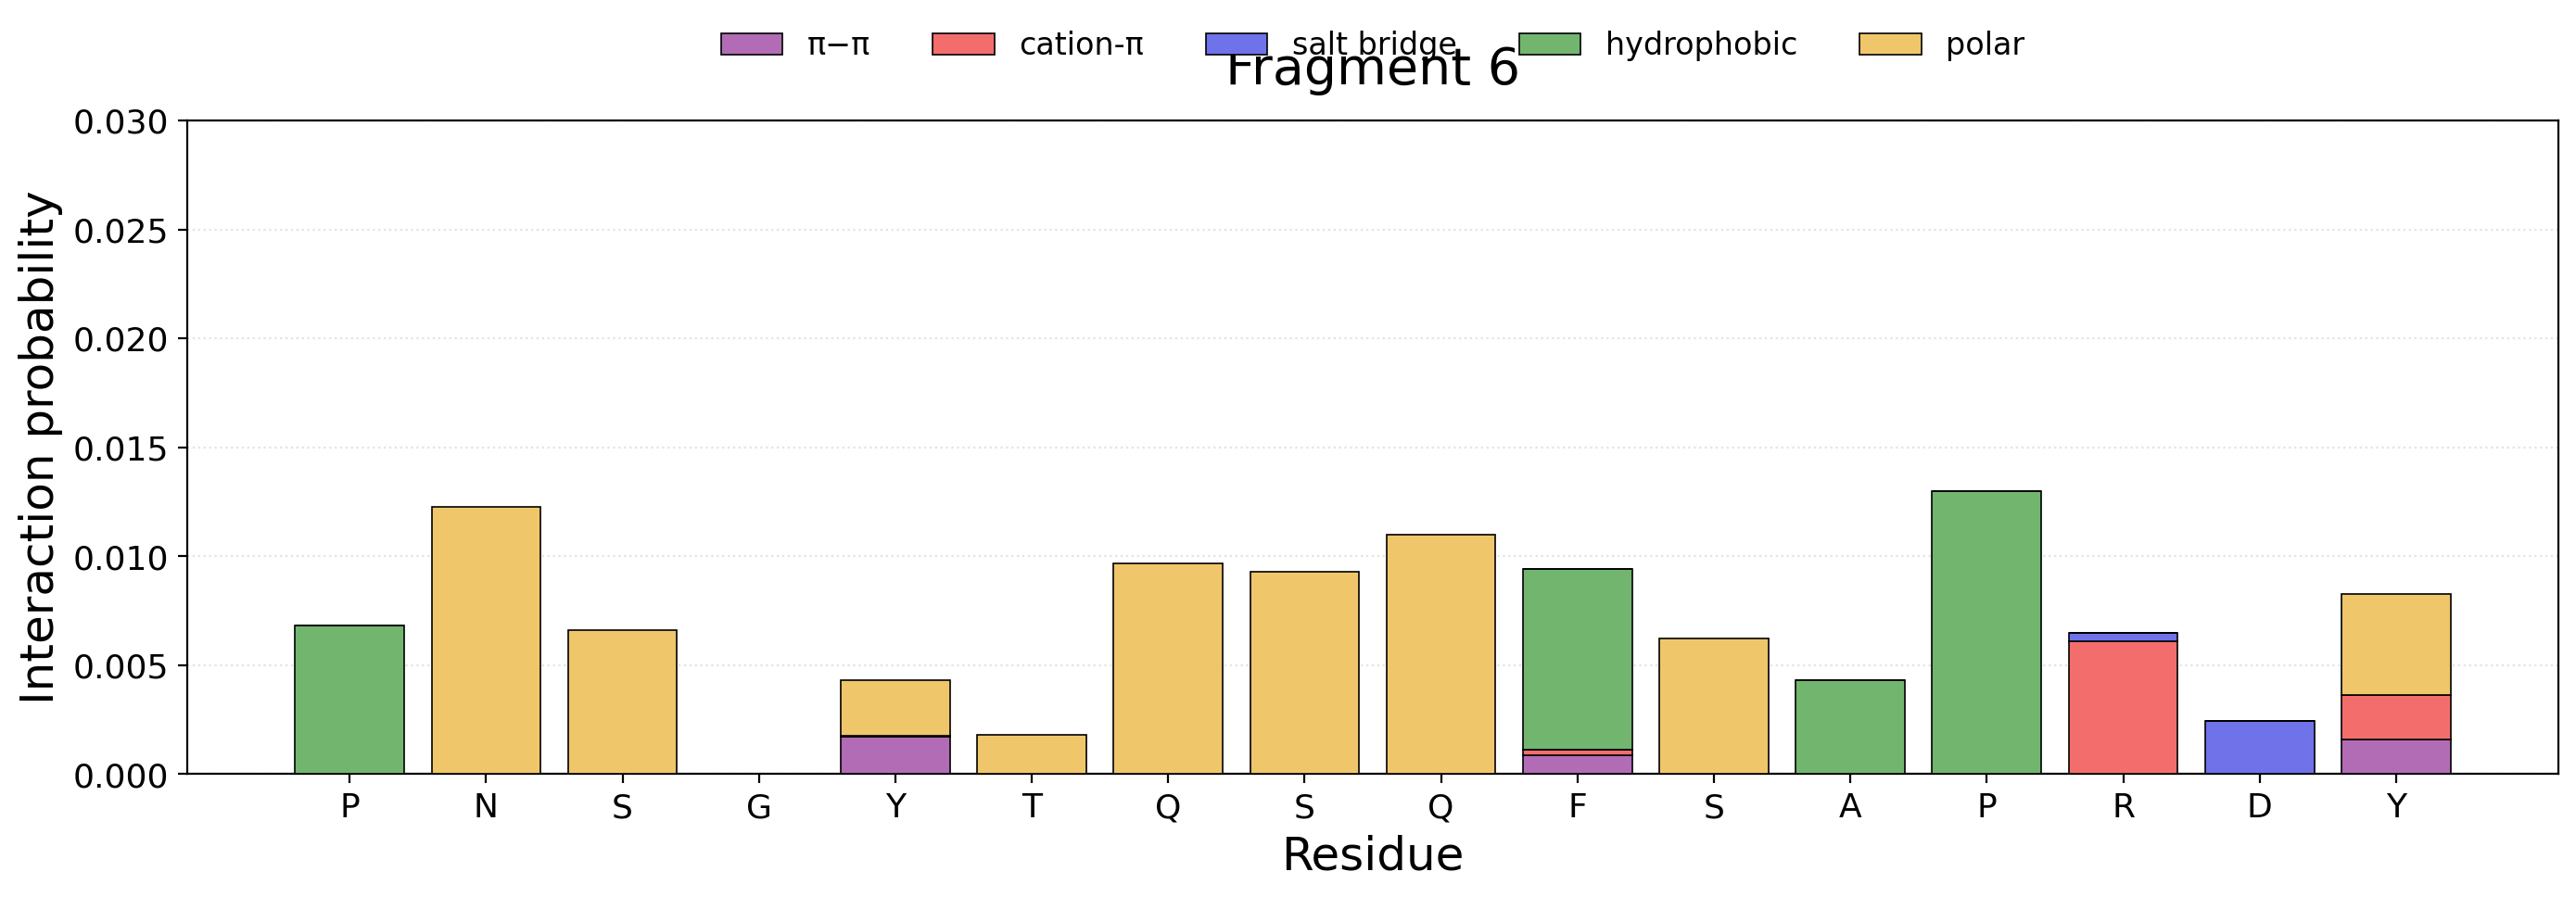

Fragment 7 sequence: QFSAPRDYSGYQRDGY


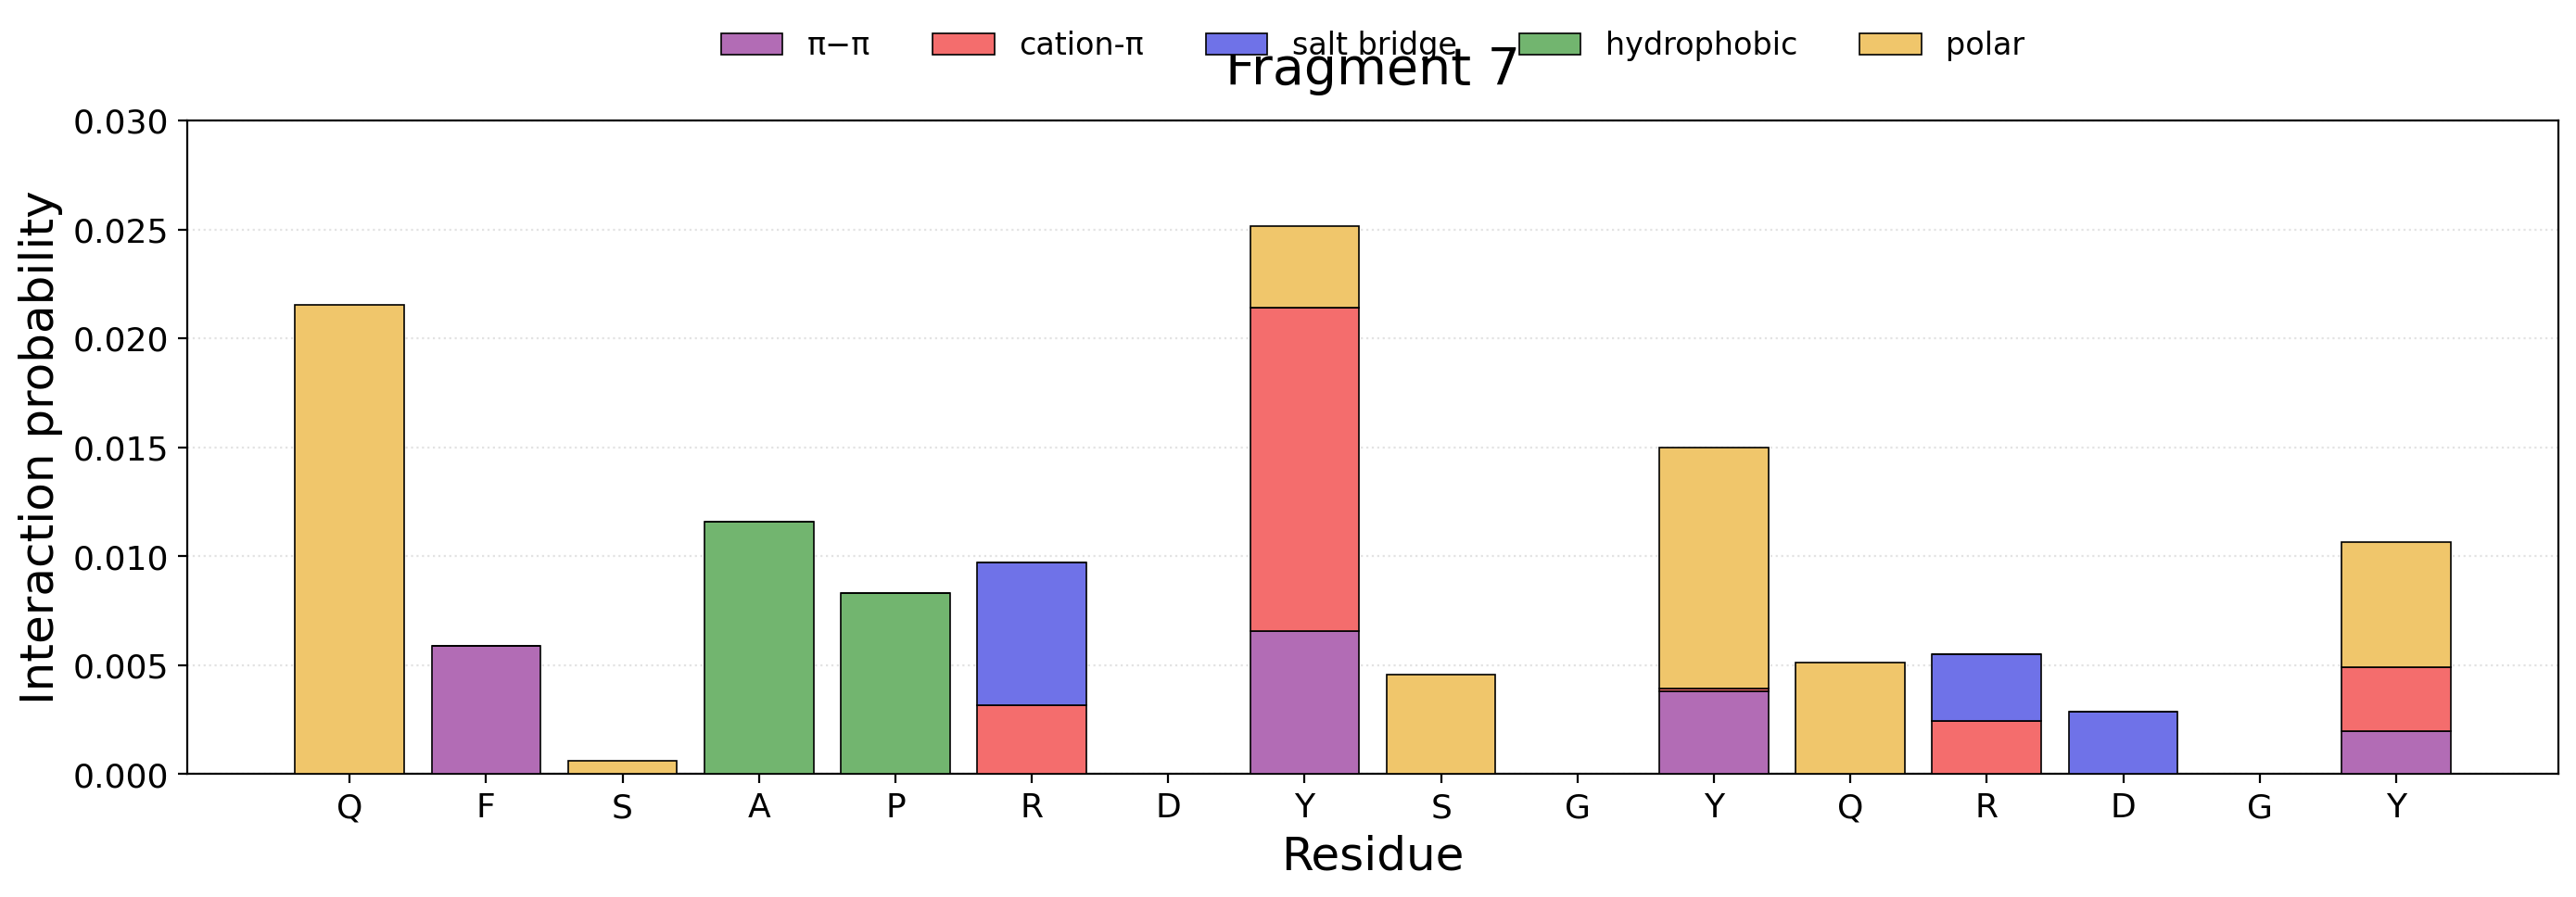

Fragment 8 sequence: SGYQRDGYQQNFKRGS


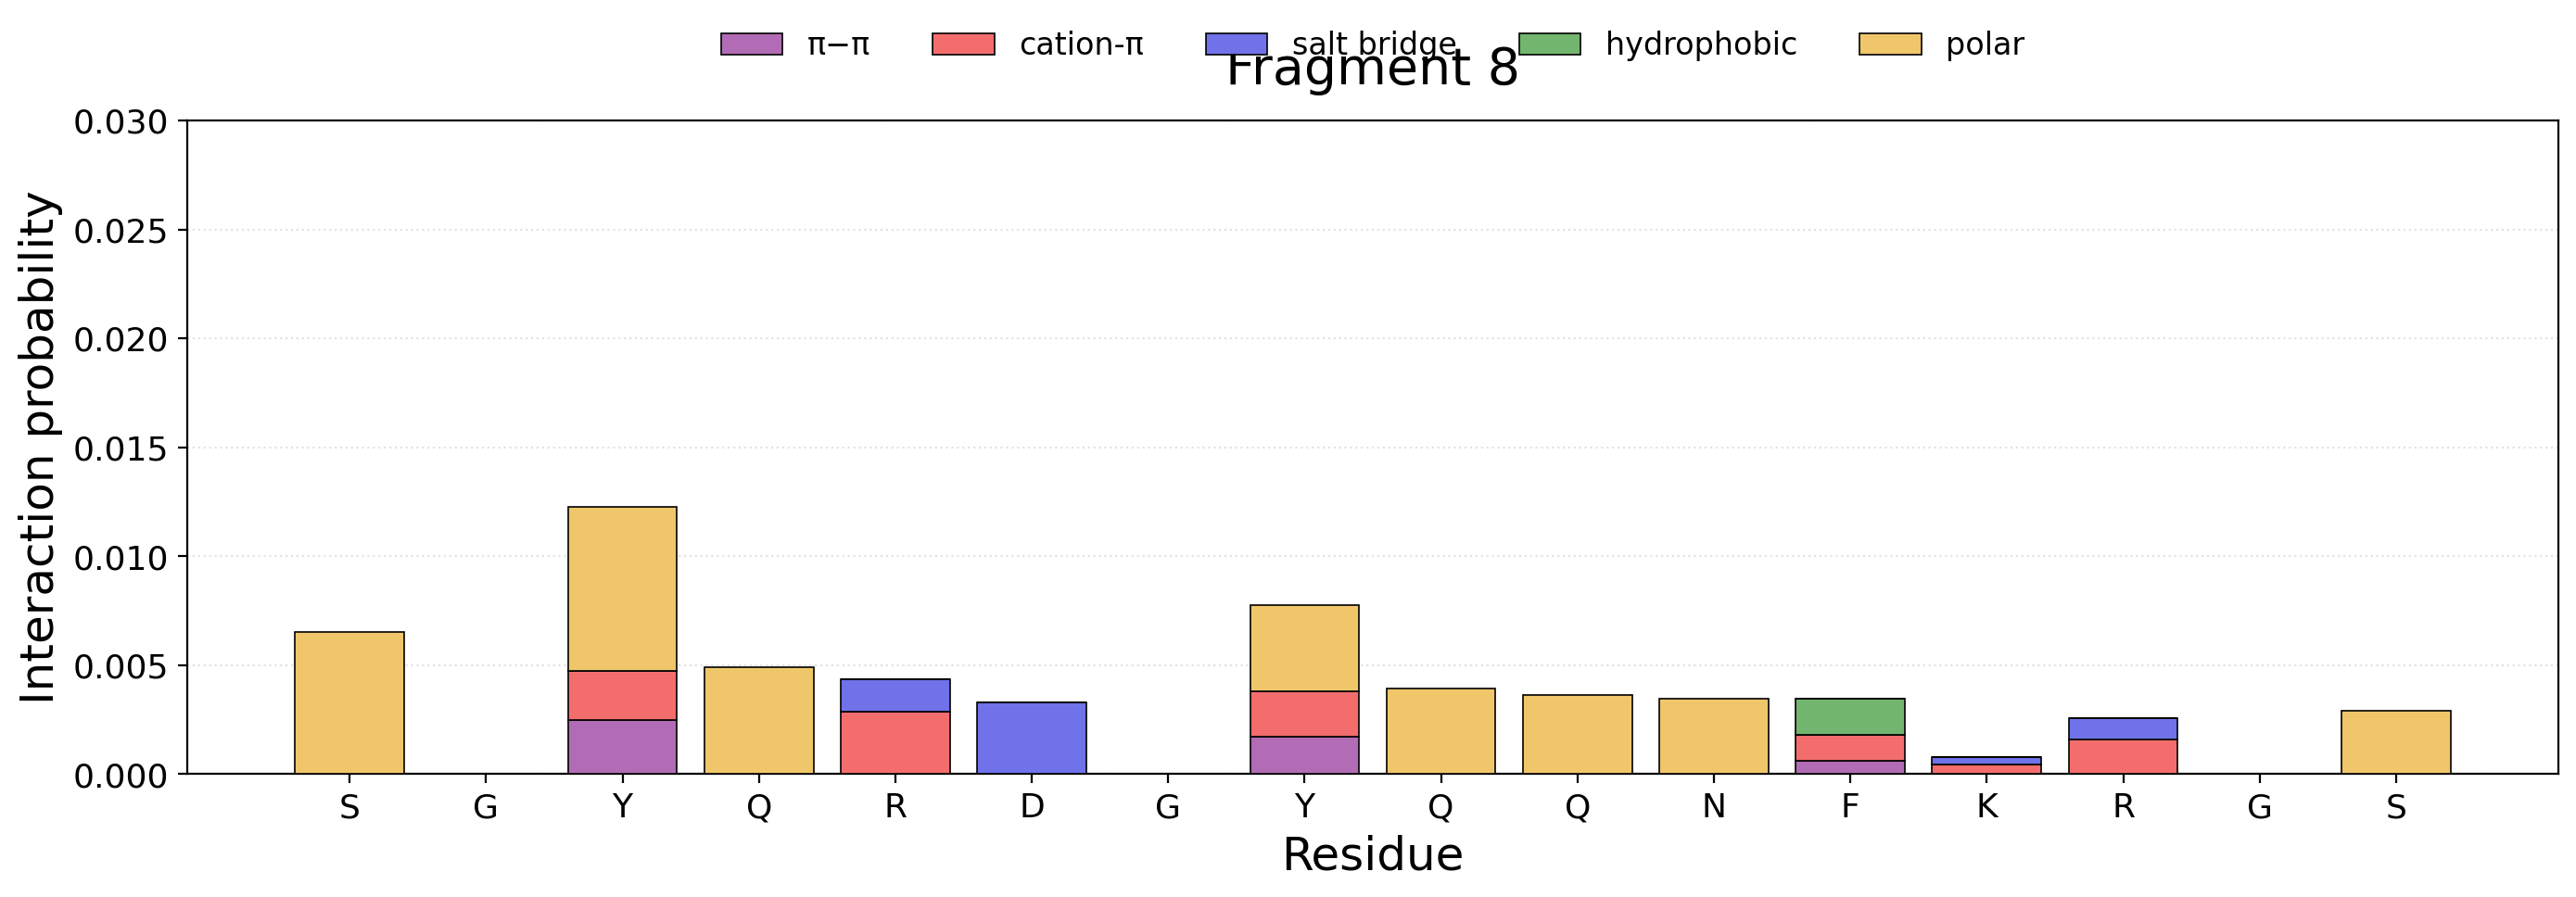

Fragment 9 sequence: QQNFKRGSGQSGPRGA


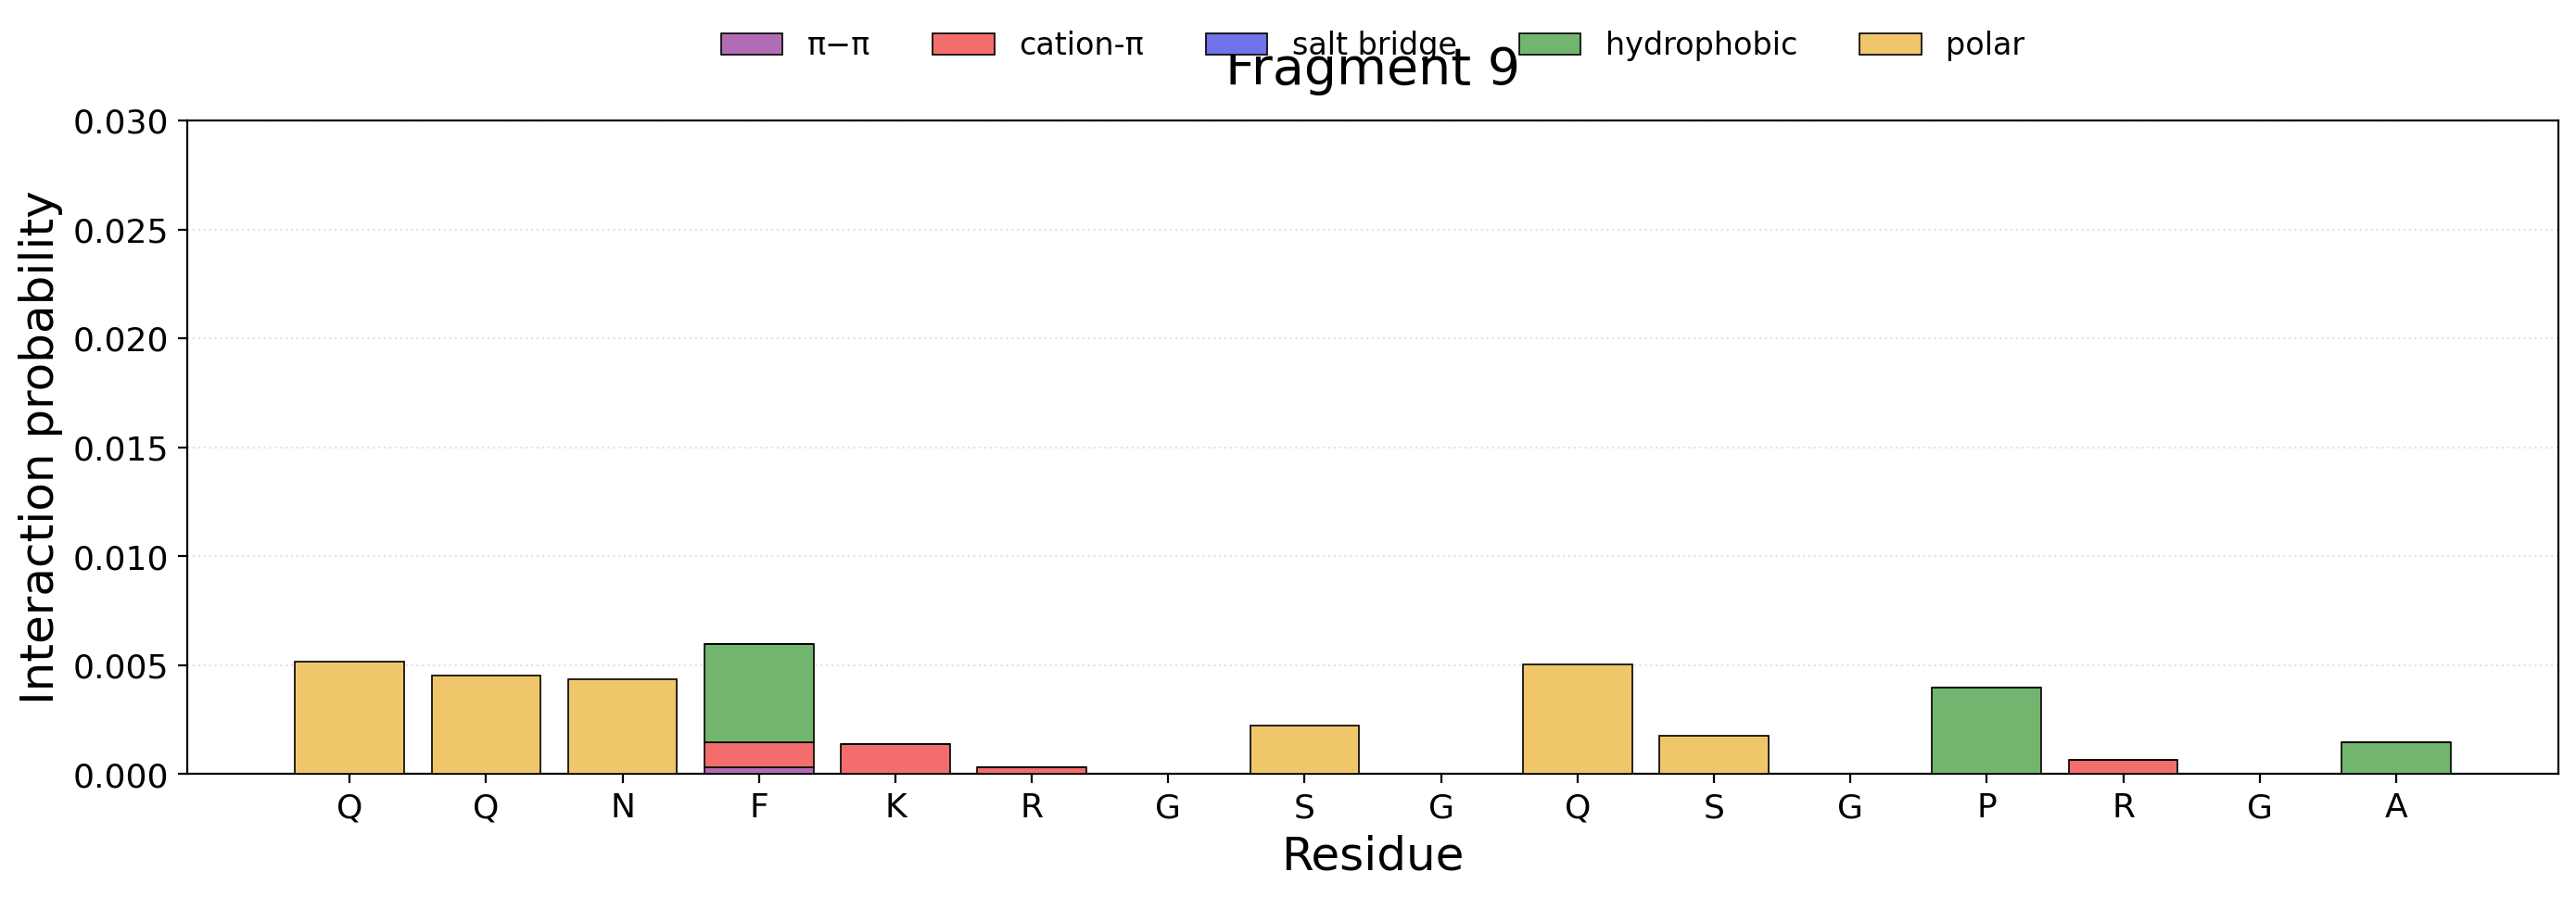

Fragment 10 sequence: GQSGPRGAPRGRGGPP


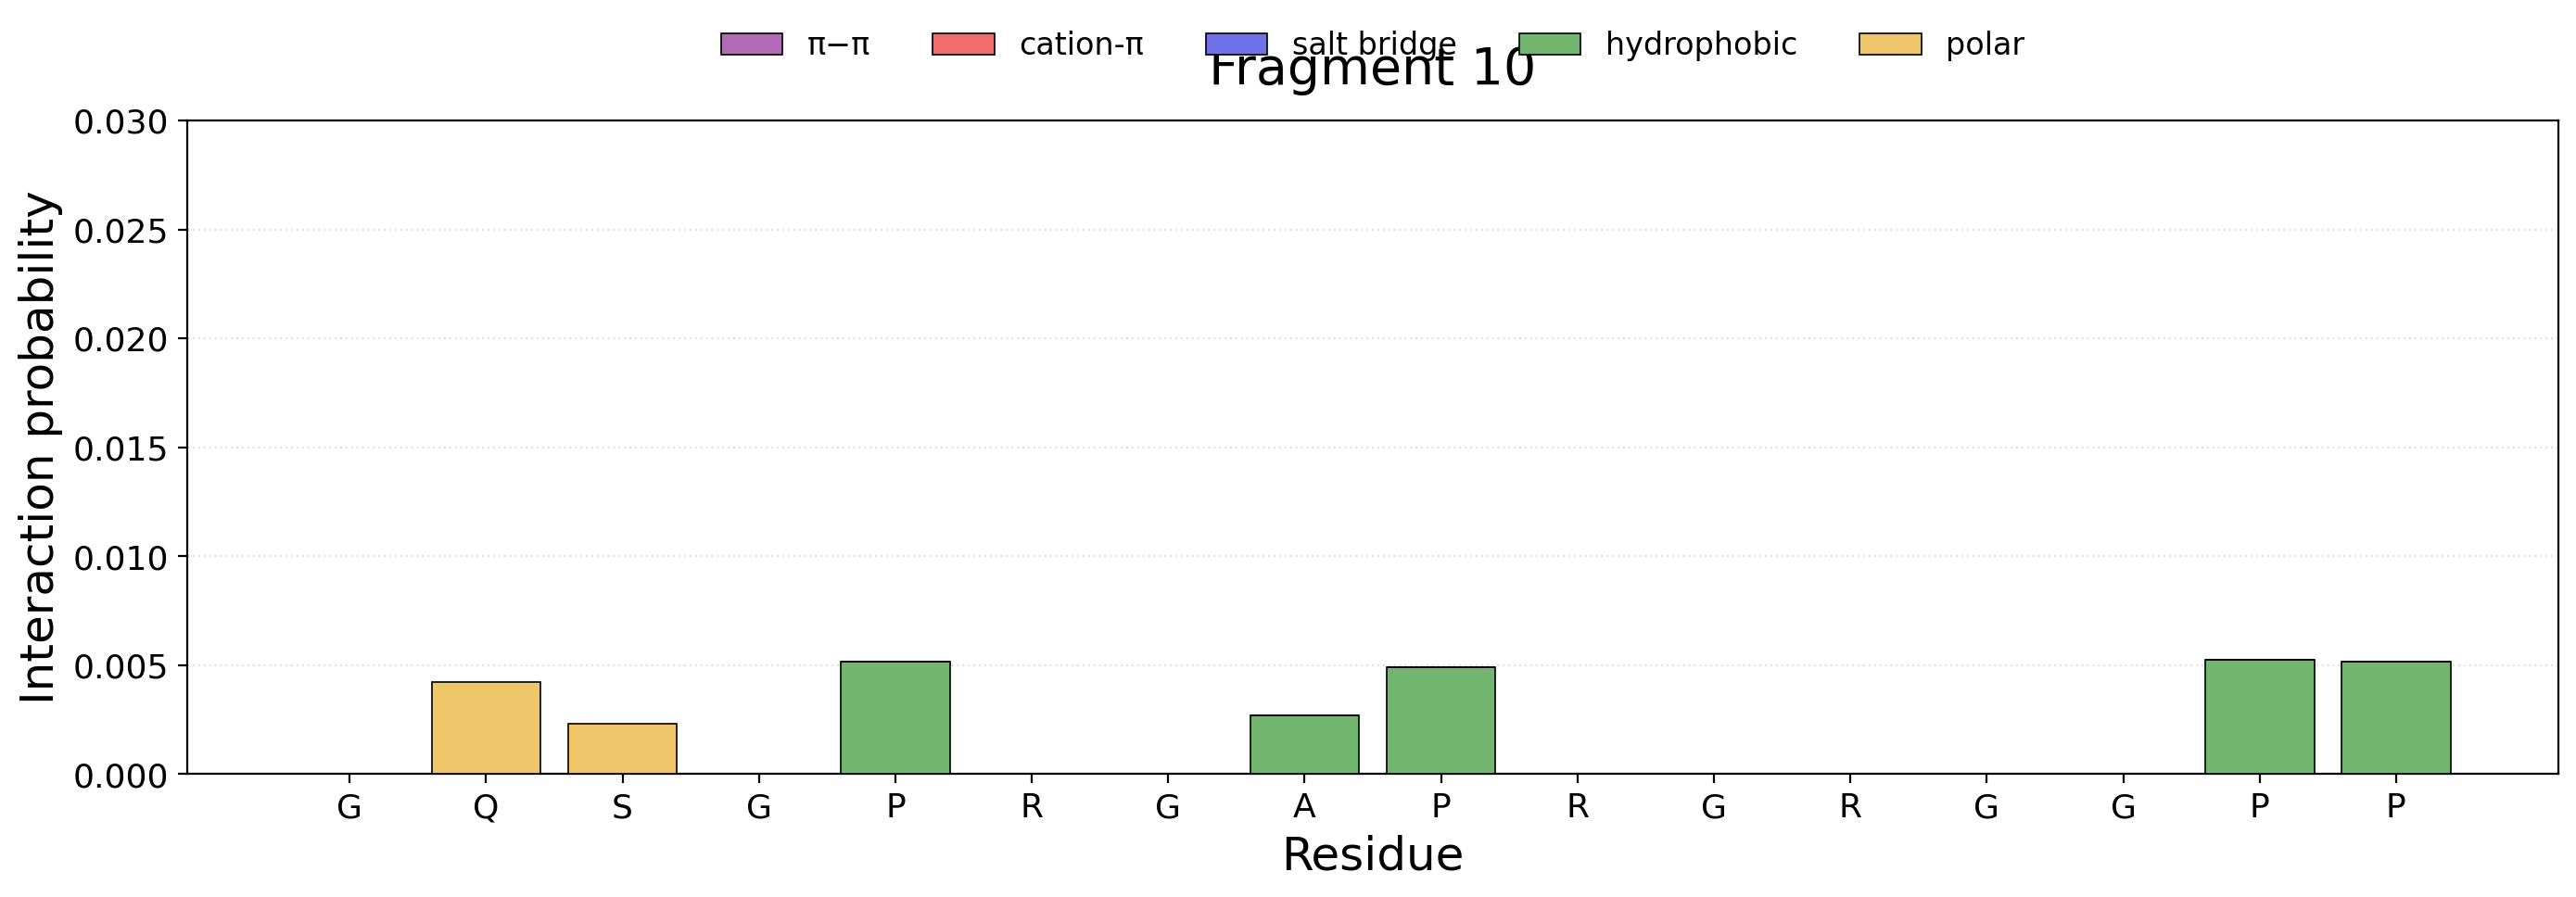

Fragment 11 sequence: PRGRGGPPRPNRGMPQ


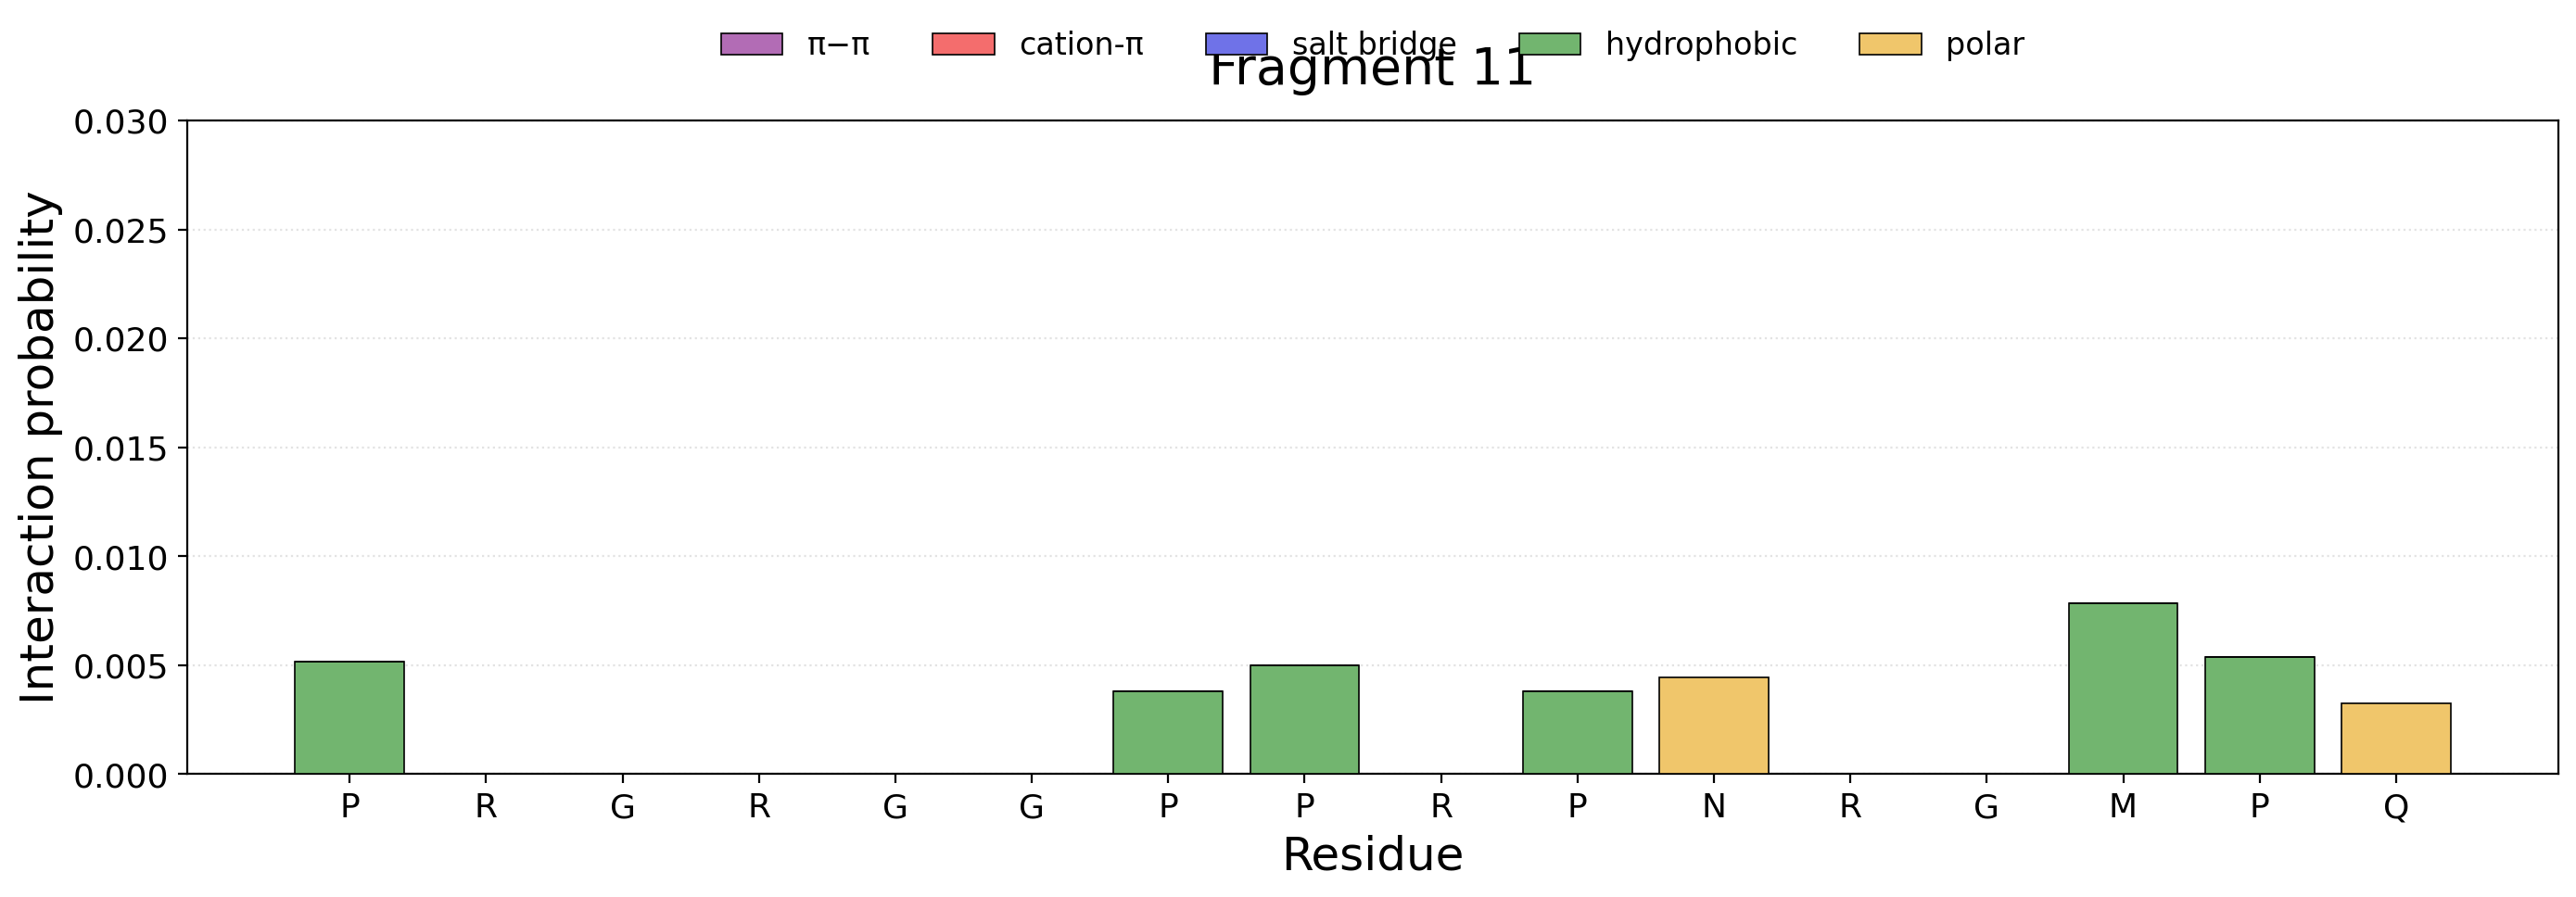

Fragment 12 sequence: RPNRGMPQMNTQQVN


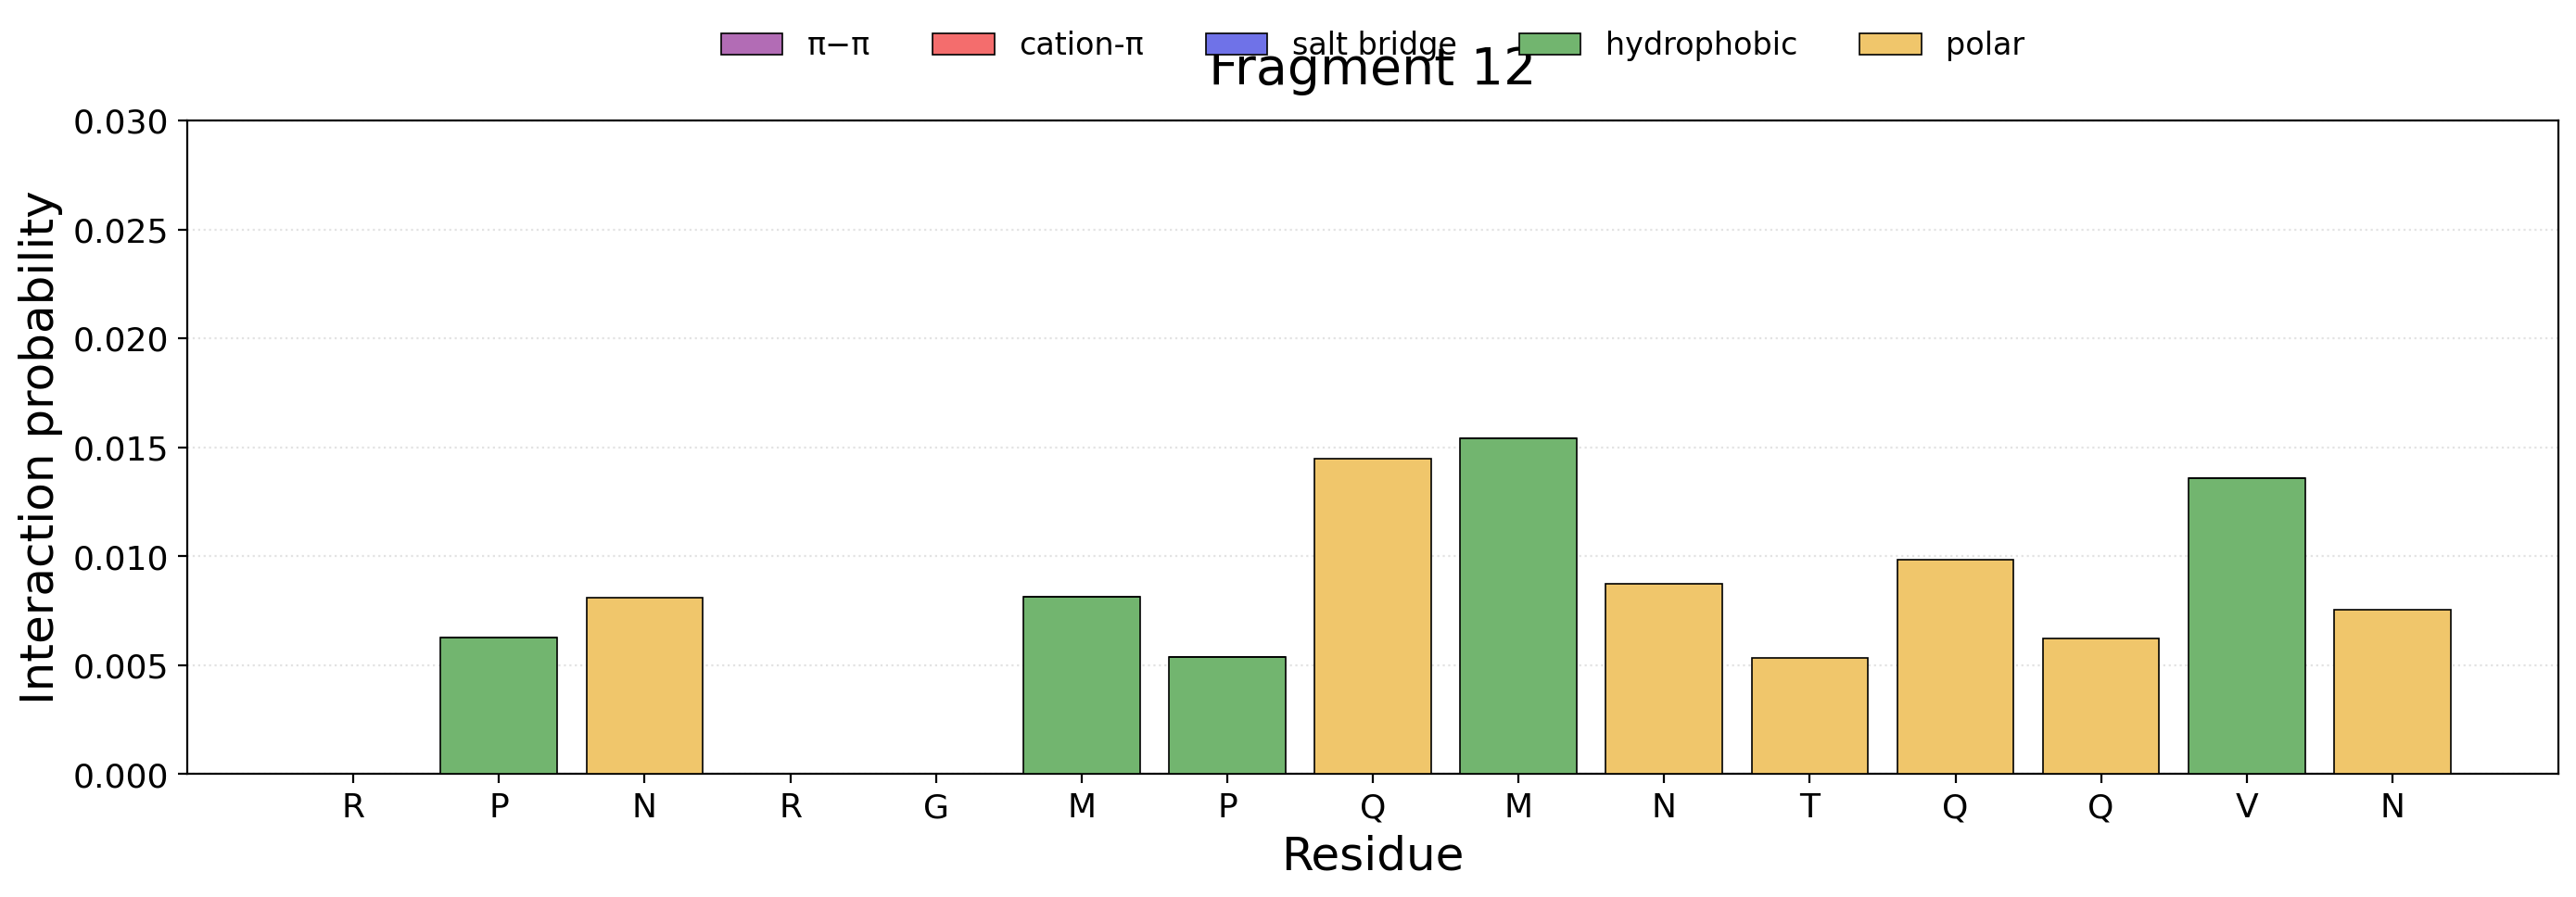

In [15]:
# =========================================================
# Corrected residue-by-residue stacked interaction plots
# Use saved source residue order from fragment_source_residue_order.csv
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Paths
# =========================================================
OUTDIR = Path("interaction_outputs_by_fragment")
CSV_FILE = OUTDIR / "interaction_pair_probabilities_mean_over_trajs.csv"
ORDER_FILE = OUTDIR / "fragment_source_residue_order.csv"

PLOT_DIR = OUTDIR / "residue_stacked_plots_all_residues"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# Read data
# =========================================================
df = pd.read_csv(CSV_FILE)
order_df = pd.read_csv(ORDER_FILE)

df["fragment"] = df["fragment"].astype(int)
df["src_resid"] = df["src_resid"].astype(int)

order_df["fragment"] = order_df["fragment"].astype(int)
order_df["sequence_position"] = order_df["sequence_position"].astype(int)
order_df["src_resid"] = order_df["src_resid"].astype(int)

interaction_order = ["pi_pi", "cation_pi", "salt_bridge", "hydrophobic", "polar"]
df = df[df["interaction"].isin(interaction_order)].copy()

# =========================================================
# 3-letter to 1-letter amino acid mapping
# =========================================================
aa3_to_aa1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "HIP": "H", "HID": "H", "HIE": "H",
    "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M",
    "PHE": "F", "PRO": "P", "SER": "S", "THR": "T",
    "TRP": "W", "TYR": "Y", "VAL": "V"
}

# If the saved order file already has src_rescode, use it
if "src_rescode" not in order_df.columns:
    order_df["src_rescode"] = (
        order_df["src_resname"]
        .astype(str)
        .str.upper()
        .map(aa3_to_aa1)
        .fillna(order_df["src_resname"].astype(str).str.upper())
    )

# =========================================================
# Colors and labels
# =========================================================
colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
    "salt_bridge": "#6f72e8",
    "hydrophobic": "#72b56f",
    "polar": "#f0c66b",
}

labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
    "hydrophobic": "hydrophobic",
    "polar": "polar",
}

# =========================================================
# Sum interaction probabilities per fragment, residue, interaction
# =========================================================
residue_interaction_df = (
    df.groupby(["fragment", "src_resid", "src_resname", "interaction"], as_index=False)
      .agg(residue_interaction_probability=("mean_probability_over_trajs", "sum"))
)

residue_interaction_df.to_csv(
    OUTDIR / "fragment_residue_interaction_type_probabilities.csv",
    index=False
)

# =========================================================
# Make one stacked plot per fragment
# =========================================================
for frag in range(1, 13):
    # Exact residue order for this fragment from saved file
    full_res_df = (
        order_df[order_df["fragment"] == frag]
        .copy()
        .sort_values("sequence_position")
        .reset_index(drop=True)
    )

    if full_res_df.empty:
        print(f"WARNING: no saved residue order found for fragment {frag}")
        continue

    # Subset interaction data for this fragment
    frag_df = residue_interaction_df[residue_interaction_df["fragment"] == frag].copy()

    # Pivot interaction data to wide format
    if not frag_df.empty:
        pivot_df = (
            frag_df.pivot_table(
                index=["src_resid", "src_resname"],
                columns="interaction",
                values="residue_interaction_probability",
                aggfunc="sum",
                fill_value=0.0
            )
            .reset_index()
        )
    else:
        pivot_df = pd.DataFrame(columns=["src_resid", "src_resname"] + interaction_order)

    # Merge with exact residue order so all residues appear
    plot_df = full_res_df.merge(
        pivot_df,
        on=["src_resid", "src_resname"],
        how="left"
    )

    # Make sure all interaction columns exist
    for col in interaction_order:
        if col not in plot_df.columns:
            plot_df[col] = 0.0

    plot_df[interaction_order] = plot_df[interaction_order].fillna(0.0)
    plot_df = plot_df.sort_values("sequence_position").reset_index(drop=True)

    # Use saved one-letter residue code for x-axis labels
    residue_labels = plot_df["src_rescode"].tolist()

    # Optional check
    seq_str = "".join(residue_labels)
    print(f"Fragment {frag} sequence: {seq_str}")

    x = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(14, 5), dpi=200)

    bottom = np.zeros(len(plot_df))

    for interaction in interaction_order:
        values = plot_df[interaction].values
        ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.8,
            color=colors[interaction],
            edgecolor="black",
            linewidth=0.6,
            label=labels_map[interaction],
            zorder=3
        )
        bottom += values

    ax.set_title(f"Fragment {frag}", fontsize=20, pad=14)
    ax.set_xlabel("Residue", fontsize=18)
    ax.set_ylabel("Interaction probability", fontsize=18)

    ax.set_xticks(x)
    ax.set_xticklabels(residue_labels, fontsize=13)
    ax.tick_params(axis="y", labelsize=13)

    ax.grid(True, axis="y", linestyle=":", alpha=0.35, zorder=0)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        ncol=5,
        frameon=False,
        fontsize=12
    )
     
    ax.set_ylim(0, 0.03)

    plt.tight_layout()

    fig.savefig(
        PLOT_DIR / f"fragment_{frag:02d}_stacked_residue_interaction_probability.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    fragment  sequence_position src_resname src_rescode  global_position
0          1                  1         SER           S                1
1          1                  2         ARG           R                2
2          1                  3         GLY           G                3
3          1                  4         VAL           V                4
4          1                  5         SER           S                5
5          1                  6         ARG           R                6
6          1                  7         GLY           G                7
7          1                  8         GLY           G                8
8          1                  9         SER           S                9
9          1                 10         ARG           R               10
10         1                 11         GLY           G               11
11         1                 12         ALA           A               12
12         1                 13         ARG        

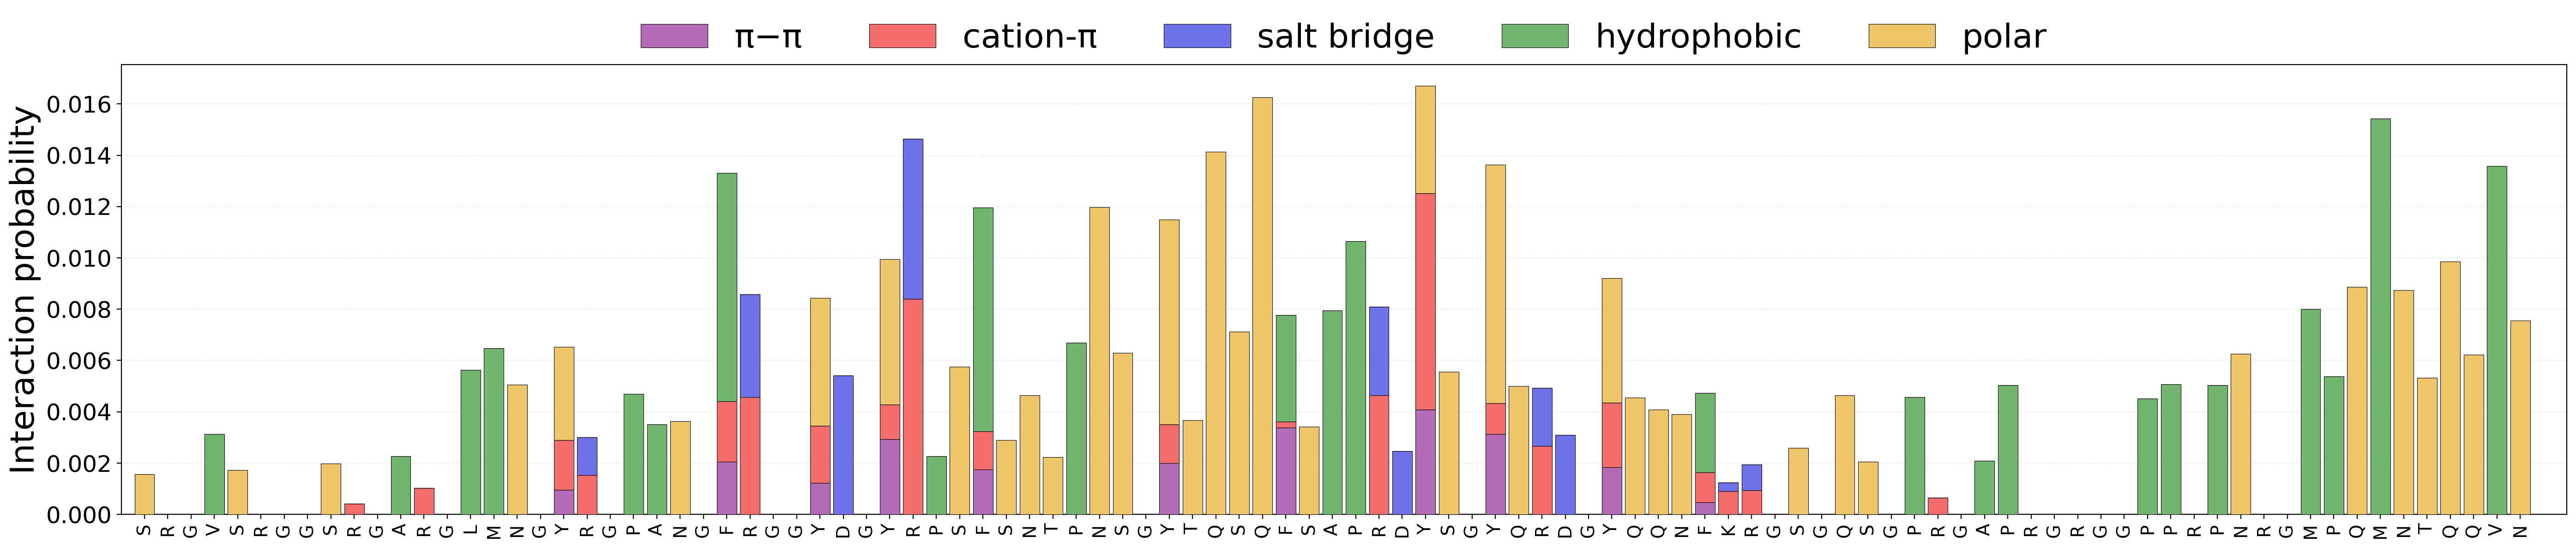

In [16]:
# =========================================================
# Stitch all fragments into one 103-residue stacked plot
# Average overlapping residues between neighboring fragments
# =========================================================

# If running standalone, uncomment these:
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
#
# OUTDIR = Path("interaction_outputs_by_fragment")
# residue_interaction_df = pd.read_csv(OUTDIR / "fragment_residue_interaction_type_probabilities.csv")
# order_df = pd.read_csv(OUTDIR / "fragment_source_residue_order.csv")

# ---------------------------------------------------------
# Make sure required columns are numeric
# ---------------------------------------------------------
residue_interaction_df["fragment"] = residue_interaction_df["fragment"].astype(int)
residue_interaction_df["src_resid"] = residue_interaction_df["src_resid"].astype(int)

order_df["fragment"] = order_df["fragment"].astype(int)
order_df["sequence_position"] = order_df["sequence_position"].astype(int)
order_df["src_resid"] = order_df["src_resid"].astype(int)

interaction_order = ["pi_pi", "cation_pi", "salt_bridge", "hydrophobic", "polar"]

# If src_rescode does not exist, create it
if "src_rescode" not in order_df.columns:
    aa3_to_aa1 = {
        "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
        "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
        "HIS": "H", "HIP": "H", "HID": "H", "HIE": "H",
        "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M",
        "PHE": "F", "PRO": "P", "SER": "S", "THR": "T",
        "TRP": "W", "TYR": "Y", "VAL": "V"
    }
    order_df["src_rescode"] = (
        order_df["src_resname"]
        .astype(str)
        .str.upper()
        .map(aa3_to_aa1)
        .fillna(order_df["src_resname"].astype(str).str.upper())
    )

# ---------------------------------------------------------
# Add global residue position
# global_position = (fragment - 1)*8 + sequence_position
# This gives 1..103 for the stitched full sequence
# ---------------------------------------------------------
order_df["global_position"] = (
    (order_df["fragment"] - 1) * 8 + order_df["sequence_position"]
)

# Optional sanity check
print(order_df[["fragment", "sequence_position", "src_resname", "src_rescode", "global_position"]].head(20))
print("Global position range:", order_df["global_position"].min(), "to", order_df["global_position"].max())

# ---------------------------------------------------------
# Merge residue interaction values onto the fragment residue order
# so every fragment residue has its global position
# ---------------------------------------------------------
merged_df = order_df.merge(
    residue_interaction_df,
    on=["fragment", "src_resid", "src_resname"],
    how="left"
)

merged_df["interaction"] = merged_df["interaction"].fillna("missing")
merged_df["residue_interaction_probability"] = merged_df["residue_interaction_probability"].fillna(0.0)

# Keep only desired interaction rows
merged_df = merged_df[merged_df["interaction"].isin(interaction_order)].copy()

# ---------------------------------------------------------
# Average overlapping residues across fragments
# For each global residue position and interaction type:
# average the contributing fragment values
# ---------------------------------------------------------
global_interaction_df = (
    merged_df.groupby(
        ["global_position", "src_rescode", "interaction"],
        as_index=False
    )
    .agg(global_residue_interaction_probability=("residue_interaction_probability", "mean"))
)

# Save long-format stitched table
global_interaction_df.to_csv(
    OUTDIR / "stitched_global_residue_interaction_probabilities.csv",
    index=False
)

# ---------------------------------------------------------
# Build a complete 103-residue template from the order file
# For overlapping residues, keep one residue code per global position
# ---------------------------------------------------------
global_order_df = (
    order_df.groupby("global_position", as_index=False)
    .agg(src_rescode=("src_rescode", "first"))
    .sort_values("global_position")
    .reset_index(drop=True)
)

# Optional sanity check: should be 103
print("Number of stitched global residues:", len(global_order_df))

# ---------------------------------------------------------
# Pivot to wide format for stacked plotting
# ---------------------------------------------------------
plot_df = (
    global_interaction_df.pivot_table(
        index=["global_position", "src_rescode"],
        columns="interaction",
        values="global_residue_interaction_probability",
        aggfunc="mean",
        fill_value=0.0
    )
    .reset_index()
)

# Merge with full 103-residue order so any missing residues stay present
plot_df = global_order_df.merge(
    plot_df,
    on=["global_position", "src_rescode"],
    how="left"
)

for col in interaction_order:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df[interaction_order] = plot_df[interaction_order].fillna(0.0)
plot_df = plot_df.sort_values("global_position").reset_index(drop=True)

# Save stitched wide-format table
plot_df.to_csv(
    OUTDIR / "stitched_global_residue_interaction_probabilities_wide.csv",
    index=False
)

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------
colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
    "salt_bridge": "#6f72e8",
    "hydrophobic": "#72b56f",
    "polar": "#f0c66b",
}

labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
    "hydrophobic": "hydrophobic",
    "polar": "polar",
}

# Labels:
# Option 1: only one-letter code
# residue_labels = plot_df["src_rescode"].tolist()

# Option 2: one-letter code + global index (recommended for 103 residues)
# residue_labels = [
#     f"{rescode}{gpos}"
#     for rescode, gpos in zip(plot_df["src_rescode"], plot_df["global_position"])
# ]


residue_labels = plot_df["src_rescode"].tolist()

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
x = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(28, 6), dpi=200)

bottom = np.zeros(len(plot_df))

for interaction in interaction_order:
    values = plot_df[interaction].values
    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.85,
        color=colors[interaction],
        edgecolor="black",
        linewidth=0.4,
        label=labels_map[interaction],
        zorder=3
    )
    bottom += values

ax.set_ylabel("Interaction probability", fontsize=26)

ax.set_xticks(x)
ax.set_xticklabels(residue_labels, rotation=90, fontsize=14)
ax.tick_params(axis="y", labelsize=18)





# If you want fixed y-limits, uncomment:
# ax.set_ylim(0, 0.025)
ax.set_xlim(-1, 104)


ax.grid(True, axis="y", linestyle=":", alpha=0.35, zorder=0)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.16),
    ncol=5,
    frameon=False,
    fontsize=26
)

plt.tight_layout()

fig.savefig(
    OUTDIR / "stitched_103_residue_stacked_interaction_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

    fragment  sequence_position src_resname src_rescode  global_position
0          1                  1         SER           S                1
1          1                  2         ARG           R                2
2          1                  3         GLY           G                3
3          1                  4         VAL           V                4
4          1                  5         SER           S                5
5          1                  6         ARG           R                6
6          1                  7         GLY           G                7
7          1                  8         GLY           G                8
8          1                  9         SER           S                9
9          1                 10         ARG           R               10
10         1                 11         GLY           G               11
11         1                 12         ALA           A               12
12         1                 13         ARG        

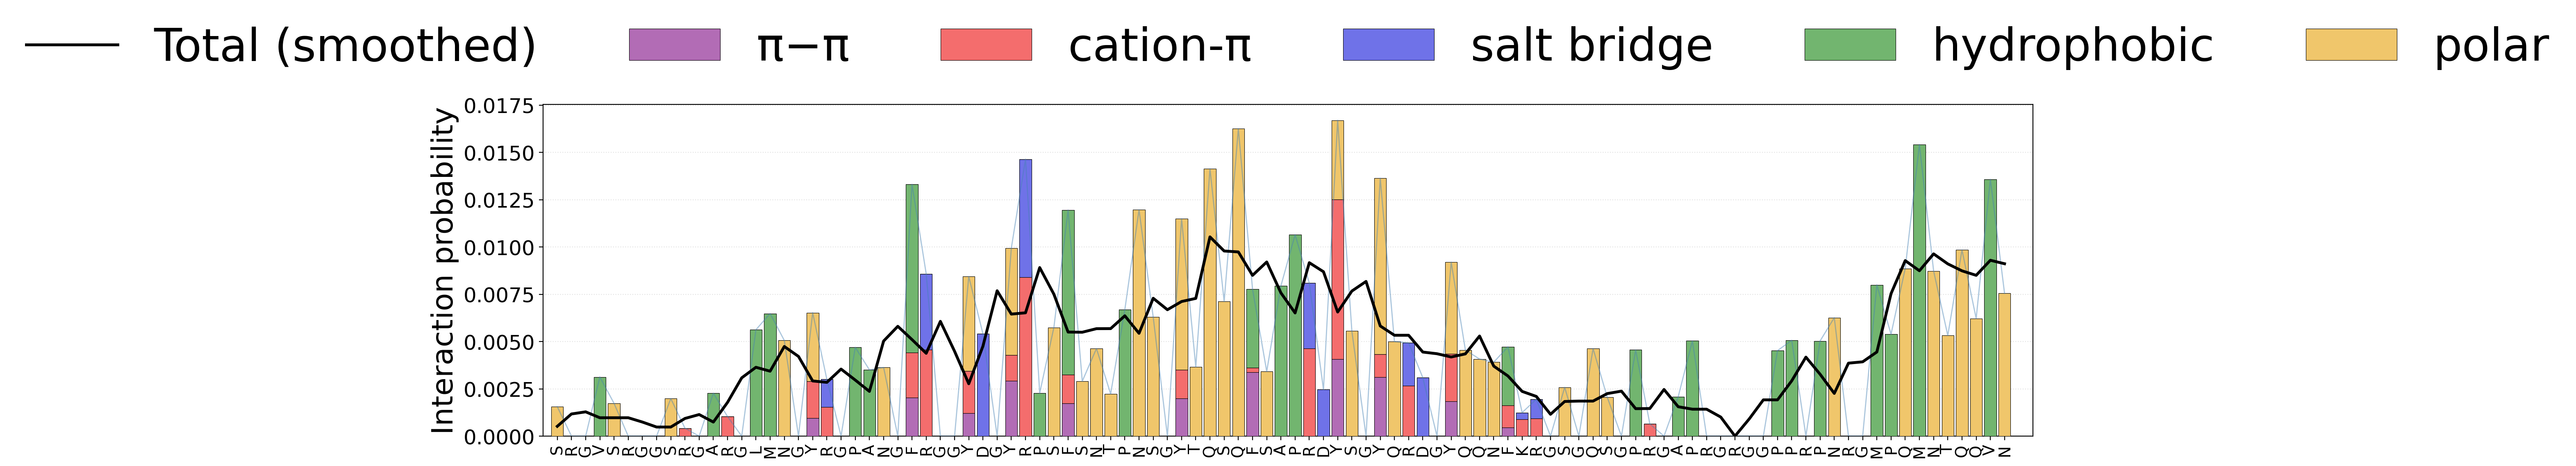

In [34]:
# =========================================================
# Stitch all fragments into one 103-residue stacked plot
# Average overlapping residues between neighboring fragments
# =========================================================

# If running standalone, uncomment these:
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
#
# OUTDIR = Path("interaction_outputs_by_fragment")
# residue_interaction_df = pd.read_csv(OUTDIR / "fragment_residue_interaction_type_probabilities.csv")
# order_df = pd.read_csv(OUTDIR / "fragment_source_residue_order.csv")

# ---------------------------------------------------------
# Make sure required columns are numeric
# ---------------------------------------------------------
residue_interaction_df["fragment"] = residue_interaction_df["fragment"].astype(int)
residue_interaction_df["src_resid"] = residue_interaction_df["src_resid"].astype(int)

order_df["fragment"] = order_df["fragment"].astype(int)
order_df["sequence_position"] = order_df["sequence_position"].astype(int)
order_df["src_resid"] = order_df["src_resid"].astype(int)

interaction_order = ["pi_pi", "cation_pi", "salt_bridge", "hydrophobic", "polar"]

# If src_rescode does not exist, create it
if "src_rescode" not in order_df.columns:
    aa3_to_aa1 = {
        "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
        "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
        "HIS": "H", "HIP": "H", "HID": "H", "HIE": "H",
        "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M",
        "PHE": "F", "PRO": "P", "SER": "S", "THR": "T",
        "TRP": "W", "TYR": "Y", "VAL": "V"
    }
    order_df["src_rescode"] = (
        order_df["src_resname"]
        .astype(str)
        .str.upper()
        .map(aa3_to_aa1)
        .fillna(order_df["src_resname"].astype(str).str.upper())
    )

# ---------------------------------------------------------
# Add global residue position
# global_position = (fragment - 1)*8 + sequence_position
# This gives 1..103 for the stitched full sequence
# ---------------------------------------------------------
order_df["global_position"] = (
    (order_df["fragment"] - 1) * 8 + order_df["sequence_position"]
)

# Optional sanity check
print(order_df[["fragment", "sequence_position", "src_resname", "src_rescode", "global_position"]].head(20))
print("Global position range:", order_df["global_position"].min(), "to", order_df["global_position"].max())

# ---------------------------------------------------------
# Merge residue interaction values onto the fragment residue order
# so every fragment residue has its global position
# ---------------------------------------------------------
merged_df = order_df.merge(
    residue_interaction_df,
    on=["fragment", "src_resid", "src_resname"],
    how="left"
)

merged_df["interaction"] = merged_df["interaction"].fillna("missing")
merged_df["residue_interaction_probability"] = merged_df["residue_interaction_probability"].fillna(0.0)

# Keep only desired interaction rows
merged_df = merged_df[merged_df["interaction"].isin(interaction_order)].copy()

# ---------------------------------------------------------
# Average overlapping residues across fragments
# For each global residue position and interaction type:
# average the contributing fragment values
# ---------------------------------------------------------
global_interaction_df = (
    merged_df.groupby(
        ["global_position", "src_rescode", "interaction"],
        as_index=False
    )
    .agg(global_residue_interaction_probability=("residue_interaction_probability", "mean"))
)

# Save long-format stitched table
global_interaction_df.to_csv(
    OUTDIR / "stitched_global_residue_interaction_probabilities.csv",
    index=False
)

# ---------------------------------------------------------
# Build a complete 103-residue template from the order file
# For overlapping residues, keep one residue code per global position
# ---------------------------------------------------------
global_order_df = (
    order_df.groupby("global_position", as_index=False)
    .agg(src_rescode=("src_rescode", "first"))
    .sort_values("global_position")
    .reset_index(drop=True)
)

# Optional sanity check: should be 103
print("Number of stitched global residues:", len(global_order_df))

# ---------------------------------------------------------
# Pivot to wide format for stacked plotting
# ---------------------------------------------------------
plot_df = (
    global_interaction_df.pivot_table(
        index=["global_position", "src_rescode"],
        columns="interaction",
        values="global_residue_interaction_probability",
        aggfunc="mean",
        fill_value=0.0
    )
    .reset_index()
)

# Merge with full 103-residue order so any missing residues stay present
plot_df = global_order_df.merge(
    plot_df,
    on=["global_position", "src_rescode"],
    how="left"
)

for col in interaction_order:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df[interaction_order] = plot_df[interaction_order].fillna(0.0)
plot_df = plot_df.sort_values("global_position").reset_index(drop=True)

# Save stitched wide-format table
plot_df.to_csv(
    OUTDIR / "stitched_global_residue_interaction_probabilities_wide.csv",
    index=False
)

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------
colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
    "salt_bridge": "#6f72e8",
    "hydrophobic": "#72b56f",
    "polar": "#f0c66b",
}

labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
    "hydrophobic": "hydrophobic",
    "polar": "polar",
}

residue_labels = plot_df["src_rescode"].tolist()

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
x = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(28, 6), dpi=200)

bottom = np.zeros(len(plot_df))

for interaction in interaction_order:
    values = plot_df[interaction].values
    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.85,
        color=colors[interaction],
        edgecolor="black",
        linewidth=0.4,
        label=labels_map[interaction],
        zorder=3
    )
    bottom += values

# ---------------------------------------------------------
# Overlay: total interaction probability line per residue
# ---------------------------------------------------------
total_interaction = plot_df[interaction_order].sum(axis=1).values

# Raw line (light blue, faint — mirrors the noisy trace in your reference)
ax.plot(
    x,
    total_interaction,
    color="steelblue",
    linewidth=1.0,
    alpha=0.45,
    zorder=5,
    label="_nolegend_"   # hide from legend
)

# Smoothed bold black line (rolling average)
window = 5  # increase for smoother curve, decrease for more detail
smoothed = (
    pd.Series(total_interaction)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .values
)
ax.plot(
    x,
    smoothed,
    color="black",
    linewidth=2.5,
    zorder=6,
    label="Total (smoothed)"
)

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------
ax.set_ylabel("Interaction probability", fontsize=26)

ax.set_xticks(x)
ax.set_xticklabels(residue_labels, rotation=90, fontsize=14)
ax.tick_params(axis="y", labelsize=18)

# If you want fixed y-limits, uncomment:
# ax.set_ylim(0, 0.025)
ax.set_xlim(-1, 104)

ax.grid(True, axis="y", linestyle=":", alpha=0.35, zorder=0)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.36),
    ncol=6,          # bumped from 5 to 6 to fit the new "Total (smoothed)" entry
    frameon=False,
    fontsize=40
)

plt.tight_layout()

fig.savefig(
    OUTDIR / "stitched_103_residue_stacked_interaction_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

    fragment  sequence_position src_resname src_rescode  global_position
0          1                  1         SER           S                1
1          1                  2         ARG           R                2
2          1                  3         GLY           G                3
3          1                  4         VAL           V                4
4          1                  5         SER           S                5
5          1                  6         ARG           R                6
6          1                  7         GLY           G                7
7          1                  8         GLY           G                8
8          1                  9         SER           S                9
9          1                 10         ARG           R               10
10         1                 11         GLY           G               11
11         1                 12         ALA           A               12
12         1                 13         ARG        

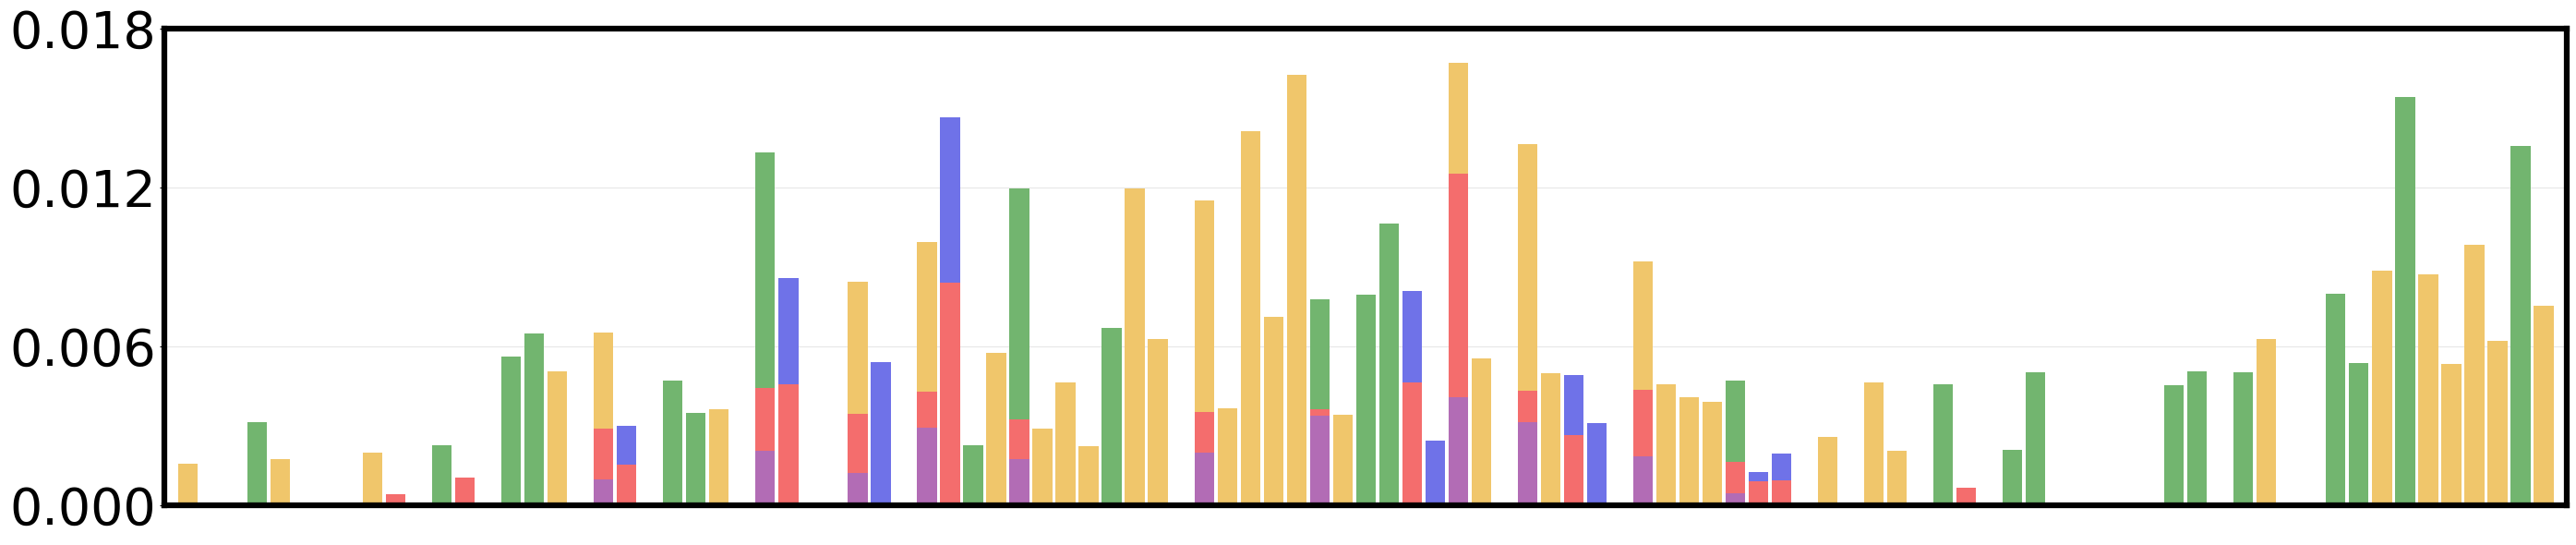

In [25]:
# =========================================================
# Stitch all fragments into one 103-residue stacked plot
# Average overlapping residues between neighboring fragments
# =========================================================

# If running standalone, uncomment these:
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
#
# OUTDIR = Path("interaction_outputs_by_fragment")
# residue_interaction_df = pd.read_csv(OUTDIR / "fragment_residue_interaction_type_probabilities.csv")
# order_df = pd.read_csv(OUTDIR / "fragment_source_residue_order.csv")

# ---------------------------------------------------------
# Make sure required columns are numeric
# ---------------------------------------------------------
residue_interaction_df["fragment"] = residue_interaction_df["fragment"].astype(int)
residue_interaction_df["src_resid"] = residue_interaction_df["src_resid"].astype(int)

order_df["fragment"] = order_df["fragment"].astype(int)
order_df["sequence_position"] = order_df["sequence_position"].astype(int)
order_df["src_resid"] = order_df["src_resid"].astype(int)

interaction_order = ["pi_pi", "cation_pi", "salt_bridge", "hydrophobic", "polar"]

# If src_rescode does not exist, create it
if "src_rescode" not in order_df.columns:
    aa3_to_aa1 = {
        "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
        "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
        "HIS": "H", "HIP": "H", "HID": "H", "HIE": "H",
        "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M",
        "PHE": "F", "PRO": "P", "SER": "S", "THR": "T",
        "TRP": "W", "TYR": "Y", "VAL": "V"
    }
    order_df["src_rescode"] = (
        order_df["src_resname"]
        .astype(str)
        .str.upper()
        .map(aa3_to_aa1)
        .fillna(order_df["src_resname"].astype(str).str.upper())
    )

# ---------------------------------------------------------
# Add global residue position
# global_position = (fragment - 1)*8 + sequence_position
# This gives 1..103 for the stitched full sequence
# ---------------------------------------------------------
order_df["global_position"] = (
    (order_df["fragment"] - 1) * 8 + order_df["sequence_position"]
)

# Optional sanity check
print(order_df[["fragment", "sequence_position", "src_resname", "src_rescode", "global_position"]].head(20))
print("Global position range:", order_df["global_position"].min(), "to", order_df["global_position"].max())

# ---------------------------------------------------------
# Merge residue interaction values onto the fragment residue order
# so every fragment residue has its global position
# ---------------------------------------------------------
merged_df = order_df.merge(
    residue_interaction_df,
    on=["fragment", "src_resid", "src_resname"],
    how="left"
)

merged_df["interaction"] = merged_df["interaction"].fillna("missing")
merged_df["residue_interaction_probability"] = merged_df["residue_interaction_probability"].fillna(0.0)

# Keep only desired interaction rows
merged_df = merged_df[merged_df["interaction"].isin(interaction_order)].copy()

# ---------------------------------------------------------
# Average overlapping residues across fragments
# For each global residue position and interaction type:
# average the contributing fragment values
# ---------------------------------------------------------
global_interaction_df = (
    merged_df.groupby(
        ["global_position", "src_rescode", "interaction"],
        as_index=False
    )
    .agg(global_residue_interaction_probability=("residue_interaction_probability", "mean"))
)

# Save long-format stitched table
global_interaction_df.to_csv(
    OUTDIR / "stitched_global_residue_interaction_probabilities.csv",
    index=False
)

# ---------------------------------------------------------
# Build a complete 103-residue template from the order file
# For overlapping residues, keep one residue code per global position
# ---------------------------------------------------------
global_order_df = (
    order_df.groupby("global_position", as_index=False)
    .agg(src_rescode=("src_rescode", "first"))
    .sort_values("global_position")
    .reset_index(drop=True)
)

# Optional sanity check: should be 103
print("Number of stitched global residues:", len(global_order_df))

# ---------------------------------------------------------
# Pivot to wide format for stacked plotting
# ---------------------------------------------------------
plot_df = (
    global_interaction_df.pivot_table(
        index=["global_position", "src_rescode"],
        columns="interaction",
        values="global_residue_interaction_probability",
        aggfunc="mean",
        fill_value=0.0
    )
    .reset_index()
)

# Merge with full 103-residue order so any missing residues stay present
plot_df = global_order_df.merge(
    plot_df,
    on=["global_position", "src_rescode"],
    how="left"
)

for col in interaction_order:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df[interaction_order] = plot_df[interaction_order].fillna(0.0)
plot_df = plot_df.sort_values("global_position").reset_index(drop=True)

# Save stitched wide-format table
plot_df.to_csv(
    OUTDIR / "stitched_global_residue_interaction_probabilities_wide.csv",
    index=False
)

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------
colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
    "salt_bridge": "#6f72e8",
    "hydrophobic": "#72b56f",
    "polar": "#f0c66b",
}

labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
    "hydrophobic": "hydrophobic",
    "polar": "polar",
}

residue_labels = plot_df["src_rescode"].tolist()

# ---------------------------------------------------------
from matplotlib.ticker import LinearLocator

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
x = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(28, 6))

bottom = np.zeros(len(plot_df))

for interaction in interaction_order:
    values = plot_df[interaction].to_numpy()

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.85,
        color=colors[interaction],
        alpha=1.00,                 # Lightly transparent bars
        edgecolor="none",
        linewidth=0,
        label=labels_map[interaction],
        zorder=2
    )

    bottom += values

# ---------------------------------------------------------
# Total interaction probability
# ---------------------------------------------------------
total_interaction = (
    plot_df[interaction_order]
    .sum(axis=1)
    .to_numpy()
)

# Light-blue raw total line


# Rolling-average smoothing
window = 5

smoothed = (
    pd.Series(total_interaction)
    .rolling(
        window=window,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# # Bold orange smoothed line
# ax.plot(
#     x,
#     smoothed,
#     color="black",
#     linewidth=3.5,
#     alpha=1.0,
#     zorder=6,
#     label="Total (smoothed)"
# )

# ---------------------------------------------------------
# Axis formatting — same setup as previous plot
# ---------------------------------------------------------
# ax.set_ylabel("Interaction probability", fontsize=25)

# Hide the x-axis residue labels
ax.set_xticks([])

ax.set_xlim(-1, 103)
ax.set_ylim(0, 0.018)

# Exactly four y-axis values
ax.yaxis.set_major_locator(LinearLocator(4))
ax.tick_params(axis="y", labelsize=40)

ax.grid(
    axis="y",
    alpha=0.3,
    zorder=0
)


# Thick black border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(4.5)



plt.tight_layout()

fig.savefig(
    OUTDIR / "stitched111_103_residue_stacked_interaction_probability.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [26]:
# =========================================================
# Plot only pi-pi + cation-pi + salt-bridge interactions
# using the stitched 103-residue table already created above
# =========================================================
from matplotlib.ticker import LinearLocator

selected_interactions = ["pi_pi", "cation_pi", "salt_bridge"]

selected_colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
    "salt_bridge": "#6f72e8",
}

selected_labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
}

# Make sure selected columns exist
for col in selected_interactions:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df[selected_interactions] = plot_df[selected_interactions].fillna(0.0)

# Sum only the selected interaction types
plot_df["pi_cation_salt_total"] = plot_df[selected_interactions].sum(axis=1)

# Save table
plot_df[
    ["global_position", "src_rescode"] 
    + selected_interactions 
    + ["pi_cation_salt_total"]
].to_csv(
    OUTDIR / "stitched_global_pi_cation_salt_interaction_probabilities.csv",
    index=False
)

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
residue_labels = plot_df["src_rescode"].tolist()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(28, 8), dpi=600)

bottom = np.zeros(len(plot_df))

for interaction in selected_interactions:
    values = plot_df[interaction].values

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.85,
        color=selected_colors[interaction],
        edgecolor="black",
        linewidth=0.4,
        label=selected_labels_map[interaction],
        zorder=3
    )

    bottom += values

# ---------------------------------------------------------
# Overlay total line for only selected interaction types
# ---------------------------------------------------------
selected_total = plot_df["pi_cation_salt_total"].values

ax.plot(
    x,
    selected_total,
    color="steelblue",
    linewidth=1.0,
    alpha=0.45,
    zorder=5,
    label="_nolegend_"
)

window = 5
selected_smoothed = (
    pd.Series(selected_total)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .values
)

ax.plot(
    x,
    selected_smoothed,
    color="black",
    linewidth=2.5,
    zorder=6,
    label="Selected total (smoothed)"
)

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------
ax.set_ylabel("Interaction probability", fontsize=36)

ax.set_xticks(x)
ax.set_xticklabels(residue_labels, rotation=90, fontsize=24)
ax.tick_params(axis="y", labelsize=24)

ax.set_xlim(-1, 104)

ax.grid(True, axis="y", linestyle=":", alpha=0.35, zorder=0)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    ncol=4,
    frameon=False,
    fontsize=36
)

plt.tight_layout()

fig.savefig(
    OUTDIR / "stitched_103_residue_pi_cation_salt_interaction_probability.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

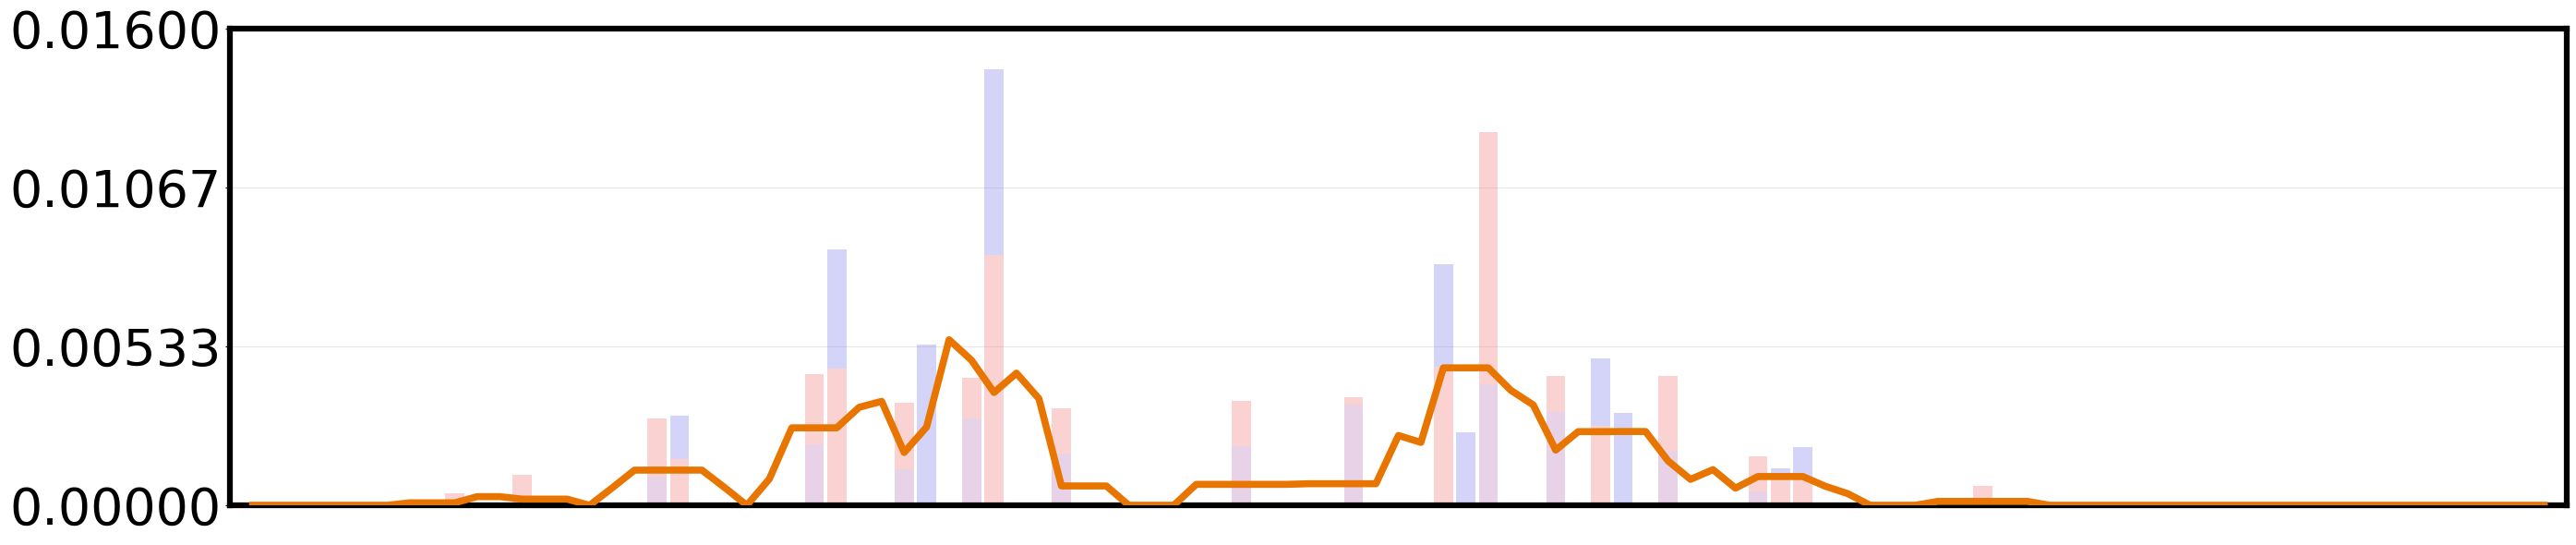

In [37]:
# =========================================================
# Plot only pi-pi + cation-pi + salt-bridge interactions
# using the stitched 103-residue table already created above
# =========================================================
from matplotlib.ticker import LinearLocator

selected_interactions = ["pi_pi", "cation_pi", "salt_bridge"]

selected_colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
    "salt_bridge": "#6f72e8",
}

selected_labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
    "salt_bridge": "salt bridge",
}

# Make sure selected columns exist
for col in selected_interactions:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df[selected_interactions] = plot_df[selected_interactions].fillna(0.0)

# Sum only the selected interaction types
plot_df["pi_cation_salt_total"] = plot_df[selected_interactions].sum(axis=1)

# Save table
plot_df[
    ["global_position", "src_rescode"] 
    + selected_interactions 
    + ["pi_cation_salt_total"]
].to_csv(
    OUTDIR / "stitched_global_pi_cation_salt_interaction_probabilities.csv",
    index=False
)

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
residue_labels = plot_df["src_rescode"].tolist()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(28, 6))

bottom = np.zeros(len(plot_df))

for interaction in selected_interactions:
    values = plot_df[interaction].to_numpy()

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.85,
        color=selected_colors[interaction],
        alpha=0.30,                 # Transparent bars
        edgecolor="none",
        linewidth=0,
        label=selected_labels_map[interaction],
        zorder=2
    )

    bottom += values

# ---------------------------------------------------------
# Selected total and smoothed line
# ---------------------------------------------------------
selected_total = plot_df["pi_cation_salt_total"].to_numpy()

# Faint light-blue raw line
# ax.plot(
#     x,
#     selected_total,
#     color="#79AEE3",
#     linewidth=1.8,
#     alpha=1.00,
#     zorder=4,
#     label="_nolegend_"
# )

window = 5

selected_smoothed = (
    pd.Series(selected_total)
    .rolling(
        window=window,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# Bold orange smoothed line
ax.plot(
    x,
    selected_smoothed,
    color="#E87500",
    linewidth=5.5,
    alpha=1.0,
    zorder=6,
    label="Selected total (smoothed)"
)

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------
# ax.set_ylabel("Interaction probability", fontsize=25)

# Hide x-axis labels to match the previous plot
ax.set_xticks([])

ax.set_xlim(-1, 103)
ax.set_ylim(0, 0.016)

# Show exactly four values on the y-axis
ax.yaxis.set_major_locator(LinearLocator(4))
ax.tick_params(axis="y", labelsize=40)

ax.grid(
    axis="y",
    alpha=0.3,
    zorder=0
)

# Thick black border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(4.5)

# ax.legend(
#     loc="upper center",
#     ncol=4,
#     frameon=False,
#     fontsize=16
# )

plt.tight_layout()

fig.savefig(
    OUTDIR / "stitched11771_103_residue_pi_cation_salt_interaction_probability.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

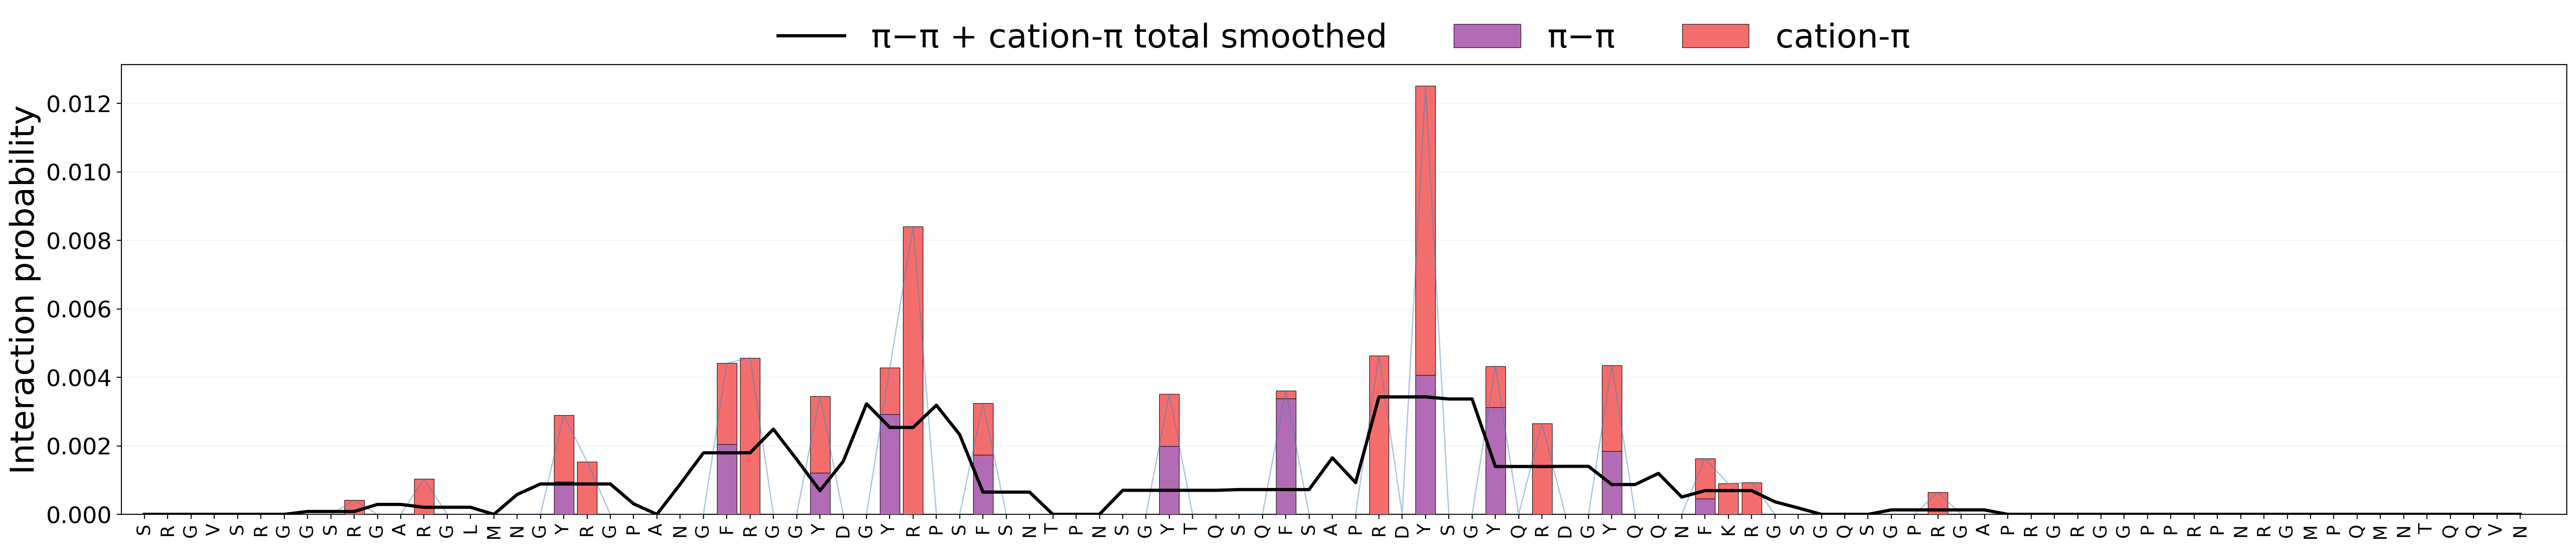

In [30]:
# =========================================================
# Plot only pi-pi + cation-pi stitched interaction probability
# Continue after the stitched 103-residue plot code above
# =========================================================

selected_interactions = ["pi_pi", "cation_pi"]

selected_colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
}

selected_labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
}

# Make sure selected columns exist
for col in selected_interactions:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df[selected_interactions] = plot_df[selected_interactions].fillna(0.0)

# Sum only pi-pi + cation-pi
plot_df["pi_pi_cation_pi_total"] = plot_df[selected_interactions].sum(axis=1)

# Save table
plot_df[
    ["global_position", "src_rescode"]
    + selected_interactions
    + ["pi_pi_cation_pi_total"]
].to_csv(
    OUTDIR / "stitched_global_pi_pi_cation_pi_interaction_probabilities.csv",
    index=False
)

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
residue_labels = plot_df["src_rescode"].tolist()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(28, 6), dpi=200)

bottom = np.zeros(len(plot_df))

for interaction in selected_interactions:
    values = plot_df[interaction].values

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.85,
        color=selected_colors[interaction],
        edgecolor="black",
        linewidth=0.4,
        label=selected_labels_map[interaction],
        zorder=3
    )

    bottom += values

# ---------------------------------------------------------
# Overlay total line for pi-pi + cation-pi
# ---------------------------------------------------------
selected_total = plot_df["pi_pi_cation_pi_total"].values

ax.plot(
    x,
    selected_total,
    color="steelblue",
    linewidth=1.0,
    alpha=0.45,
    zorder=5,
    label="_nolegend_"
)

window = 5

selected_smoothed = (
    pd.Series(selected_total)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .values
)

ax.plot(
    x,
    selected_smoothed,
    color="black",
    linewidth=2.5,
    zorder=6,
    label="π−π + cation-π total smoothed"
)

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------
ax.set_ylabel("Interaction probability", fontsize=26)

ax.set_xticks(x)
ax.set_xticklabels(residue_labels, rotation=90, fontsize=14)
ax.tick_params(axis="y", labelsize=18)

ax.set_xlim(-1, 104)

ax.grid(True, axis="y", linestyle=":", alpha=0.35, zorder=0)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.16),
    ncol=3,
    frameon=False,
    fontsize=26
)

plt.tight_layout()

fig.savefig(
    OUTDIR / "stitched_103_residue_pi_pi_cation_pi_interaction_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

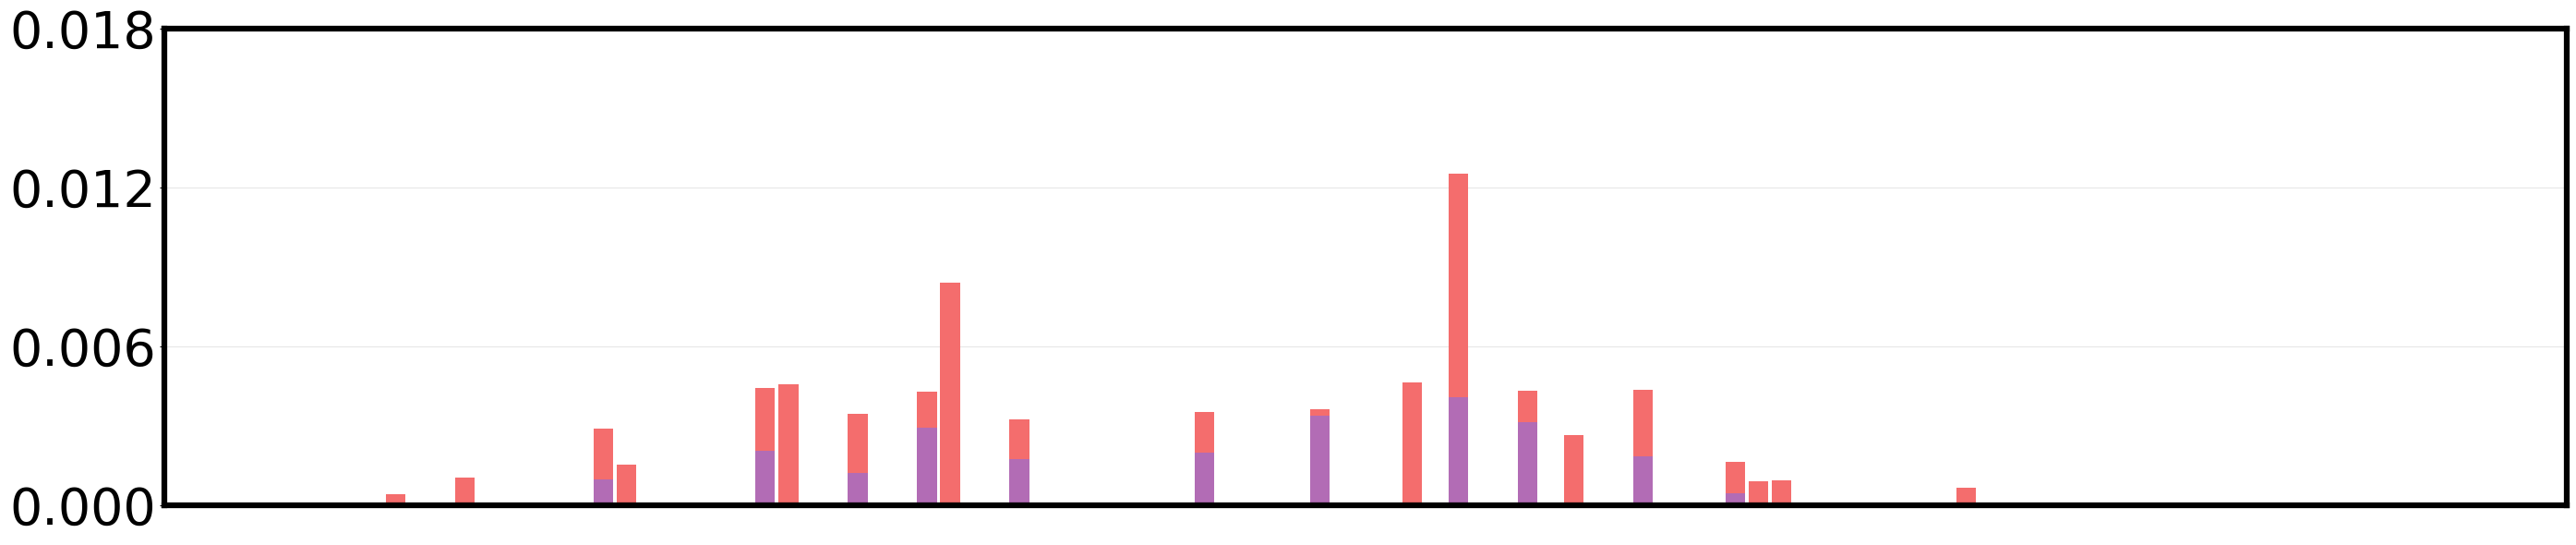

In [32]:
# =========================================================
# Plot only pi-pi + cation-pi stitched interaction probability
# Continue after the stitched 103-residue plot code above
# =========================================================

selected_interactions = ["pi_pi", "cation_pi"]

selected_colors = {
    "pi_pi": "#b26cb5",
    "cation_pi": "#f46d6d",
}

selected_labels_map = {
    "pi_pi": "π−π",
    "cation_pi": "cation-π",
}

# Make sure selected columns exist
for col in selected_interactions:
    if col not in plot_df.columns:
        plot_df[col] = 0.0

plot_df[selected_interactions] = plot_df[selected_interactions].fillna(0.0)

# Sum only pi-pi + cation-pi
plot_df["pi_pi_cation_pi_total"] = plot_df[selected_interactions].sum(axis=1)

# Save table
plot_df[
    ["global_position", "src_rescode"]
    + selected_interactions
    + ["pi_pi_cation_pi_total"]
].to_csv(
    OUTDIR / "stitched_global_pi_pi_cation_pi_interaction_probabilities.csv",
    index=False
)

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------



from matplotlib.ticker import LinearLocator

# ---------------------------------------------------------
# Make stitched stacked bar plot
# ---------------------------------------------------------
residue_labels = plot_df["src_rescode"].tolist()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(28, 6))

bottom = np.zeros(len(plot_df))

for interaction in selected_interactions:
    values = plot_df[interaction].to_numpy()

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.85,
        color=selected_colors[interaction],
        alpha=1.00,                 # Transparent bars
        edgecolor="none",
        linewidth=0,
        label=selected_labels_map[interaction],
        zorder=2
    )

    bottom += values

# ---------------------------------------------------------
# Raw and smoothed total lines
# ---------------------------------------------------------
selected_total = plot_df["pi_pi_cation_pi_total"].to_numpy()

# Faint light-blue raw line
# ax.plot(
#     x,
#     selected_total,
#     color="#79AEE3",
#     linewidth=1.8,
#     alpha=0.55,
#     zorder=4,
#     label="_nolegend_"
# )

# window = 5

# selected_smoothed = (
#     pd.Series(selected_total)
#     .rolling(
#         window=window,
#         center=True,
#         min_periods=1
#     )
#     .mean()
#     .to_numpy()
# )

# # Bold orange smoothed line
# ax.plot(
#     x,
#     selected_smoothed,
#     color="#E87500",
#     linewidth=5.5,
#     alpha=1.0,
#     zorder=6,
#     label="π−π + cation-π total smoothed"
# )

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------
# ax.set_ylabel("Interaction probability", fontsize=25)

# Hide residue labels to match the previous plots
ax.set_xticks([])

ax.set_xlim(-1, 103)
ax.set_ylim(0, 0.018)

# Exactly four y-axis values
ax.yaxis.set_major_locator(LinearLocator(4))
ax.tick_params(axis="y", labelsize=40)

ax.grid(
    axis="y",
    alpha=0.3,
    zorder=0
)

# Thick black frame
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(4.5)

# ax.legend(
#     loc="upper center",
#     ncol=3,
#     frameon=False,
#     fontsize=16
# )

plt.tight_layout()

fig.savefig(
    OUTDIR / "stitched_103_residue_pi_pi_cation_pi_interaction_probability.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)